In [361]:
##################################### Cell 0: Libraries #############################################################
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F_func
import torch.optim as optim
import pandas as pd
import random
import time
import os
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
import itertools
import pickle
import re
import glob
import shutil
from pathlib import Path
import optuna
from tqdm import tqdm
import torch._dynamo
import math

torch._dynamo.config.recompile_limit = 100
torch._dynamo.config.cache_size_limit = 200

#"C:\Program Files\Microsoft Visual Studio\18\Community\VC\Auxiliary\Build\vcvars64.bat"

#ROOT = Path.home() / "OneDrive" / "Ambiente de Trabalho" / "Internship_RO"
ROOT = Path.home() / "OneDrive" / "Ambiente de Trabalho" / "LGundersen" / "Internship_RO"

In [362]:
################################# Cell 1: Variables and Parameters ################################################
#CHANGE HERE TO SKIP TRAINING
run_training = False 

#SELECT REGULARIZATION METHOD
LOOCV = False                  #M1 if LOOCV, M2 if SR

#SELECT NN HIDDEN STRUCTURE 
nh = [3]

N_TRIALS = 65

AICc = True

RA = True 

debug = False

n_pc = 25

#SELECT TARGET MABs (manually)
mABs_to_train = ['Adalimumab']

#SELECT NUMBER OF TARGET MABs (randomly)
num_mabs_to_select = 0

#set parameters for LOOCV vs SR methodology
if LOOCV == True:
    k_folds = 1                      #number of different partitions
    weight_dropout_rate = 0.0        #prob of inactive neuron (stochastic regularization)
    train_minibatch_rate = 1.0       #rate of batches randomly selected for training on each epoch from overall training set
    num_val = 1
else:
    k_folds = 5 if not AICc else 1   #number of different partitions (k fold)
    weight_dropout_rate = 0.2        #prob of inactive neuron (stochastic regularization)
    train_minibatch_rate = 0.8       #rate of batches randomly selected for training on each epoch from overall training set
    num_val = 4 if not AICc else 0   #number of validation batches 

h = 3                           #h  = integration step size

 #             X, mAb, ALA,  ARG,   ASN, ASP, CYS,  AGLC,   EGLN,  EGLU, EPYR,  GLY,  HIS,   ILE,   LAC, LEU,   LYS,  MET, NH4,  PHE,   PRO,   SER,   THR,   TYR, VAL, 
Feed_Conc = torch.Tensor([0, 0, 00.0, 29.71, 0.0, 0.0, 3.32, 1892.8, 23.53, 0.0, 39.67, 0.0, 11.73, 46.96,  \
                          0.0, 27.71, 1.02, 3.57, 0.0, 23.89, 41.31, 72.97, 32.12, 0.0, 56.21])

DoE_framework = [
    "_96_0.0_15.0_20260901_12",    #0  #Estrela
    "_96_4.0_15.0_20260901_12",    #1  #Estrela
    "_96_2.0_0.0_20260901_12",     #2  #Estrela
    "_96_2.0_30.0_20260901_12",    #3  #Estrela

    "_96_2.0_15.0_20260901_12",    #4  #CENTRO

    "_84_0.81_6.08_20260901_12",   #5  #Cubo
    "_84_0.81_23.92_20260901_12",  #6  #Cubo
    "_84_3.19_6.08_20260901_12",   #7  #Cubo
    "_84_3.19_23.92_20260901_12",  #8  #Cubo 

    "_108_0.81_6.08_20260901_12",  #9  #Cubo 
    "_108_0.81_23.92_20260901_12", #10 #Cubo
    "_108_3.19_6.08_20260901_12",  #11 #Cubo
    "_108_3.19_23.92_20260901_12", #12 #Cubo

    "_72_2.0_15.0_20260901_12",    #13 #Estrela
    "_120_2.0_15.0_20260901_12"    #14 #Estrela
    ]

#labels of state variables (ODEs)
inputs_labels = ['X(Mcells/mL)', 'mAB(mg/L)', 'ALA(mM)', 'ARG(mM)', 'ASN(mM)',
                    'ASP(mM)', 'CYS(mM)', 'EGLC(mM)', 'EGLN(mM)',
                    'EGLU(mM)', 'EPYR(mM)', 'GLY(mM)', 'HIS(mM)',
                    'ILE(mM)', 'LAC(mM)', 'LEU(mM)', 'LYS(mM)',
                    'MET(mM)', 'NH4(mM)', 'PHE(mM)', 'PRO(mM)',
                    'SER(mM)', 'THR(mM)', 'TYR(mM)', 'VAL(mM)'] #mmol/L, except X and mAB (g/L)

control_labels = ["feed_rate", "feed_state"] #L/h and (0,1), respectively

volume_label = "V(L)"
time_label = "t(h)"

outputs_num = n_pc              #number of ANN outputs
inputs_num = outputs_num + 1 #len(inputs_labels) + 1  # +1 for state (0 or 1)

if len(nh) == 1:
    activation = 'tanh'                  #activation function 
else:
    activation = 'relu'
    
lr, weight_decay, epochs = 1e-3, 1e-4, 5000           #learning rate, weight decay, number of epochs

output_max = [3.4413529647281393e-05, 0.02358652837574482, 1.794038325897418e-05, 3.8248967939580325e-06, 8.076574886217713e-06,
              8.773932677286211e-06, 2.3315399175771745e-06, 0.00047235877718776464, 1.259290274902014e-05, 5.30996612724266e-06,
              8.812797204882372e-06, 1.3182995644456241e-05, 2.5753706722753122e-06, 2.9300701953616226e-06, 1.3655280781676993e-05,
              8.601619811088312e-06, 7.5830789683095645e-06, 1.2054237004122115e-06, 2.363916610192973e-05, 3.740357897186186e-06,
              5.423622042144416e-06, 2.5312401703558862e-05, 1.568819789099507e-05, 1.1240928188271937e-06, 9.986263648897875e-06] #maximum rates across batches/times

output_max = torch.tensor(output_max) #mmol/L/h (maximum rates for denormalization of NN output)

#number of mabs
a, b = 0, None

#seed random selection of mABs
seed_value = 42   
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)

#load dataframe
dfinfo = pd.read_csv(ROOT / "mAB_info_LG_final.csv", index_col=False)
mabnames_list = dfinfo['Name'].iloc[:-1].tolist()

#randomly select mAbs
if num_mabs_to_select != 0:
    mABs_to_train = random.sample(mabnames_list, num_mabs_to_select)
else: 
    num_mabs_to_select = len(mABs_to_train)

print(f"Number of mAbs selected: {num_mabs_to_select}")
        
#find mAB in folders within ROOT path
def find_mab_folder(mABs_to_train: str) -> Path:
    for productivity in ["high", "low"]:
        candidate = ROOT / productivity / mABs_to_train
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"mAb '{mABs_to_train}' not found in high/ or low/")

def find_doe_files(mABs_to_train: str, mab_folder: Path, doe_framework: list[str]):
    filenames_path = []

    for doe in doe_framework:
        pattern = f"{mABs_to_train}{doe}*.csv"
        matches = sorted(mab_folder.glob(pattern))

        if not matches:
            raise FileNotFoundError(f"No file found for pattern: {pattern}")

        # If multiple exist (e.g. reruns), take the latest one
        filenames_path.append(matches[-1])

    return filenames_path

#find files for mAB
filenames_path = []

for mab in mABs_to_train:
    mab_folder = find_mab_folder(mab)
    filenames_path_single = find_doe_files(mab, mab_folder, DoE_framework)
    filenames_path.extend(filenames_path_single)

filenames_batches = filenames_path

#create tag
method = "LOOCV" if LOOCV else "SR"
full_layers = [inputs_num] + nh + [outputs_num]
model_tag = "_".join(map(str, full_layers))
mab_tag = "_".join(mABs_to_train)
arch_tag = f"{mab_tag}_{model_tag}_{method}"

print(arch_tag)
arch_tag = "Null"

#print mABs selected and correnponding productivity
for mab in mABs_to_train:
    for productivity in ["high", "low"]:
        candidate = ROOT / productivity / mab
        if candidate.exists():
            print(f"{mab}: {productivity}")
            break
    else:
        print(f"{mab}: NOT FOUND")

Number of mAbs selected: 1
Adalimumab_26_3_25_SR
Adalimumab: low


In [363]:
############################################ Cell 2: Load and Preprocess dataset ###########################################
def Data_Solutions(filenames_batches, time_label, inputs_labels, volume_label, control_labels):

  ################################## Data selection and conversion ############################################

  #noisy_labels = [f"{label}_noisy" for label in inputs_labels]
  labels_true = [f"{label}" for label in inputs_labels] 
  noisy_labels = labels_true
  #load dataset
  batches = [pd.read_csv(filename) for filename in filenames_batches]
  time_data = torch.tensor(batches[0][time_label])

  #noise and standard deviation labels
  stds = pd.concat([batch[noisy_labels] for batch in batches], ignore_index=True).std()

  #true data and deviation labels
  stds_true = pd.concat([batch[labels_true] for batch in batches], ignore_index=True).std()
  true_np = np.array([batch[labels_true].values for batch in batches], dtype=np.float32)
  true_data = torch.from_numpy(true_np)

  #convert list to single numpy.ndarray isntead of lists of numpy.ndarrays
  volume_np = np.array([batch[volume_label].values for batch in batches], dtype=np.float32)
  volume_data = torch.from_numpy(volume_np)

  target_np = np.array([batch[noisy_labels].values for batch in batches], dtype=np.float32)
  target_data = torch.from_numpy(target_np)

  target_data0_np = np.array([batch[noisy_labels].values[0] for batch in batches], dtype=np.float32)
  target_data0 = torch.from_numpy(target_data0_np)

  stds_for_data_np = np.array([[stds.values for i in range(len(batch))] for batch in batches], dtype=np.float32)
  stds_for_data = torch.from_numpy(stds_for_data_np)

  controls_sequence_np = np.array([batch[control_labels].values for batch in batches], dtype=np.float32)
  controls_sequence = torch.from_numpy(controls_sequence_np)

  batch_numbers = list(range(len(batches)))

  ################################ Find Max, Middle, and Min batches #################################################

  #mab_idx = noisy_labels.index("mAB(mg/L)_noisy")
  mab_idx = noisy_labels.index("mAB(mg/L)")

  #final mAB concentration per batch (last timepoint)
  final_mab = target_data[:, -1, mab_idx]   # shape (B,)

  #sorting indices (low → high)
  sorted_idx = torch.argsort(final_mab)

  #apply sorting to ALL batch-dependent tensors
  volume_data = volume_data[sorted_idx]
  target_data = target_data[sorted_idx]
  target_data0 = target_data0[sorted_idx]
  true_data = true_data[sorted_idx]
  stds_for_data = stds_for_data[sorted_idx]
  controls_sequence = controls_sequence[sorted_idx]

  #reset batch numbering to new permanent order
  batch_numbers = list(range(len(sorted_idx)))

  #testbatch = list(range(4, 5)) + list(range(8, 10))  #use batch 7 from 14 for TESTING
  #testbatch = list(range(0, 14))  #use batch 7 from 14 for TESTING

  ################################ Select test batches ################################

  B = target_data.shape[0]   #number of batches

  first_batch = 0
  middle_batch = B // 2
  last_batch = B - 1

  testbatch = [last_batch]

  return (time_data,                 # (T,)
          volume_data,               # (B, T)
          target_data,               # (B, T, S)
          target_data0,              # (B, S)
          batch_numbers,             # list of length B
          true_data,                 # (B, T, S)
          stds_for_data,             # (B, T, S)
          controls_sequence,         # (B, T, C)
          testbatch)

In [364]:
################################### Cell 3: ODE Function for Hybrid-semiparametric ########################################

#@torch.compile(fullgraph=False)
def solve_ode(t, state, model, target_max, output_max, controls):

  #controls are split and set in proper shape
  Feed = controls[:, 0].unsqueeze(1) #L/h
  feed_state = controls[:, 1].unsqueeze(1) #0 or 1

  #state, volume and biomass are split and set in proper shape
  state_without_V = state[:, :-1] # remove the last element (V) from the state vector
  V = state[:, -1].unsqueeze(1) # the last element is V (L)
  X = state[:, 0].unsqueeze(1) # the first element is X (g/L)

  #input of model is state NORMALIZED by max CONCENTRATION of each species in trainval dataset, plus the feed state (0, 1)
  model_input = torch.cat([state_without_V / target_max, feed_state], 1)
  model_input = model_input.detach() #LGnote: Fix 3

  #output of the model is the rates DENORMALIZED by max RATE of each species in entire dataset
  rates = model(model_input) * output_max #mmol/L/h  #shape(batches, 25)
  #print(model_input)
  
  #transpose rates matrix to match shape (?)
  [Xann, mABann, ALAann, ARGann, ASNann, ASPann, CYSann, EGLCann, EGLNann,
    EGLUann, EPYRann, GLYann, HISann, ILEann, LACann, LEUann, LYSann, METann,
    NH4ann, PHEann, PROann, SERann, THRann, TYRann, VALann] = rates.T #shape(25, batches)

  #calculate amount of each species added
  Feed_mass = (Feed * Feed_Conc) #mmol/h = L/h * mmol/L

  #calculate dilution rate
  D = Feed / V; #1/h = L/h * L

  #ODEs (1D tensor with (batches,) shape)
  ODEs=[None]*25 #generate empty ODEs list

  #stoichiometry ODEs (internal) - rates for input in ODE system
  ODEs[0]= Xann #(Ex: Xann   = [1.0, 2.0, 3.0]) #For b in batches, this are the predicted rates for X
  ODEs[1]= mABann*(feed_state.squeeze(1))  #mAB is only produced when feedstate = 1 #? #CHECK DATA
  ODEs[2]= ALAann #(Ex: mABann = [0.1, 0.2, 0.3])
  ODEs[3]= ARGann #(Ex: ALAann = [0.5, 0.6, 0.7])
  ODEs[4]= ASNann #(Ex: ARGann = [0.8, 0.9, 1.0])
  ODEs[5]= ASPann
  ODEs[6]= CYSann
  ODEs[7]= EGLCann
  ODEs[8]= EGLNann
  ODEs[9]= EGLUann
  ODEs[10]= EPYRann
  ODEs[11]= GLYann
  ODEs[12]= HISann
  ODEs[13]= ILEann
  ODEs[14]= LACann
  ODEs[15]= LEUann
  ODEs[16]= LYSann
  ODEs[17]= METann
  ODEs[18]= NH4ann
  ODEs[19]= PHEann
  ODEs[20]= PROann
  ODEs[21]= SERann
  ODEs[22]= THRann
  ODEs[23]= TYRann
  ODEs[24]= VALann

  #(Ex: stacked = torch.stack(X), with X = [Xann, mABann, ALAann], each shape would be (4,3))
  #(Ex: stacked =  [[1.0, 2.0, 3.0],    # Xann
          #   [0.1, 0.2, 0.3],     # mABann
          #   [0.5, 0.6, 0.7],     # ALAann
          #   [0.8, 0.9, 1.0]]     # ARGann (each row species, each collum a batch), shape would be (4,3))
  #(Ex: stacked.T = [[1.0, 0.1, 0.5, 0.8],  # t0
          #         [2.0, 0.2, 0.6, 0.9],   # t1
          #         [3.0, 0.3, 0.7, 1.0]]   # t2 (each collum a species, each row a batch, shape would be (3,4)
  #(Ex: torch.hstack(X, V), shape would be (3,5), with added V collumn)

  ODEs = torch.stack(ODEs).T #convert the list to a tensor and transpose (adds extra dimension) (batches, 25)

  ODEs = ODEs*X*1e3; #extracellular components need to be multiplied by X*1e3 to obtained the correct units
  ODEs = ODEs + Feed_mass/V; #feed is added to extracellular concentrations except Biomass and mAB
  ODEs = ODEs - D*state_without_V #feed is also removed through dillution rate

  ODEs=torch.hstack([ODEs, Feed]) #add ODE for volume (dV/dt = Feed) (Does not add extra dimension)

  return ODEs

In [365]:
################################ Cell 4: Hybrid semiparametric model- RK 4 solver #######################################

@torch.compile(fullgraph=False)
def solve_ode_semi_parametric(ode_func, state, t, tf, h, model, target_max, output_max, controls):

    #define time space as beginning to end of time step 
    n_steps = ((tf - t) / h).to(torch.int64)
    times = t + h * torch.arange(n_steps, device=t.device)

    #times = torch.arange(t, tf, h) #time is tensor and not Python floats

    for t in times:
        #h_current = tf - t

        #add for overshooting control (when tf-t < h), minimum between time step and (final time and current time)
        h_current = torch.minimum(torch.tensor(h, dtype=t.dtype), tf - t) #ensures tensor, compatible with compile

        #Runge-Kutta steps
        k1 = ode_func(t, state, model, target_max, output_max, controls)

        k2 = ode_func(t + h_current / 2, state + h_current / 2 * k1, model, target_max, output_max, controls)

        k3 = ode_func(t + h_current / 2, state + h_current / 2 * k2, model, target_max, output_max, controls)

        k4 = ode_func(t + h_current, state + h_current * k3, model, target_max, output_max, controls)

        #update state and time
        state = state + h_current * (k1 / 6 + k2 / 3 + k3 / 3 + k4 / 6) #POSSIBLE ISSUE: iterative loop, updates in loop
        #state = state.detach() #LGnote: Fix 2
        state[state<0] = 0
        
    return state



In [366]:
######################################## Cell 5: Feed-forward neural network (FFNN) #########################################

def set_global_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True, warn_only=True)

set_global_seed(42)

class FFNN(nn.Module):
  def __init__(self, input_dim, hidden_layers, output_dim, activation):

      super(FFNN, self).__init__() #initialize nn.Module
      self.layers = nn.ModuleList()

      ########################################### z^(L) = w^(L) a^(L-1) + b^(L) ########################################
      
      in_dim = input_dim #26

      #loop for hidden layers
      for h_dim in hidden_layers: # h_dim = 10
          layer = nn.Linear(in_dim, h_dim)    #y (h_dim * 1) = W (h_dim * in_dim) * x (in_dim * 1) + b (h_dim * 1)
          layer.weight.data.normal_(mean=0.0, std=0.01)
          if layer.bias is not None:
              layer.bias.data.zero_()
          self.layers.append(layer)

          in_dim = h_dim #26 -> 10 -> 10 -> 10

      #output layer (10 -> 25)
      output_layer = nn.Linear(in_dim, output_dim)
      output_layer.weight.data.normal_(mean=0.0, std=0.01)
      if output_layer.bias is not None:
          output_layer.bias.data.zero_()
      self.output_layer = output_layer

      ################################################# sigma( z^(L) ) #################################################

      #set activation function
      activations = {'relu': nn.ReLU, 'tanh': nn.Tanh, 'silu': nn.SiLU, 'gelu': nn.GELU, 'elu': nn.ELU, "leaky_relu": nn.LeakyReLU}

      if activation in activations:
          self.activation = activations[activation]()
      else:
          raise ValueError("Invalid activation function. Choose from 'relu', 'tanh', 'silu', 'gelu' or 'elu'.")

  ################################################# a^(L) = sigma( z^(L) ) #############################################

  def forward(self, x):
      for layer in self.layers:
          x = self.activation(layer(x))
      return self.output_layer(x)


In [367]:
############################## Cell 6: Function to make predictions with the best model #################################

def predict_with_model(model, target_data, v_data, t_Data, target_max, output_max, controls):

  model.eval()

  #torch.set_grad_enabled(False) #LGnote: Fix 5
  prev_grad_state = torch.is_grad_enabled()
  torch.set_grad_enabled(False)
  
  try:

      exp_preds = []  #list to store state predictions
      preds_v = []    #list to store volume predictions

      #State_0 is the first row of all batches and has shape (batches, 26), contains volume
      state_0 = torch.cat((target_data[:, 0, :], v_data[:, 0].unsqueeze(1)), dim=1).detach() #dim=1 -> columns LGnote: Fix 5
      #state_0 = state_0.detach() #LGnote: Fix 1
        
      state_with_v = state_0

      for i in range(len(t_Data) - 1):

          #Cell 4: Use RK4 method to solve ODE
          state_with_v = solve_ode_semi_parametric(
              ode_func=solve_ode,                   #Cell 3: ODE system
              state=state_with_v,                   #state at i time
              model=model,                          #Cell 9: Use FFNN model
              target_max=target_max,                #Cell 2: Normalize inputs with max concentration
              output_max=output_max,                #Cell 1: Denormalize outputs with max rate
              controls=controls[:, i, :],           #Cell 2: Consider feed rate and feed state (0 or 1)
              t=t_Data[i],                          #Cell 4: Begining of RK4 interval at i time
              tf=t_Data[i+1],                       #Cell 4: End of RK4 interval at i time
              h=h)                                  #Cell 1: Time step for RK4

          state_without_v = state_with_v[:, :-1]
          v = state_with_v[:, -1]
          exp_preds.append(state_without_v)         #store concentrations at i time (batches, species)
          preds_v.append(v)                         #store volume at i time (batches,)

      #time added to preds_state (shape: (batches, species) -> (time, batches, species) -> (batches, time, species))
      preds_state = torch.stack(exp_preds, dim=0).permute(1, 0, 2) #add to 1st dim, then permute (convention?)
          #dim=0 -> new dim before existing axes (time, batches, species);
          #dim=1 -> new dim in between existing axes (batches, time, species);
          #dim=2 -> new dim after existing axes (batches, species, time).
      #time added to preds_v (shape: (batches,) -> (time, batches) -> (batches, time))
      preds_v = torch.stack(preds_v, dim=0).T


  finally:
      torch.set_grad_enabled(prev_grad_state)

  return preds_state, preds_v



In [368]:
######################################### Cell 7: Weighted mean square loss ###########################################

@torch.compile(fullgraph=True)
def WMSE(target_data, predicted_data, stds_for_data):

  #during training, data was normalized in solve_ode()
  #actual vs predicted, normalized by std
  weighted_difference = ((target_data - predicted_data) / stds_for_data)

  #square to make all errors positive and "increase" larger ones
  #sum all errors from all batches/times/species (scalar), divide # of target_data elements (all batches/times/species)
  return torch.sum(weighted_difference**2) / target_data.numel()

In [369]:
############################### Cell 8: Stochaistic Reguarization (Weight Dropout) #########################################

def weight_dropout_with_precalculated_values(model, weight_dropout_rate):

  #list of weight tensors in network
  weights = [list(layer.parameters())[0] for layer in itertools.chain(model.layers, [model.output_layer])]

  #len_wights = 26*10 + 10*10 + 10*10 + 10*25 = 260 + 100 + 100 + 250 = 710 -> total weights of network
  len_weights = sum(matrix.numel() for matrix in weights)

  #numels = [260 260+100 260+100+100 260+100+100+250] = [260 360 460 710] -> cumulative sum of weights
  numels = torch.cumsum(torch.tensor([t.numel() for t in weights]), dim=0)

  #hack: elements from 0-th matrix must be decreased by 0 and we set 0 -1'th element
  numels_with_zero = torch.cat((numels, torch.tensor([0])))

  def weight_dropout_fun(model, optimizer, dropout_coef):
    #fast path: no dropout -> just do the optimizer step
    if dropout_coef is None or dropout_coef == 0:
        optimizer.step()
        return

    #list of weight tensors in network
    weights = [list(layer.parameters())[0] for layer in itertools.chain(model.layers, [model.output_layer])]

    #randomly select indexes from list of weights (without replacement)
    #ensure dtype long for indexing later
    num_to_drop = int(len_weights * dropout_coef)
    if num_to_drop <= 0:
        optimizer.step()
        return

    weights_to_dropout = torch.tensor(random.sample(range(len_weights), num_to_drop), dtype=torch.long)

    #identify which matrices those indexes belong to
    matrix_numbers = torch.bucketize(weights_to_dropout, numels, out=None, right=True)

    #shift from local to global indexes inside each layer (still long dtype)
    weights_for_matrices = [weights_to_dropout[matrix_numbers == i] - numels_with_zero[i - 1]
                            for i in range(len(weights))]

    #if no weights chosen for a given matrix, positions entry should be empty tuple
    positions = []
    for w_idxs, matrix in zip(weights_for_matrices, weights):
        if w_idxs.numel() == 0:
            positions.append((torch.tensor([], dtype=torch.long), torch.tensor([], dtype=torch.long)))
        else:
            #unravel_index returns tuple of index tensors (rows, cols)
            pos = torch.unravel_index(w_idxs, matrix.shape)
            positions.append(pos)

    #save weight values that are dropped out
    saved_weights = []
    for matrix, pos in zip(weights, positions):
        #if pos is empty, saved_weights append empty tensor
        if pos[0].numel() == 0:
            saved_weights.append(torch.tensor([], dtype=matrix.dtype))
        else:
            saved_weights.append(matrix[pos].clone())

    #update network using gradients as normally (with dropped weights)
    optimizer.step()

    #restore dropped weights by disabling gradient tracking to change tensors
    with torch.no_grad():
        for matrix, saved, pos in zip(weights, saved_weights, positions):
            if pos[0].numel() == 0:
                continue
            matrix[pos] = saved

  return weight_dropout_fun


In [370]:
##################################### Cell 9: Model and Weight Dropout creation #########################################

model = FFNN(input_dim=inputs_num, hidden_layers=nh, output_dim=outputs_num, activation=activation)

weight_dropout = weight_dropout_with_precalculated_values(model, weight_dropout_rate)

def build_model_from_arch_tag(arch_tag):
    # example arch_tag: "25_10_10_10_26_M1"
    parts = arch_tag.split("_")
    layers = list(map(int, parts[:-1]))  # drop M1/M2
    input_dim = layers[0]
    output_dim = layers[-1]
    hidden_layers = layers[1:-1]

    model = FFNN(
        input_dim=input_dim,
        hidden_layers=hidden_layers,
        output_dim=output_dim,
        activation="tanh"
    )
    return model

In [371]:
################################# Cell 10: Data spliting for LOOCV vs SR #####################################################

def prepare_splits(batch_numbers, testbatch, LOOCV, k_folds, seed=42):

    num_train = len(batch_numbers) - len(testbatch) - num_val

    if testbatch is None:
        testbatch = []

    available_batches = [b for b in batch_numbers if b not in testbatch]
    rng = random.Random(seed)

    trainbatches, valbatches = [], []

    if LOOCV:
        num_batches_per_mab = len(available_batches) // num_mabs_to_select

        for i in range(num_batches_per_mab):
            val = available_batches[i::num_batches_per_mab]  # i-th batch of each mAb
            train = [b for b in available_batches if b not in val]
            trainbatches.append(train)
            valbatches.append(val)

    else:
        #either LOOCV with k_folds > 1 OR standard CV with k_folds > 1
        for fold in range(k_folds):
            train = rng.sample(available_batches, num_train)
            val = [b for b in available_batches if b not in train] 
            trainbatches.append(train)
            valbatches.append(val)

    return trainbatches, valbatches

In [372]:
######################################## Cell 11: Building Training Function #############################################

def batch_num_translate(batches, used_batches):
    return [used_batches.index(v) for v in batches] #return index of used batches in batches list

############################################### Training function ########################################################

def train_Hyb_pytorch(model, target_data, t_Data, v_Data, optimizer,
                      target_max, stds_for_data, output_max, controls,
                      n_epochs= None, weight_dropout = None, train_minibatch_rate = None, weight_dropout_rate = None, trainbatch=None, valbatch=None, testbatch=None,
                      model_name="Model_results.pt", fold = 0,
                      run_number=0):

    #torch.set_grad_enabled(True) #LGnote: Fix 4

    #set loss as inf to save model (if valloss <= best_val_loss -> torch.save, see below)
    best_trainloss = float('inf')
    best_valloss = float('inf')

    dim_t, dim_exp = len(t_Data), len(target_data) # y_Data = target_data

    #initialize lists to store loss values for each epoch (Objective function plot)
    trainloss_list, valloss_list = [], [] 

    #initialize tensoes with multiple batches (start concentrations and volumes of all batches)
    state_0 = torch.cat((target_data[:, 0, :], v_Data[:, 0].unsqueeze(1)), dim=1).detach() #LGnote: Fix 5
    state_0 = state_0.detach() #LGnote: Fix 1
    
    ########################################## Training loop ########################################

    for epoch in range(1, n_epochs + 1):
        
        epoch_seed = 123 + 100*epoch
        
        set_global_seed(epoch_seed)

        trainloss, valloss = 0.0, 0.0  #loss starts at 0 

        #out of the trainbatch index list (x elements), it picks (x*0.8 elements) -> Stochastic Regularization
        rng = random.Random(epoch_seed)
        this_trainbatch = rng.sample(trainbatch, round(len(trainbatch)*train_minibatch_rate))
        
        #valbatch is the training batch not used for train
        #this_valbatch = [b for b in trainbatch if b not in this_trainbatch]
        this_valbatch = valbatch #valbatches are always the same

        if this_valbatch == [] :
            this_valbatch = valbatch 
            if LOOCV == False and AICc == False:
                print("Empty valbatch inside training")

        #creat list of used bacthes index with selected indexes for train and val
        used_batches = list((this_trainbatch + this_valbatch))

        #lists of train and val batches indexes inside list of all batches
        t_trainbatch = batch_num_translate(this_trainbatch, used_batches)
        t_valbatch = batch_num_translate(this_valbatch, used_batches)

        if len(this_valbatch) == 0:
            valloss = float('nan')  

        ################################### Hybrid semiparametric ####################################

        state_with_v = state_0[used_batches] #starting conditions at t=0

        for i in range(dim_t - 1):

            #make prediction: call ODE solve function (Cell 4)
            state_with_v = solve_ode_semi_parametric(
                ode_func=solve_ode,                     #Cell 3: ODE system               #data is normalized here
                state=state_with_v,                     #state at i time
                model=model,                            #Cell 9: Use FFNN model
                target_max=target_max,                  #Cell 2: Normalize inputs with max concentration
                output_max=output_max,                  #Cell 1: Denormalize outputs with max rate
                controls=controls[used_batches, i, :],  #Cell 2: Consider feed rate and feed state (0 or 1)
                t=t_Data[i],                            #Cell 4: Begining of RK4 interval at i time
                tf=t_Data[i+1],                         #Cell 4: End of RK4 interval at i time
                h=h)                                    #Cell 1: Time step for RK4

            state_without_v = state_with_v[:, :-1] #remove volume from list

            #calculate  WMSE of this point (summed over time)
            #none of this is normalized
            trainloss = trainloss + WMSE(target_data=target_data[this_trainbatch, i+1],
                                         predicted_data=state_without_v[t_trainbatch],
                                         stds_for_data=stds_for_data[this_trainbatch, i+1]) 
             
            valloss = valloss + WMSE(target_data=target_data[this_valbatch, i+1],
                                         predicted_data=state_without_v[t_valbatch],
                                         stds_for_data=stds_for_data[this_valbatch, i+1]) 
            #LGnote: For SR, these values will not correspond to Cell 17/20 because of mini-batch usage
        
        #average loss per time step (after looping for all time points)
        trainloss = trainloss / (dim_t - 1) 
        valloss = valloss / (dim_t - 1)

        if not run_training:
            print(f'Epoch: {epoch}, Fold: {fold}, Trainloss: {trainloss}, Valloss: {valloss}')

        if AICc == False:
            if torch.isnan(trainloss) or torch.isnan(valloss):
                print("NaN detected")
                return None, float("inf"), float("inf")

        #appends values converted into python floats (.item()), if not already
        trainloss_list.append(trainloss.item() if isinstance(trainloss, torch.Tensor) else trainloss)
        valloss_list.append(valloss.item() if isinstance(valloss, torch.Tensor) else valloss)

        ##################################### Print results and save ###################################

        #save best model based on training loss
        trainloss_value = trainloss.item() if isinstance(trainloss, torch.Tensor) else trainloss
        valloss_value = valloss.item() if isinstance(valloss, torch.Tensor) else valloss

        #for SR the training errror determines the best model throughout epochs
        if LOOCV == False:
            if trainloss_value <= best_trainloss:

                best_trainloss = trainloss_value
                best_valloss = valloss_value

                torch.save({
                    'model_state_dict': model.state_dict(),
                    'epoch': epoch,
                    'trainloss_epoch': trainloss_value,
                    'valloss_epoch': valloss_value,
                    'trainloss_list': trainloss_list,
                    'valloss_list': valloss_list,
                }, model_name)

        #for LOOCV the validation errror determines the best model throughout epochs
        if LOOCV == True:
            if valloss_value <= best_valloss:
                
                best_trainloss = trainloss_value
                best_valloss = valloss_value
                

                torch.save({
                    'model_state_dict': model.state_dict(),
                    'epoch': epoch,
                    'trainloss_epoch': trainloss_value,
                    'valloss_epoch': valloss_value,
                    'trainloss_list': trainloss_list,
                    'valloss_list': valloss_list,
                }, model_name)
                
        ##################################### Backpropagation steps ########################################

        optimizer.zero_grad()         #resets the gradients of all param before backward pass

        trainloss.backward()          #backward pass

        #update model parameters, optimizer.step() is inside -> Sochastic Regularization
        weight_dropout(model, optimizer, weight_dropout_rate) 

        if trainloss.isnan():
            break
   
    print(f"Trial {run_number}, Fold {fold}: Trainloss - {round(best_trainloss,4)}; Valloss - {round(best_valloss, 4)}")

    ############################## Load best model and make predictions for plotting ###########################
    
    checkpoint = torch.load(model_name)
    model.load_state_dict(checkpoint['model_state_dict'])

    #call the prediction with best model
    predictions = predict_with_model(model=model,
                                    target_data=target_data,
                                    v_data=v_Data,
                                    t_Data=t_Data,
                                    target_max=target_max,
                                    output_max=output_max,
                                    controls=controls)

    #plot the objective function losses (learning curve)
    if run_training == True:
        plt.figure(figsize=(12, 6), dpi=300)
        plt.plot(trainloss_list, label="Training Loss", color="blue", linestyle="-", alpha=0.8)
        plt.plot(valloss_list, label="Validation Loss", color="red", linestyle="--", alpha=0.8)

        plt.yscale("log")  
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Losses over Epochs")
        plt.legend(loc="upper right", bbox_to_anchor=(1, 1))
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.close() #plt.show() 

    return predictions, best_trainloss, best_valloss

In [373]:
####################################### Cell 12: Controller and Hyperparameters #######################################

#generate unique model name file
initial_model_name = f"initial_model_{arch_tag}.pt"
initial_model_path = os.path.join(os.getcwd(), initial_model_name)

if not os.path.exists(initial_model_path):
    torch.save(model.state_dict(), initial_model_path) #save initial weights

#initialize lists
all_time = []
all_volume = []
all_target = []
all_target0 = []
all_true = []
all_stds = []
all_controls = []
all_testbatch = []

#used for global indexing
batch_offset = 0

for mab in mABs_to_train:

    mab_folder = find_mab_folder(mab)
    filenames_path = find_doe_files(mab, mab_folder, DoE_framework)

    time_data_i, volume_data_i, target_data_i, \
    target_data0_i, batch_numbers_i, \
    true_data_i, stds_for_data_i, \
    controls_sequence_i, testbatch_i = Data_Solutions(
        filenames_batches=filenames_path,
        time_label=time_label,
        inputs_labels=inputs_labels,
        volume_label=volume_label,
        control_labels=control_labels
    )

    #append tensors
    all_volume.append(volume_data_i)
    all_target.append(target_data_i)
    all_target0.append(target_data0_i)
    all_true.append(true_data_i)
    all_stds.append(stds_for_data_i)
    all_controls.append(controls_sequence_i)

    #shift testbatch indices to global indexing
    shifted_test = [idx + batch_offset for idx in testbatch_i]
    all_testbatch.extend(shifted_test)

    batch_offset += len(batch_numbers_i)

#concatenate everything
time_data = time_data_i  #same for all mAbs

volume_data = torch.cat(all_volume, dim=0)
target_data = torch.cat(all_target, dim=0)
target_data0 = torch.cat(all_target0, dim=0)
true_data = torch.cat(all_true, dim=0)
stds_for_data = torch.cat(all_stds, dim=0)
controls_sequence = torch.cat(all_controls, dim=0)

batch_numbers = list(range(volume_data.shape[0]))
testbatch = all_testbatch

print("Final number of batches:", len(batch_numbers))
print("\nSelected testbatch:", testbatch)

#exclude test batches from usable batches
not_test_batch = [i for i in batch_numbers if i not in testbatch]
print("\nSelected trainvalbatch:", not_test_batch)

num_train = len(batch_numbers) - len(testbatch) - num_val

print("\nNumber of batches for training:", num_train)
#determine max of each species for all batches used during training
target_max = target_data[not_test_batch].amax(axis=(0,1))

Final number of batches: 15

Selected testbatch: [14]

Selected trainvalbatch: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

Number of batches for training: 14


In [374]:
######################################### Cell 13: NW- S , NW- R and NW ########################################################

#number of weights and biases 
#(26*10 + 10) + (10*10 + 10) + (10*10 + 10) + (10*25 + 25) = 765
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

#count parameters in each model
total_params_model = count_parameters(model)

#print the sum of parameters
print(f"Total trainable parameters : {total_params_model}")

Total trainable parameters : 181


In [375]:
########################## Cell 14: Visualize the simulation ####################################

def plot_batches(X_Data, Y_Data, t_Data, batch_indices):

    #convert time tensor to numpy for plotting
    t_values = t_Data.detach().numpy()

    #set up plots for both Biomass (X) and Volume (V)
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    for batch_index in batch_indices:

        #extract the Biomass and Volume data for the current batch
        biomass_values = Y_Data[batch_index, 0].detach().numpy()
        volume_values = Y_Data[batch_index, 1].detach().numpy()

        #plot Biomass (X) data for the batch
        min_len_biomass = min(len(t_values), len(biomass_values))
        axs[0].plot(t_values[:min_len_biomass], biomass_values[:min_len_biomass], label=f'Batch {batch_index}')

        #plot Volume (V) data for the batch
        min_len_volume = min(len(t_values), len(volume_values))
        axs[1].plot(t_values[:min_len_volume], volume_values[:min_len_volume], label=f'Batch {batch_index}')

    #biomass plot settings
    axs[0].set_xlabel('Time (hours)')
    axs[0].set_ylabel('Biomass (X)')
    axs[0].set_title('Biomass Data Simulation')
    axs[0].legend(title="Batches", bbox_to_anchor=(1.05, 1), loc="upper left")
    axs[0].grid(True)

    #volume plot settings
    axs[1].set_xlabel('Time (hours)')
    axs[1].set_ylabel('Volume (V)')
    axs[1].set_title('Volume Data Simulation')
    axs[1].legend(title="Batches", bbox_to_anchor=(1.05, 1), loc="upper left")
    axs[1].grid(True)

    #layout adjustment
    plt.tight_layout()
    plt.close()

In [376]:
def count_ffnn_params(input_dim, hidden_layers, output_dim):
    dims = [input_dim] + hidden_layers + [output_dim]

    params = 0
    for i in range(len(dims) - 1):
        params += dims[i] * dims[i + 1]   # weights
        params += dims[i + 1]             # biases

    return params

@torch.compile(fullgraph=False)
def calculate_test_loss(model, true_data, t_Data, v_data, compare_data, target_max, output_max, controls):

    model.eval()  
    testloss, test_r2 = 0, 0
    dim_t = len(t_Data)

    y_true = []
    y_pred = []

    with torch.no_grad(): 
        
        #set initial values of each species for test batches
        state_with_v = torch.cat((true_data[compare_data, 0, :], v_data[compare_data, 0].unsqueeze(1)), dim=1)

        #print(compare_data[:10] if isinstance(compare_data, list) else compare_data)

        #loop ODE system over time points to get predictions
        for i in range(dim_t - 1):

            #solve the ODE to get predicitons
            state_with_v = solve_ode_semi_parametric(
                ode_func=solve_ode,                      #data is normalized here
                state=state_with_v,
                model=model,
                target_max=target_max,
                output_max=output_max,
                controls=controls[compare_data, i, :],
                t=t_Data[i],
                tf=t_Data[i+1],
                h=h)
            
            #extract values without volume
            state_without_v = state_with_v[:, :-1]

            #calculate test loss and r2, summing over time
            testloss = testloss + WMSE(target_data=true_data[compare_data, i+1],
                                         predicted_data=state_without_v,
                                         stds_for_data=stds_for_data[compare_data, i+1])  
            
            #append measured values (no volume)
            y_true.append(true_data[compare_data, i+1])
            #append predicted values (no volume)
            y_pred.append(state_without_v)

    y_true = torch.cat(y_true, dim=0)
    y_pred = torch.cat(y_pred, dim=0)

    y_true_np = y_true.detach().cpu().numpy() / target_max
    y_pred_np = y_pred.detach().cpu().numpy() / target_max

    test_r2 = r2_score(y_true_np.reshape(-1), y_pred_np.reshape(-1))
    testloss = testloss / (dim_t - 1)

    return testloss, test_r2

#prepare data splitting
trainbatches, valbatches = prepare_splits(
    batch_numbers=batch_numbers,
    testbatch=testbatch,
    LOOCV=LOOCV,
    k_folds=k_folds,
    seed=42)

splits_dict = {
    "trainbatches": trainbatches,
    "valbatches": valbatches,
    "testbatch": testbatch}

best_loss_so_far = [float("inf")]

study_start_time = time.perf_counter()
trial_times = []

def objective(trial):
    trial_seed = 123 + trial.number
    set_global_seed(trial_seed)

    trial_start_time = time.perf_counter()
    ######################### Hyperparameters to optimize ##########################

    #logarithmic steps
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)

    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)

    #with step = 0.05
    weight_dropout_rate = trial.suggest_float("weight_dropout_rate", 0.10, 0.80, step = 0.05)

    train_minibatch_rate = trial.suggest_float("train_minibatch_rate", 0.20, 0.90, step =0.05)

    #with step = 1
    n_hidden_layers = trial.suggest_int("n_hidden_layers", 1, 3)

    n_nodes = trial.suggest_int("n_nodes", 1, 25)

    hidden_layers = [n_nodes] * n_hidden_layers

    if n_hidden_layers == 1:
        activation = 'tanh'                  #activation function 
    else:
        activation = 'relu'

    arch_tag = f"{inputs_num}_{hidden_layers}_{outputs_num}_{'AICc_MaxFixed' if AICc else 'Valloss_MaxFixedFixed'}" #CHOOSE AICc or Valloss

    if AICc == True:
        #total number of paramters for the model to train
        params_model = count_ffnn_params(inputs_num, hidden_layers, outputs_num)

        #total number of samples for training, validation, and test
        params_total = target_data.numel() - target_data[:,0, 0].numel() * target_data[0, 0, :].numel()
    ################################## Run trainings #########################################

    #run fold iterations
    fold_losses = []

    for fold, (trainbatch, valbatch) in enumerate(zip(trainbatches, valbatches)): #these values are correct, these are the right batches

        fold_seed = 123 + 100*fold
        set_global_seed(fold_seed)

        #create model
        model = FFNN(
            input_dim=inputs_num,
            hidden_layers=hidden_layers,
            output_dim=outputs_num,
            activation=activation
        )

        #optimizer
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

        #weight dropout function
        weight_dropout = weight_dropout_with_precalculated_values(model, weight_dropout_rate)

        #create unique model name 
        tmp_model_name = f"Model_results_{'LOOCV' if LOOCV else 'SR'}_{fold+1}_{arch_tag}_trial_{trial.number}.pt"

        #run training
        predictions, best_train_loss, best_val_loss = train_Hyb_pytorch(
            model=model,
            target_data=target_data,
            target_max=target_max,
            t_Data=time_data,
            v_Data=volume_data,
            optimizer=optimizer,
            n_epochs=epochs,
            train_minibatch_rate=train_minibatch_rate,
            weight_dropout_rate=weight_dropout_rate,
            weight_dropout=weight_dropout,
            trainbatch=trainbatch,
            valbatch=valbatch,
            testbatch=testbatch,
            stds_for_data=stds_for_data,
            output_max=output_max,
            model_name=tmp_model_name,
            run_number= trial.number,
            fold = fold,
            controls=controls_sequence
        )

        if AICc == True:
            #minimize AICc
            checkpoint = torch.load(tmp_model_name)
            model.load_state_dict(checkpoint["model_state_dict"])
            model.eval()

            trainval_batches = trainbatch + valbatch
            print(trainval_batches)
            full_trainval_loss, _ = calculate_test_loss(
                model=model,
                true_data=target_data,
                t_Data=time_data,
                v_data=volume_data,
                compare_data=trainval_batches,
                target_max=target_max,
                output_max=output_max,
                controls=controls_sequence
            )
            
            loss = params_total * math.log(full_trainval_loss) + 2 * params_model + (2 * params_model * (params_model + 1))/(params_total - params_model - 1)

        else:
            #minimize valloss
            loss = best_val_loss 
        
        if np.isnan(loss) or np.isinf(loss):
            return float("inf")

        fold_losses.append(loss)

    #average fold losses (should be the same for AICc because only 1 fold is used)
    mean_loss = float(np.mean(fold_losses))
    
    #warning for AICc:
    if AICc == True:
        if loss != mean_loss:
            print("Warning: Check fold number")
            print(loss)
            print(mean_loss)

    trial_time = time.perf_counter() - trial_start_time

    print(f"Trial time: {trial_time/60:.2f} min")

    return mean_loss

if run_training:
    sampler = optuna.samplers.TPESampler(seed=42)

    study = optuna.create_study(
        direction="minimize",
        study_name="Hybrid_Optimization",
        sampler=sampler)

    pbar = tqdm(total=N_TRIALS)

    def callback(study, trial):
        pbar.update(1)

    study.optimize(objective, n_trials=N_TRIALS, callbacks=[callback])

    pbar.close()

    best_params = study.best_params
    best_hidden_layers = [best_params["n_nodes"]] * best_params["n_hidden_layers"]
    best_activation = ("tanh" if best_params["n_hidden_layers"] == 1 else "relu")

    print("\n================ BEST TRIAL ================")
    print(f"Best loss: {study.best_value}")

    print("\nBest parameters:")

    for key, value in study.best_params.items():
        print(f"{key}: {value}")
else: 
    print("Skipped Optuna optimization.")
    

Skipped Optuna optimization.


In [377]:
############################################################ FINAL RETRAINING ######################################################
if run_training:
    lr = best_params["lr"]
    weight_decay = best_params["weight_decay"]
    weight_dropout_rate = best_params["weight_dropout_rate"]
    train_minibatch_rate = best_params["train_minibatch_rate"]
    n_hidden_layers = best_params["n_hidden_layers"]
    n_nodes = best_params["n_nodes"]
    best_trial_num = study.best_trial.number 

else:
    #best_params = {"lr": 0.0021665466871279866, "weight_decay": 1.0971877532364022e-07, "weight_dropout_rate": 0.2, "train_minibatch_rate": 0.65, "n_hidden_layers": 1, "n_nodes": 5, "activation": 'tanh', "best_trial_num": 32,}

    #best_params = {"lr": 0.0015800183773273834, "weight_decay": 3.2153217303987555e-07, "weight_dropout_rate": 0.1, "train_minibatch_rate": 0.60, "n_hidden_layers": 1, "n_nodes": 5, "activation": 'tanh', "best_trial_num": 54,}
    
    best_params = {"lr": 1e-03, "weight_decay": 1e-05, "weight_dropout_rate": 0.2, "train_minibatch_rate": 0.8, "n_hidden_layers": 1, "n_nodes": 25, "activation": 'tanh', "best_trial_num": 42}
    #best_params = {"lr": 0.002, "weight_decay":  2.685e-06, "weight_dropout_rate": 0.1, "train_minibatch_rate": 0.70, "n_hidden_layers": 1, "n_nodes": 5, "activation": 'tanh', "best_trial_num": 32,}

    best_trial_num = best_params["best_trial_num"]

best_activation = ("tanh" if best_params["n_hidden_layers"] == 1 else "relu")
activation = best_activation

nh = ([n_nodes] * n_hidden_layers if run_training
      else [best_params["n_nodes"]] * best_params["n_hidden_layers"])

arch_tag = f"{inputs_num}_{nh}_{outputs_num}_{'AICc_MaxFixed' if AICc else 'Valloss_MaxFixed'}" #CHOOSE AICc or Valloss
#arch_tag = f"{inputs_num}_{nh}_{outputs_num}"
print(arch_tag)  

final_fold_models = []

trainbatches, valbatches = prepare_splits(
    batch_numbers=batch_numbers,
    testbatch=testbatch,
    LOOCV=LOOCV,
    k_folds=k_folds,
    seed=42)

splits_dict = {
    "trainbatches": trainbatches,
    "valbatches": valbatches,
    "testbatch": testbatch}

for fold, (trainbatch, valbatch) in enumerate(zip(trainbatches, valbatches)):
    fold_seed = 42 + 100*fold
    set_global_seed(fold_seed)
    
    model = FFNN(
        input_dim=inputs_num,
        hidden_layers=nh,
        output_dim=outputs_num,
        activation=best_activation)

    optimizer = torch.optim.AdamW(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])

    weight_dropout = weight_dropout_with_precalculated_values(model, best_params["weight_dropout_rate"])

    final_model_name = f"Model_results_{'LOOCV' if LOOCV else 'SR'}_{fold+1}_{arch_tag}.pt"

    best_hparams = {
        "lr": best_params["lr"],
        "weight_decay": best_params["weight_decay"],
        "weight_dropout_rate": best_params["weight_dropout_rate"],
        "train_minibatch_rate": best_params["train_minibatch_rate"],
        "n_hidden_layers": best_params["n_hidden_layers"],
        "n_nodes": best_params["n_nodes"],
        "activation": best_activation,
        "hidden_layers": nh,
        "best_trial_num": best_trial_num if run_training else best_params["best_trial_num"]}

    predictions, train_loss, val_loss = train_Hyb_pytorch(
        model=model,
        target_data=target_data,
        target_max=target_max,
        t_Data=time_data,
        v_Data=volume_data,
        optimizer=optimizer,
        n_epochs=epochs,
        train_minibatch_rate=best_params["train_minibatch_rate"],
        weight_dropout_rate=best_params["weight_dropout_rate"],
        weight_dropout=weight_dropout,
        trainbatch=trainbatch,
        valbatch=valbatch,
        testbatch=testbatch,
        stds_for_data=stds_for_data,
        output_max=output_max,
        controls=controls_sequence,
        model_name=final_model_name,
        run_number= best_trial_num if run_training else best_params["best_trial_num"],
        fold = fold)

    checkpoint = torch.load(final_model_name)

    checkpoint["best_hparams"] = best_hparams

    torch.save(checkpoint, final_model_name)

    print(f"Fold {fold}: Trainloss: {round(train_loss,4)}, Valloss: {round(val_loss,4)}")

    final_fold_models.append(final_model_name)


26_[25]_25_AICc_MaxFixed
Epoch: 1, Fold: 0, Trainloss: 0.9405664205551147, Valloss: nan
Epoch: 2, Fold: 0, Trainloss: 0.9514421224594116, Valloss: nan
Epoch: 3, Fold: 0, Trainloss: 0.9597555994987488, Valloss: nan
Epoch: 4, Fold: 0, Trainloss: 0.8653565645217896, Valloss: nan
Epoch: 5, Fold: 0, Trainloss: 0.9383786916732788, Valloss: nan
Epoch: 6, Fold: 0, Trainloss: 0.9197195172309875, Valloss: nan
Epoch: 7, Fold: 0, Trainloss: 0.9707568883895874, Valloss: nan
Epoch: 8, Fold: 0, Trainloss: 0.9555565714836121, Valloss: nan
Epoch: 9, Fold: 0, Trainloss: 0.8742467164993286, Valloss: nan
Epoch: 10, Fold: 0, Trainloss: 0.9472346305847168, Valloss: nan
Epoch: 11, Fold: 0, Trainloss: 0.9041914939880371, Valloss: nan
Epoch: 12, Fold: 0, Trainloss: 0.9125914573669434, Valloss: nan
Epoch: 13, Fold: 0, Trainloss: 0.9566375017166138, Valloss: nan
Epoch: 14, Fold: 0, Trainloss: 0.8636046648025513, Valloss: nan
Epoch: 15, Fold: 0, Trainloss: 0.9276172518730164, Valloss: nan
Epoch: 16, Fold: 0, Trai

In [378]:
########################## Cell 16: Plot Validation and Training losses ######################

print(arch_tag) 

trainbatches, valbatches = prepare_splits(
    batch_numbers=batch_numbers,
    testbatch=testbatch,
    LOOCV=LOOCV,
    k_folds=k_folds,
    seed=42)

splits_dict = {
    "trainbatches": trainbatches,
    "valbatches": valbatches,
    "testbatch": testbatch}

batches_split = (trainbatches, valbatches)
if LOOCV:
    trainbatches, valbatches = batches_split
    num_files = len(valbatches)  # number of k-fold files

    for fold in range(num_files):
        if run_training:
            model_name = (f"Model_results_LOOCV_{fold+1}_{arch_tag}_trial_{best_trial_num}.pt" if LOOCV
                else f"Model_results_SR_{fold+1}_{arch_tag}_trial_{best_trial_num}.pt")
        else:
            model_name = (f"Model_results_LOOCV_{fold+1}_{arch_tag}.pt" if LOOCV
                else f"Model_results_SR_{fold+1}_{arch_tag}.pt")

        model = FFNN(input_dim=inputs_num, hidden_layers=nh, output_dim=outputs_num, activation=activation)
        
        checkpoint = torch.load(model_name)
        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()

        #retrieve saved losses
        trainloss_list = [x.item() if isinstance(x, torch.Tensor) else x for x in checkpoint['trainloss_list']]
        valloss_list  = [x.item() if isinstance(x, torch.Tensor) else x for x in checkpoint['valloss_list']]

        #plot the learning curve
        plt.figure(figsize=(10, 6), dpi=300)
        plt.plot(trainloss_list, label="Training Loss", color="blue")
        plt.plot(valloss_list, label="Validation Loss", color="brown")
        plt.yscale("log")
        plt.legend()
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"Training Losses over Epochs (Fold {fold+1})")
        plt.grid()
        plt.tight_layout()
        if run_training:
            plt.close()
        else:
            plt.close()
        
else:
    trainbatches, valbatches = batches_split
    num_files = len(valbatches)
    
    for fold in range(num_files):
        if run_training:
            model_name = f"Model_results_SR_{fold+1}_{arch_tag}_trial_{best_trial_num}.pt"
        else:
            model_name = f"Model_results_SR_{fold+1}_{arch_tag}.pt"

        model = FFNN(input_dim=inputs_num, hidden_layers=nh, output_dim=outputs_num, activation=activation)
        checkpoint = torch.load(model_name)

        trainloss_list = [x.item() if isinstance(x, torch.Tensor) else x for x in checkpoint['trainloss_list']]
        valloss_list  = [x.item() if isinstance(x, torch.Tensor) else x for x in checkpoint['valloss_list']]

        plt.figure(figsize=(10, 6), dpi=300)
        plt.plot(trainloss_list, label="Training Loss", color="blue")
        plt.plot(valloss_list, label="Validation Loss", color="brown")
        plt.yscale("log")
        plt.legend()
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"Training Losses over Epochs (Fold {fold+1})")
        plt.grid()
        plt.tight_layout()
        if run_training:
            plt.close()
        else:
            plt.close()

26_[25]_25_AICc_MaxFixed


In [379]:
################################# Cell 17: Test loss calculation ###############################
#arch_tag = "Adalimumab_26_3_25_SR_1Max_WAIC"
print(arch_tag)

model_paths = final_fold_models

def to_float(x):
    return float(x.detach()) if isinstance(x, torch.Tensor) else float(x)
    
def calculate_ensemble_loss(models_paths, true_data, t_Data, v_data, compare_data,
                            target_max, output_max, controls):

    dim_t = len(t_Data)
    n_models = len(models_paths)

    with torch.no_grad():
        
        y_pred_sum = None

        for model_path in models_paths:

            checkpoint = torch.load(model_path)

            net = FFNN(
                input_dim=inputs_num,
                hidden_layers=nh,
                output_dim=outputs_num,
                activation=activation
            )
            
            net.load_state_dict(checkpoint["model_state_dict"])
            net.eval()

            state_with_v = torch.cat((true_data[compare_data, 0, :],
                                      v_data[compare_data, 0].unsqueeze(1)), dim=1)

            preds = []

            for i in range(dim_t - 1):

                state_with_v = solve_ode_semi_parametric(
                    ode_func=solve_ode,
                    state=state_with_v,
                    model=net,
                    target_max=target_max,
                    output_max=output_max,
                    controls=controls[compare_data, i, :],
                    t=t_Data[i],
                    tf=t_Data[i+1],
                    h=h
                )

                preds.append(state_with_v[:, :-1])

            preds = torch.stack(preds)  # (time-1, batch, species)

            y_pred_sum = preds if y_pred_sum is None else (y_pred_sum + preds)

        #average predictions
        y_pred_avg = y_pred_sum / n_models

        y_true = []
        testloss = 0

        ######################## Compute errors for average predictions ######################

        # build true values
        for i in range(dim_t - 1):
            y_true.append(true_data[compare_data, i+1])

            testloss += WMSE(
                target_data=y_true[i],
                predicted_data=y_pred_avg[i],
                stds_for_data=stds_for_data[compare_data, i+1]
            )

        y_true = torch.cat(y_true, dim=0)
        y_pred = y_pred_avg.reshape(-1, y_pred_avg.shape[-1])

        y_true_np = y_true.detach().cpu().numpy() / target_max
        y_pred_np = y_pred.detach().cpu().numpy() / target_max

        test_r2 = r2_score(y_true_np.reshape(-1), y_pred_np.reshape(-1))

        testloss = testloss / (dim_t - 1)

    return testloss, test_r2

#calculate loss for test batches using model
@torch.compile(fullgraph=False)
def calculate_test_loss(model, true_data, t_Data, v_data, compare_data, target_max, output_max, controls):

    model.eval()  
    testloss, test_r2 = 0, 0
    dim_t = len(t_Data)

    y_true = []
    y_pred = []

    with torch.no_grad(): 
        
        #set initial values of each species for test batches
        state_with_v = torch.cat((true_data[compare_data, 0, :], v_data[compare_data, 0].unsqueeze(1)), dim=1)

        #print(compare_data[:10] if isinstance(compare_data, list) else compare_data)

        #loop ODE system over time points to get predictions
        for i in range(dim_t - 1):

            #solve the ODE to get predicitons
            state_with_v = solve_ode_semi_parametric(
                ode_func=solve_ode,                      #data is normalized here
                state=state_with_v,
                model=model,
                target_max=target_max,
                output_max=output_max,
                controls=controls[compare_data, i, :],
                t=t_Data[i],
                tf=t_Data[i+1],
                h=h)
            
            #extract values without volume
            state_without_v = state_with_v[:, :-1]

            #calculate test loss and r2, summing over time
            testloss = testloss + WMSE(target_data=true_data[compare_data, i+1],
                                         predicted_data=state_without_v,
                                         stds_for_data=stds_for_data[compare_data, i+1])  
            
            #append measured values (no volume)
            y_true.append(true_data[compare_data, i+1])
            #append predicted values (no volume)
            y_pred.append(state_without_v)

    y_true = torch.cat(y_true, dim=0)
    y_pred = torch.cat(y_pred, dim=0)

    y_true_np = y_true.detach().cpu().numpy() / target_max
    y_pred_np = y_pred.detach().cpu().numpy() / target_max

    test_r2 = r2_score(y_true_np.reshape(-1), y_pred_np.reshape(-1))
    testloss = testloss / (dim_t - 1)

    return testloss, test_r2

############################ Calculate per fold results for LOOCV and SR ############################

trainbatches, valbatches = batches_split
results_list = []

num_models = len(trainbatches)

for fold in range(num_models):
    trainbatch = trainbatches[fold]
    valbatch   = valbatches[fold]
        
    model = FFNN(
        input_dim=inputs_num,
        hidden_layers=nh,
        output_dim=outputs_num,
        activation=activation
    )
    
    checkpoint = torch.load(final_model_name)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    with torch.no_grad():
        if testbatch !=[]:
            test_loss, test_r2 = calculate_test_loss(
                model=model,
                true_data=target_data,
                t_Data=time_data,
                v_data=volume_data,
                compare_data=testbatch,
                target_max=target_max,
                output_max=output_max,
                controls=controls_sequence
            )

        best_train_loss, train_r2 = calculate_test_loss(
            model=model,
            true_data=target_data,
            t_Data=time_data,
            v_data=volume_data,
            compare_data=trainbatch,
            target_max=target_max,
            output_max=output_max,
            controls=controls_sequence
        )

        if len(valbatch) > 0:
            best_val_loss, val_r2 = calculate_test_loss(
                model=model,
                true_data=target_data,
                t_Data=time_data,
                v_data=volume_data,
                compare_data=valbatch,
                target_max=target_max,
                output_max=output_max,
                controls=controls_sequence
            )

        else:
            best_val_loss = np.nan
            val_r2 = np.nan

    results_list.append([
        fold+1,
        to_float(best_train_loss),
        to_float(train_r2),
        to_float(best_val_loss),
        to_float(val_r2),
        to_float(test_loss),
        to_float(test_r2)
    ])

results = np.array(results_list, dtype=object)

############################ Calculate Averaged results for LOOCv and SR ############################

train_losses = np.array([r[1] for r in results], dtype=float)
val_losses   = np.array([r[3] for r in results], dtype=float)
if testbatch != []:
    test_losses  = np.array([r[5] for r in results], dtype=float)

train_r2s = np.array([r[2] for r in results], dtype=float)
val_r2s   = np.array([r[4] for r in results], dtype=float)
if testbatch != []:
    test_r2s  = np.array([r[6] for r in results], dtype=float)

mean_train_loss, sd_train_loss = train_losses.mean(), train_losses.std()
mean_val_loss,   sd_val_loss   = val_losses.mean(), val_losses.std()
if testbatch != []:
    mean_test_loss,  sd_test_loss  = test_losses.mean(), test_losses.std()

mean_train_r2 = train_r2s.mean()
mean_val_r2   = val_r2s.mean()
if testbatch != []:
    mean_test_r2  = test_r2s.mean()

############################ Calculate Enssembled results for LOOCV and SR ############################

train_batches = [b for b in batch_numbers if b not in testbatch]

train_loss_ens, train_r2_ens = calculate_ensemble_loss(
    models_paths=model_paths,
    true_data=target_data,
    t_Data=time_data,
    v_data=volume_data,
    compare_data=train_batches,
    target_max=target_max,
    output_max=output_max,
    controls=controls_sequence
)

#get test predictions
if testbatch != []:
    test_loss_ens, test_r2_ens = calculate_ensemble_loss(
        models_paths=model_paths,
        true_data=target_data,
        t_Data=time_data,
        v_data=volume_data,
        compare_data=testbatch,
        target_max=target_max,
        output_max=output_max,
        controls=controls_sequence
    )

#per fold results
#print("\n=============================== Per-fold results =======================")
print("\n||          ||       Training      ||      Validation     ||        Test         ||")
print("||   Fold   ||   WMSE   |    R2    ||   WMSE   |    R2    ||   WMSE   |    R2    ||")

for row in results:
    print(
        f"|| {row[0]:^7}  || "
        f"{row[1]:^8.4f} | {row[2]:^8.4f} || "
        f"{row[3]:^8.4f} | {row[4]:^8.4f} || "
        f"{row[5]:^8.4f} | {row[6]:^8.4f} ||"
    )

#average results of folds
#print("\n================================== Mean ± STD ==========================")
print(
    f"||   WMSE   ||"
    f"  {mean_train_loss:^8.4f}±{sd_train_loss:^8.4f}  ||"
    f"  {mean_val_loss:^8.4f}±{sd_val_loss:^8.4f}  ||"
    f"  {mean_test_loss:^8.4f}±{sd_test_loss:^8.4f}  ||"
)

print(
    f"||    R2    ||"
    f"{mean_train_r2:^20.4f} ||"
    f"{mean_val_r2:^20.4f} ||"
    f"{mean_test_r2:^20.4f} ||"
)

#ensemble results
#print("\n=============================== Ensemeble results ======================")
print( "\n|| Ensemble ||   Train WMSE  |   Train R2   ||  Test WMSE   |   Test R2    ||")
print(
    f"||          || "
    f"{train_loss_ens:^14.4f}|{train_r2_ens:^14.4f}||"
    f"{test_loss_ens:^14.4f}|{test_r2_ens:^14.4f}||"
)

#total number of paramters for the model to train
params_model = count_ffnn_params(inputs_num, nh, outputs_num)
#total number of samples for training, validation, and test
params_total = target_data.numel() - target_data[:,0, 0].numel() * target_data[0, 0, :].numel()
print(params_model, params_total)

loss = params_total * math.log(mean_train_loss) + 2 * params_model + (2 * params_model * (params_model + 1))/(params_total - params_model - 1)
print(loss)
#0.6479

26_[25]_25_AICc_MaxFixed

||          ||       Training      ||      Validation     ||        Test         ||
||   Fold   ||   WMSE   |    R2    ||   WMSE   |    R2    ||   WMSE   |    R2    ||
||    1     ||  0.0450  |  0.9727  ||   nan    |   nan    ||  0.7234  |  0.6658  ||
||   WMSE   ||   0.0450 ± 0.0000   ||    nan   ±  nan     ||   0.7234 ± 0.0000   ||
||    R2    ||       0.9727        ||        nan          ||       0.6658        ||

|| Ensemble ||   Train WMSE  |   Train R2   ||  Test WMSE   |   Test R2    ||
||          ||     0.0450    |    0.9727    ||    0.7234    |    0.6658    ||
1325 7500
-20030.847872730665


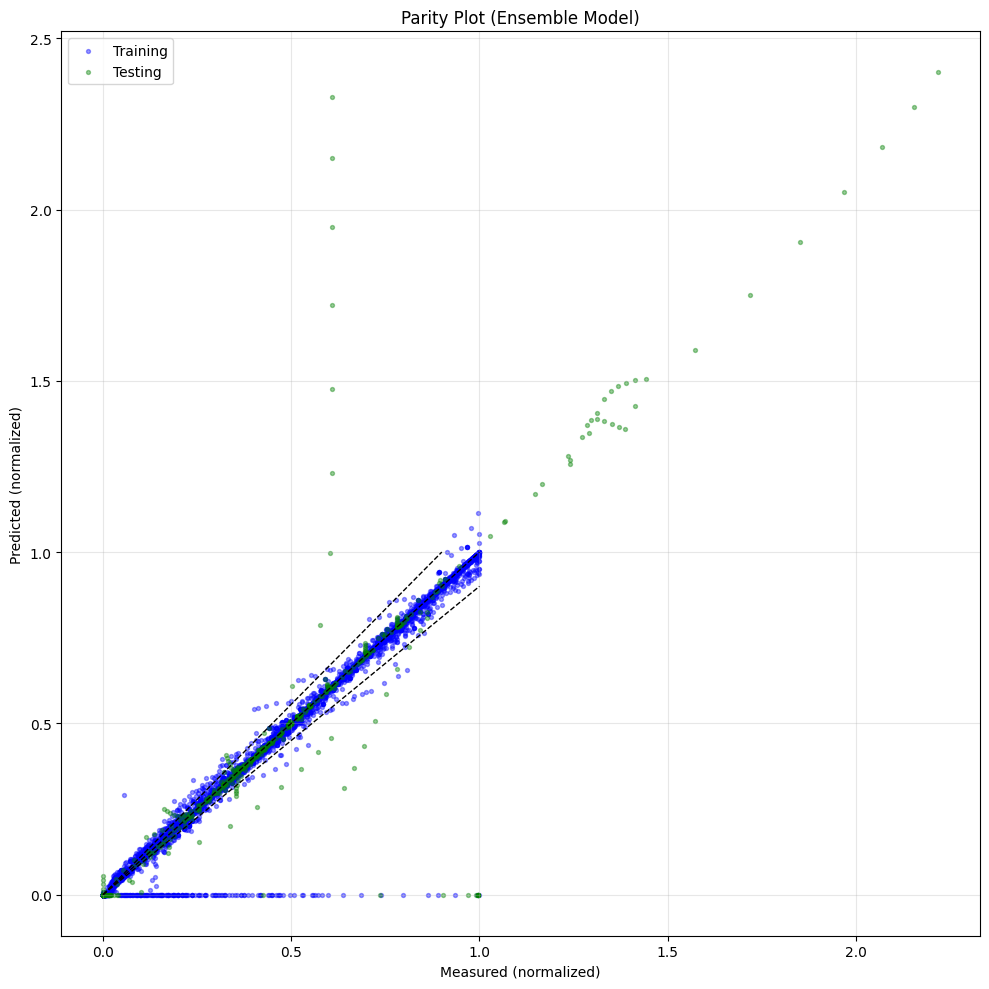

In [380]:
############################### Cell 18: Parity Plot ######################################

model_paths = final_fold_models

@torch.compile(fullgraph=False)
def get_ensemble_predictions_for_batches(models_paths, target_data, t_Data, v_data, batches,
                                         target_max, output_max, controls):

    dim_t = len(t_Data)
    n_models = len(models_paths)

    measured_list = []
    pred_sum = None

    with torch.no_grad():

        ######################## Ensemble predictions ########################
        for model_path in models_paths:

            checkpoint = torch.load(model_path)

            net = FFNN(
                input_dim=inputs_num,
                hidden_layers=nh,
                output_dim=outputs_num,
                activation=activation )
            
            net.load_state_dict(checkpoint["model_state_dict"])
            net.eval()

            state_with_v = torch.cat(
                (target_data[batches, 0, :],
                 v_data[batches, 0].unsqueeze(1)), dim=1)

            preds = []

            for i in range(dim_t - 1):

                state_with_v = solve_ode_semi_parametric(
                    ode_func=solve_ode,
                    state=state_with_v,
                    model=net,   
                    target_max=target_max,
                    output_max=output_max,
                    controls=controls[batches, i, :],
                    t=t_Data[i],
                    tf=t_Data[i+1],
                    h=h)

                preds.append((state_with_v[:, :-1] / target_max).cpu().numpy())

            preds = np.array(preds)  # (time-1, batch, species)

            pred_sum = preds if pred_sum is None else (pred_sum + preds)

        pred_avg = pred_sum / n_models

        ######################## Measured values ########################
        for i in range(dim_t - 1):
            meas = (target_data[batches, i+1] / target_max).numpy()
            measured_list.append(meas)

        measured_arr = np.array(measured_list)

    return measured_arr, pred_avg

trainval_batches = [b for b in batch_numbers if b not in testbatch]

#get train predictions
train_meas, train_pred = get_ensemble_predictions_for_batches(
    models_paths=model_paths,
    target_data=target_data,
    t_Data=time_data,
    v_data=volume_data,
    batches=trainval_batches,
    target_max=target_max,
    output_max=output_max,
    controls=controls_sequence
)

#get test predictions
test_meas, test_pred = get_ensemble_predictions_for_batches(
    models_paths=model_paths,
    target_data=target_data,
    t_Data=time_data,
    v_data=volume_data,
    batches=testbatch,
    target_max=target_max,
    output_max=output_max,
    controls=controls_sequence
)

plt.figure(figsize=(10,10))
plt.scatter(train_meas.reshape(-1), train_pred.reshape(-1), s=8, alpha=0.40, color='blue', label='Training')
plt.scatter(test_meas.reshape(-1), test_pred.reshape(-1), s=8, alpha=0.40, color='green', label='Testing')

#parity lines
plt.plot([0, 1], [0, 1], 'k--', lw=1.0)
plt.plot([0, 0.90], [0, 1], 'k--', lw=1)
plt.plot([0, 1], [0, 0.90], 'k--', lw=1)

plt.xlabel("Measured (normalized)")
plt.ylabel("Predicted (normalized)")
plt.title("Parity Plot (Ensemble Model)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




In [381]:
################################################ Cell 19: True vs Predicted, True vs Noisy ################################

########################################################## Prepare True Data ##############################################
print(arch_tag)
print()

#full model batch indices
trainval_batches = [b for b in batch_numbers if b not in testbatch]

if run_training:
    model_paths = [f"Model_results_LOOCV_{i+1}_{arch_tag}_trial_{best_trial_num}.pt" if LOOCV 
          else f"Model_results_SR_{i+1}_{arch_tag}_trial_{best_trial_num}.pt" for i in range(len(trainbatches))]
else:
    model_paths = [f"Model_results_LOOCV_{i+1}_{arch_tag}.pt" if LOOCV 
          else f"Model_results_SR_{i+1}_{arch_tag}.pt" for i in range(len(trainbatches))]
     
@torch.compile(fullgraph=False)
def calculate_metrics_vs_true(true_data, compare_data, stds_for_data, batches):

    testloss, test_r2 = 0, 0
    dim_t = true_data.shape[1]

    y_true = []
    y_pred = []

    with torch.no_grad(): 
        #loop ODE system over time points to get predictions
        for i in range(dim_t - 1):

            #calculate test loss and r2, summing over time
            testloss += WMSE(
                target_data=true_data[batches, i+1],
                predicted_data=compare_data[batches, i+1],
                stds_for_data=stds_for_data[batches, i+1])
            
            #append measured values (no volume)
            y_true.append(true_data[batches, i+1])
            #append predicted values (no volume)
            y_pred.append(compare_data[batches, i+1])

    y_true = torch.cat(y_true, dim=0)
    y_pred = torch.cat(y_pred, dim=0)
    y_true_np = y_true.detach().cpu().numpy() / target_max
    y_pred_np = y_pred.detach().cpu().numpy() / target_max
    test_r2 = r2_score(y_true_np.reshape(-1), y_pred_np.reshape(-1))
    testloss = testloss / (dim_t - 1)

    return testloss, test_r2

################################# Noisy vs True #######################################

#for training and validation
noisy_vs_true_trainval_wmse, noisy_vs_true_trainval_r2 = calculate_metrics_vs_true(
    true_data=true_data,
    compare_data=target_data,
    stds_for_data=stds_for_data,
    batches=trainval_batches)

#for testing
if testbatch != []:
    noisy_vs_true_test_wmse, noisy_vs_true_test_r2 = calculate_metrics_vs_true(
        true_data=true_data,
        compare_data=target_data,
        stds_for_data=stds_for_data,
        batches=testbatch)

################################# Predicted vs True ####################################

#TRAIN+VAL predictions (ensemble) 
meas_trainval, pred_trainval = get_ensemble_predictions_for_batches(
    models_paths=model_paths,
    target_data=target_data,
    t_Data=time_data,
    v_data=volume_data,
    batches=trainval_batches,
    target_max=target_max,
    output_max=output_max,
    controls=controls_sequence
)

pred_trainval = torch.from_numpy(pred_trainval) * target_max

pred_full_trainval = true_data.clone()
for j, b in enumerate(trainval_batches):
    pred_full_trainval[b, 1:, :] = pred_trainval[:, j, :]


#TEST predictions (ensemble) 
if testbatch != []:
    meas_test, pred_test = get_ensemble_predictions_for_batches(
        models_paths=model_paths,
        target_data=target_data,
        t_Data=time_data,
        v_data=volume_data,
        batches=testbatch,
        target_max=target_max,
        output_max=output_max,
        controls=controls_sequence
    )

    pred_test = torch.from_numpy(pred_test) * target_max

    pred_full_test = true_data.clone()
    for j, b in enumerate(testbatch):
        pred_full_test[b, 1:, :] = pred_test[:, j, :]

############################################ Metrics ##################################

#train+Val vs True
pred_vs_true_trainval_wmse, pred_vs_true_trainval_r2 = calculate_metrics_vs_true(
    true_data=true_data,
    compare_data=pred_full_trainval,
    stds_for_data=stds_for_data,
    batches=trainval_batches
)

#train+Val vs Noisy
pred_vs_noisy_trainval_wmse, pred_vs_noisy_trainval_r2 = calculate_metrics_vs_true(
    true_data=target_data,
    compare_data=pred_full_trainval,
    stds_for_data=stds_for_data,
    batches=trainval_batches
)

#test vs True
if testbatch != []:
    pred_vs_true_test_wmse, pred_vs_true_test_r2 = calculate_metrics_vs_true(
        true_data=true_data,
        compare_data=pred_full_test,
        stds_for_data=stds_for_data,
        batches=testbatch
    )

#test vs Noisy
if testbatch != []:
    pred_vs_noisy_test_wmse, pred_vs_noisy_test_r2 = calculate_metrics_vs_true(
        true_data=target_data,
        compare_data=pred_full_test,
        stds_for_data=stds_for_data,
        batches=testbatch
    )

#asemble metrics table
records = []

def add_row(dataset, comparison, wmse, r2):
    records.append({
        "Dataset": dataset,
        "Comparison": comparison,
        "WMSE": wmse,
        "R2": r2
    })

#baseline
add_row("Train+Val", "Noisy vs True", noisy_vs_true_trainval_wmse, noisy_vs_true_trainval_r2)
add_row("Test", "Noisy vs True", noisy_vs_true_test_wmse, noisy_vs_true_test_r2)

#model results
add_row("\nTrain+Val ", "Pred vs Noisy", pred_vs_noisy_trainval_wmse, pred_vs_noisy_trainval_r2)
add_row("Test", "Pred vs Noisy", pred_vs_noisy_test_wmse, pred_vs_noisy_test_r2)

add_row("\nTrain+Val ", "Pred vs True", pred_vs_true_trainval_wmse, pred_vs_true_trainval_r2)
add_row("Test", "Pred vs True", pred_vs_true_test_wmse, pred_vs_true_test_r2)

header = (f"{'Dataset':<10} | {'Comparison':<15} | {'WMSE':^8} | {'R²':^8}")

#print table
print(header)
print("-" * len(header))

for r in records:
    print(f"{r['Dataset']:<10} | {r['Comparison']:<15} | {r['WMSE']:^8.4f} | {r['R2']:^8.4f}")

#Dataset    | Comparison      |   WMSE   |    R²   
#Train+Val  | Noisy vs True   |  0.0765  |  0.9602 
#Test       | Noisy vs True   |  0.0651  |  0.9730 

#Train+Val  | Pred vs Noisy   |  0.0841  |  0.9554 
#Test       | Pred vs Noisy   |  0.4955  |  0.7733 

#Train+Val  | Pred vs True    |  0.0120  |  0.9914 
#Test       | Pred vs True    |  0.4162  |  0.8067 

26_[25]_25_AICc_MaxFixed

Dataset    | Comparison      |   WMSE   |    R²   
--------------------------------------------------
Train+Val  | Noisy vs True   |  0.0000  |  1.0000 
Test       | Noisy vs True   |  0.0000  |  1.0000 

Train+Val  | Pred vs Noisy   |  0.0450  |  0.9727 
Test       | Pred vs Noisy   |  0.7234  |  0.6658 

Train+Val  | Pred vs True    |  0.0450  |  0.9727 
Test       | Pred vs True    |  0.7234  |  0.6658 


C:\Users\leono\AppData\Local\Temp\ipykernel_26944\3323714194.py:50: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1857.)
  std_pred  = pred_models.std(dim=0)


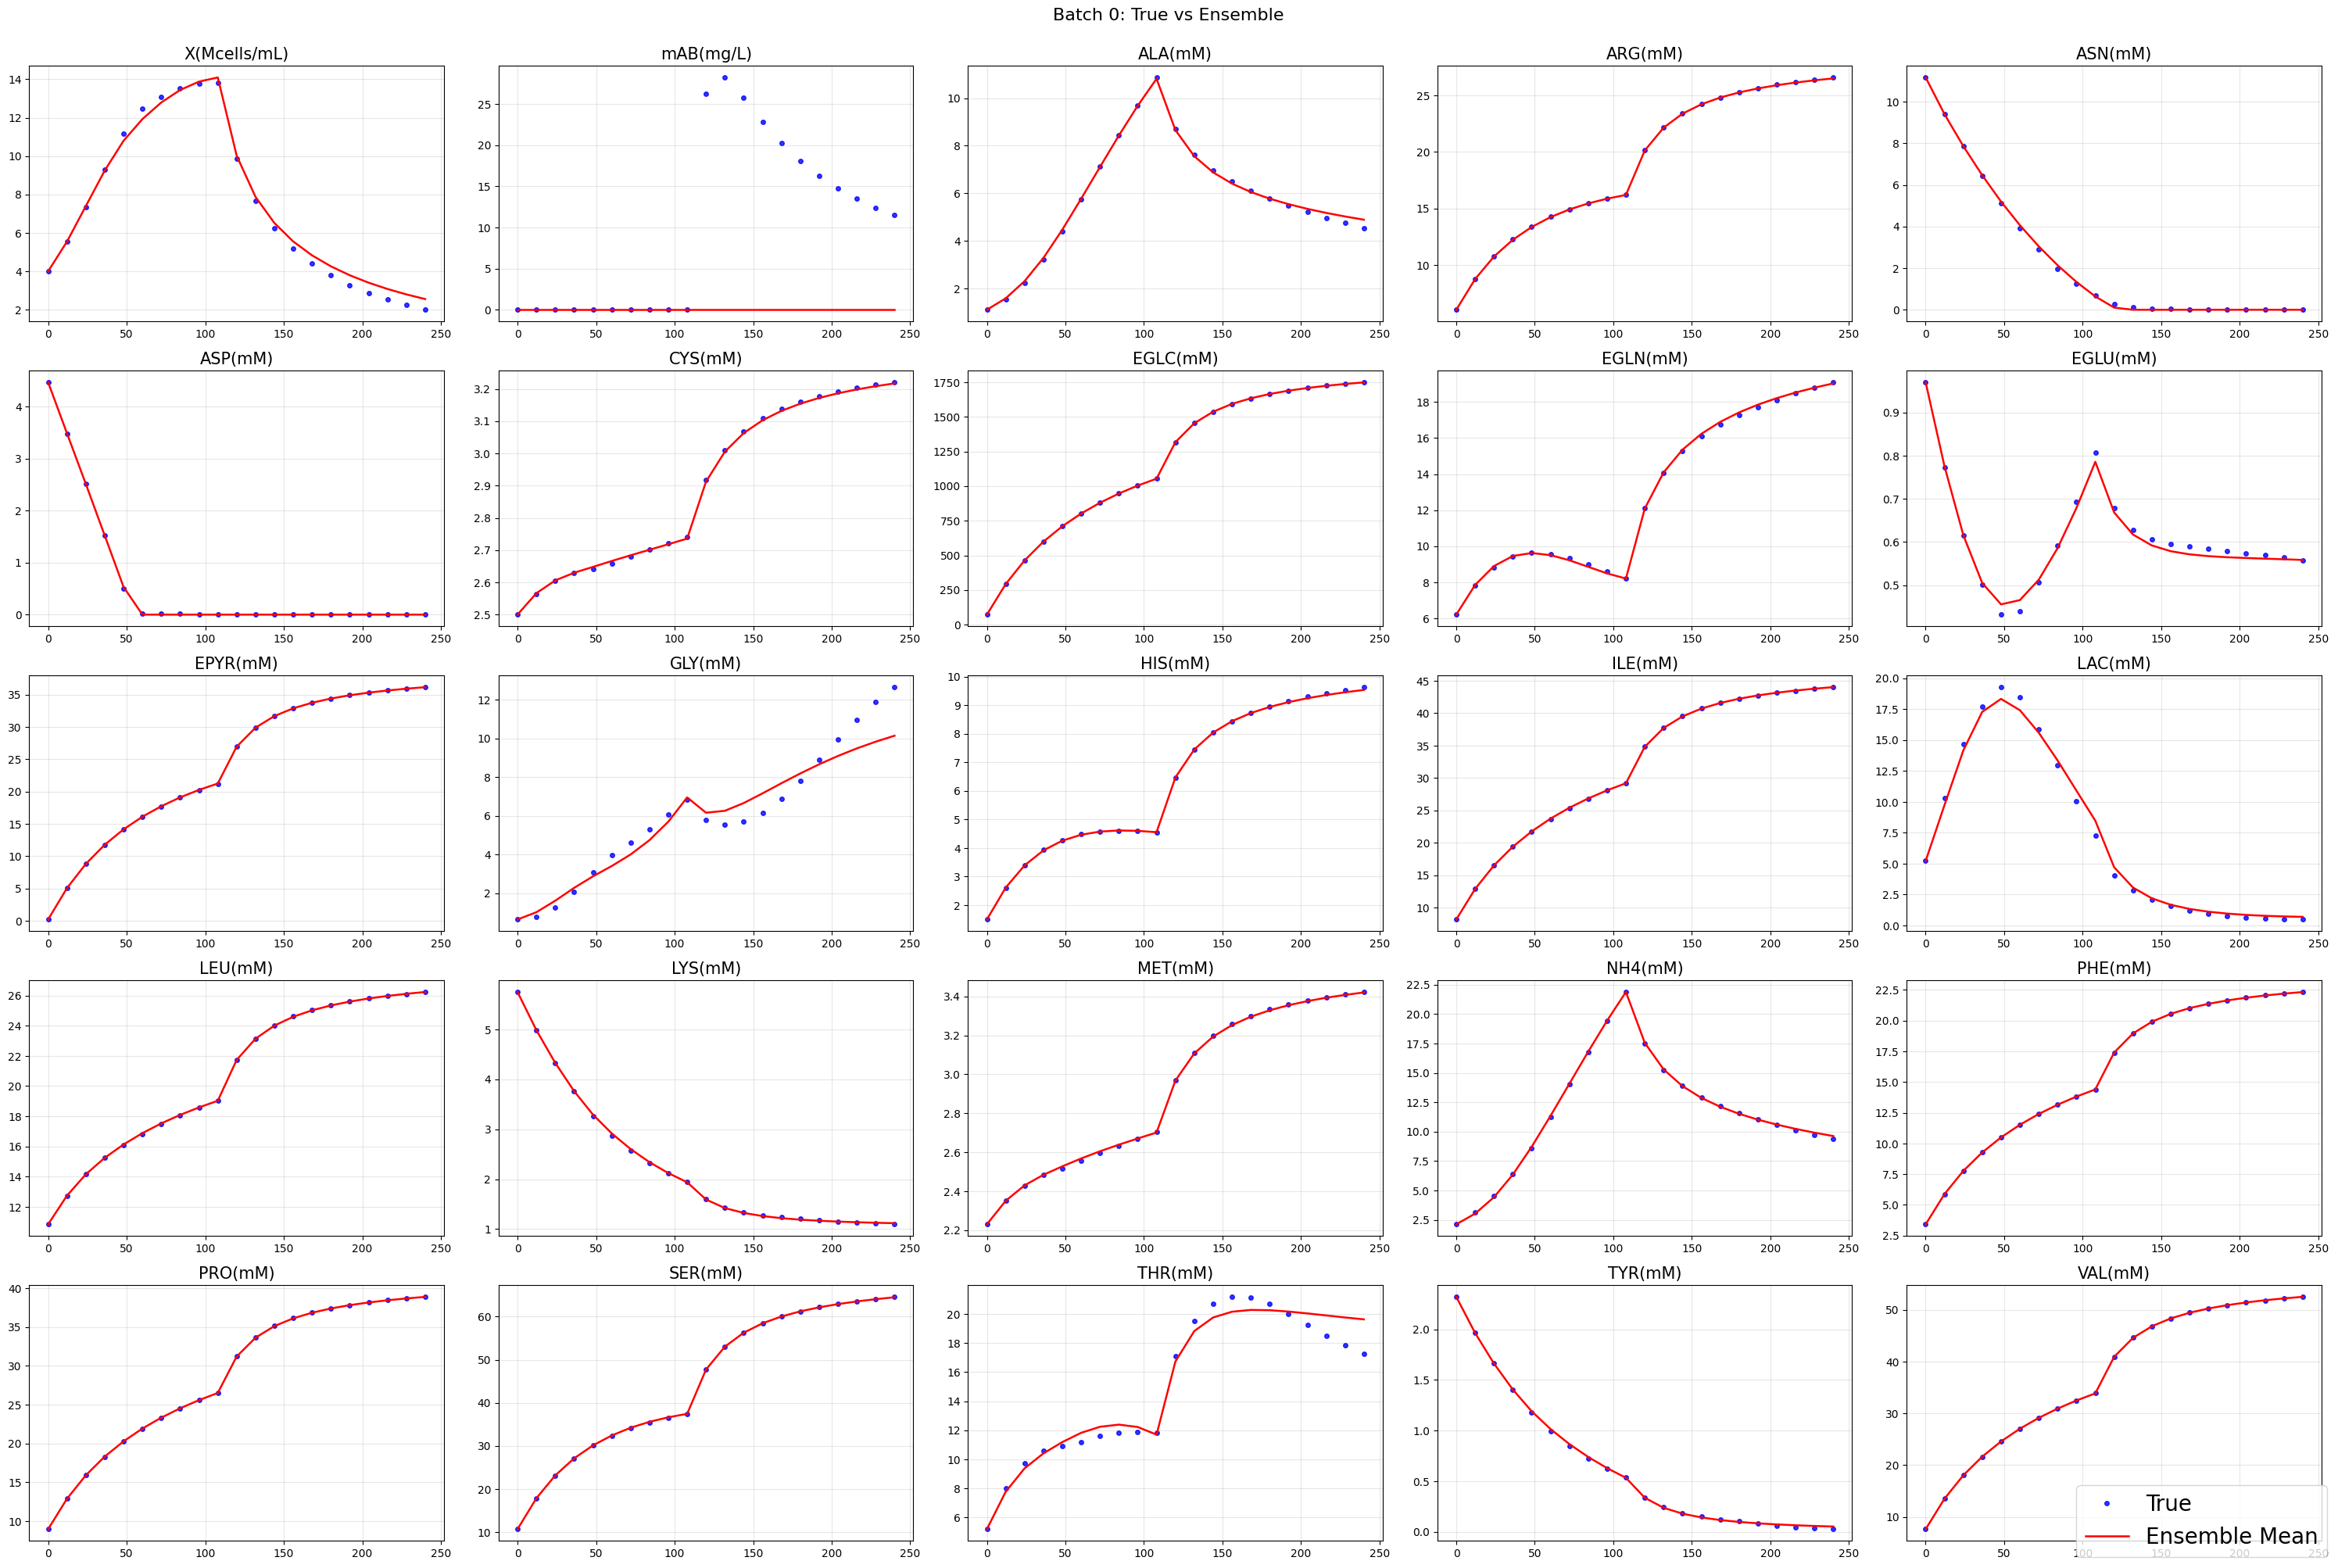

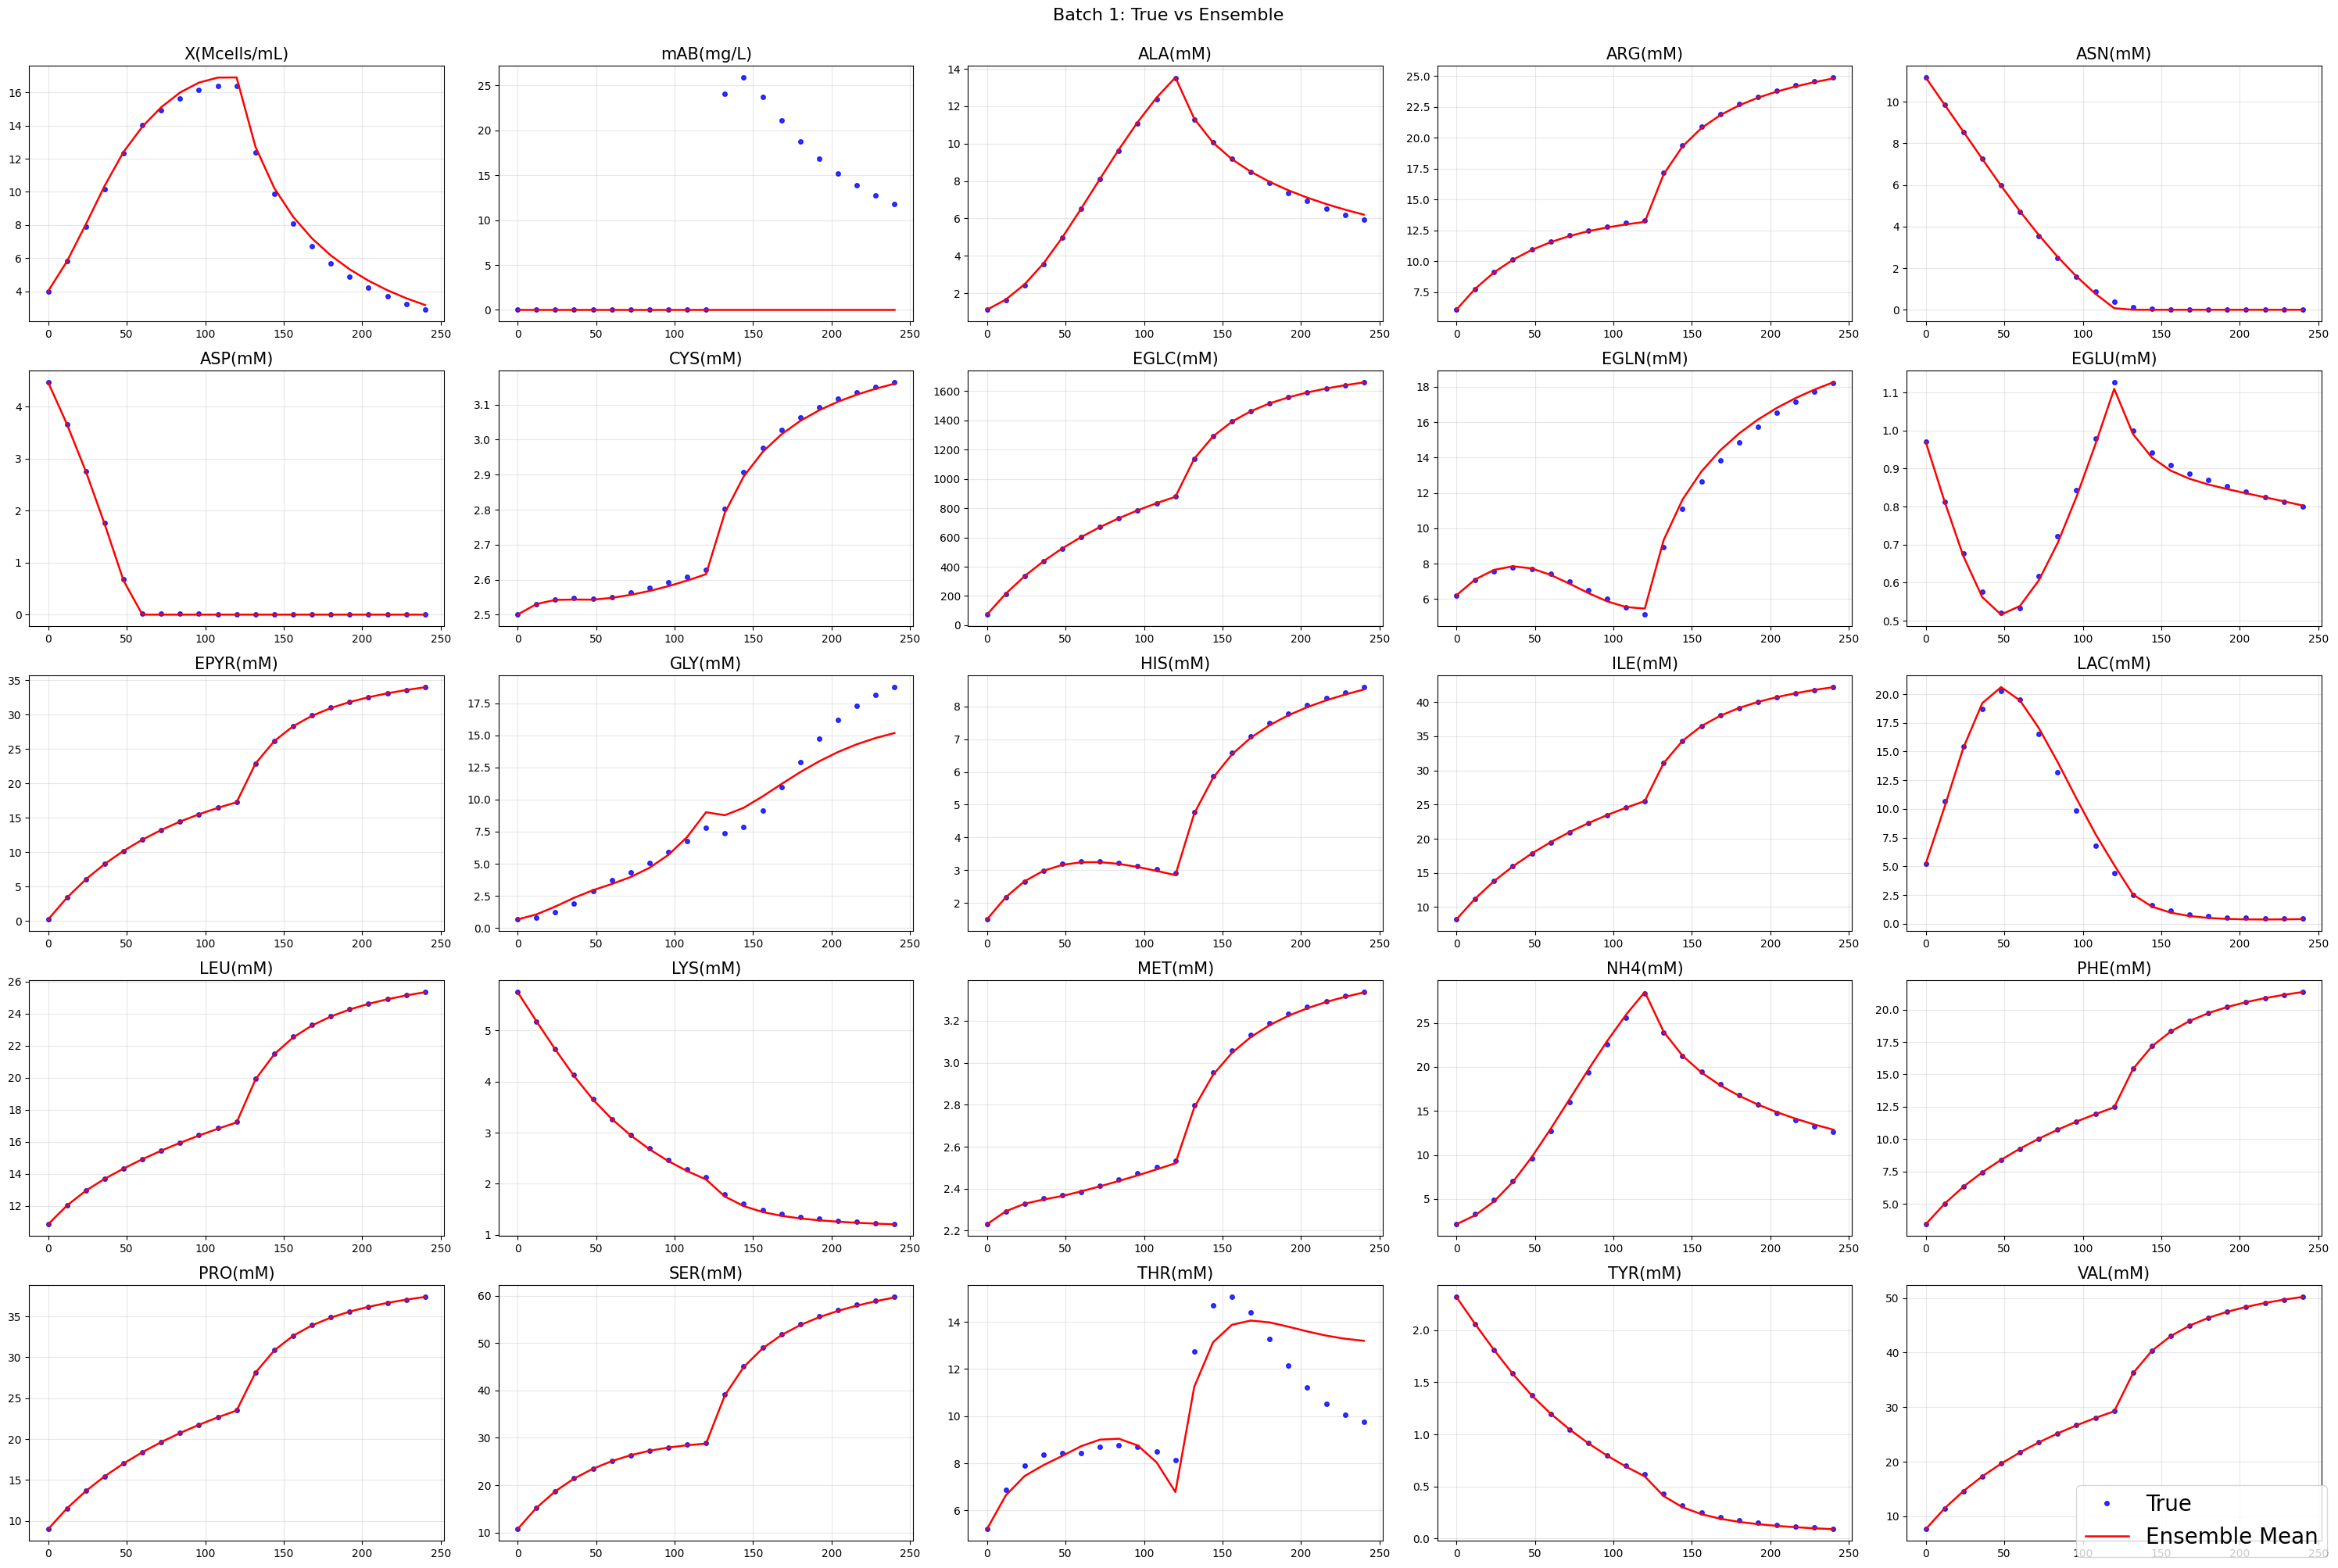

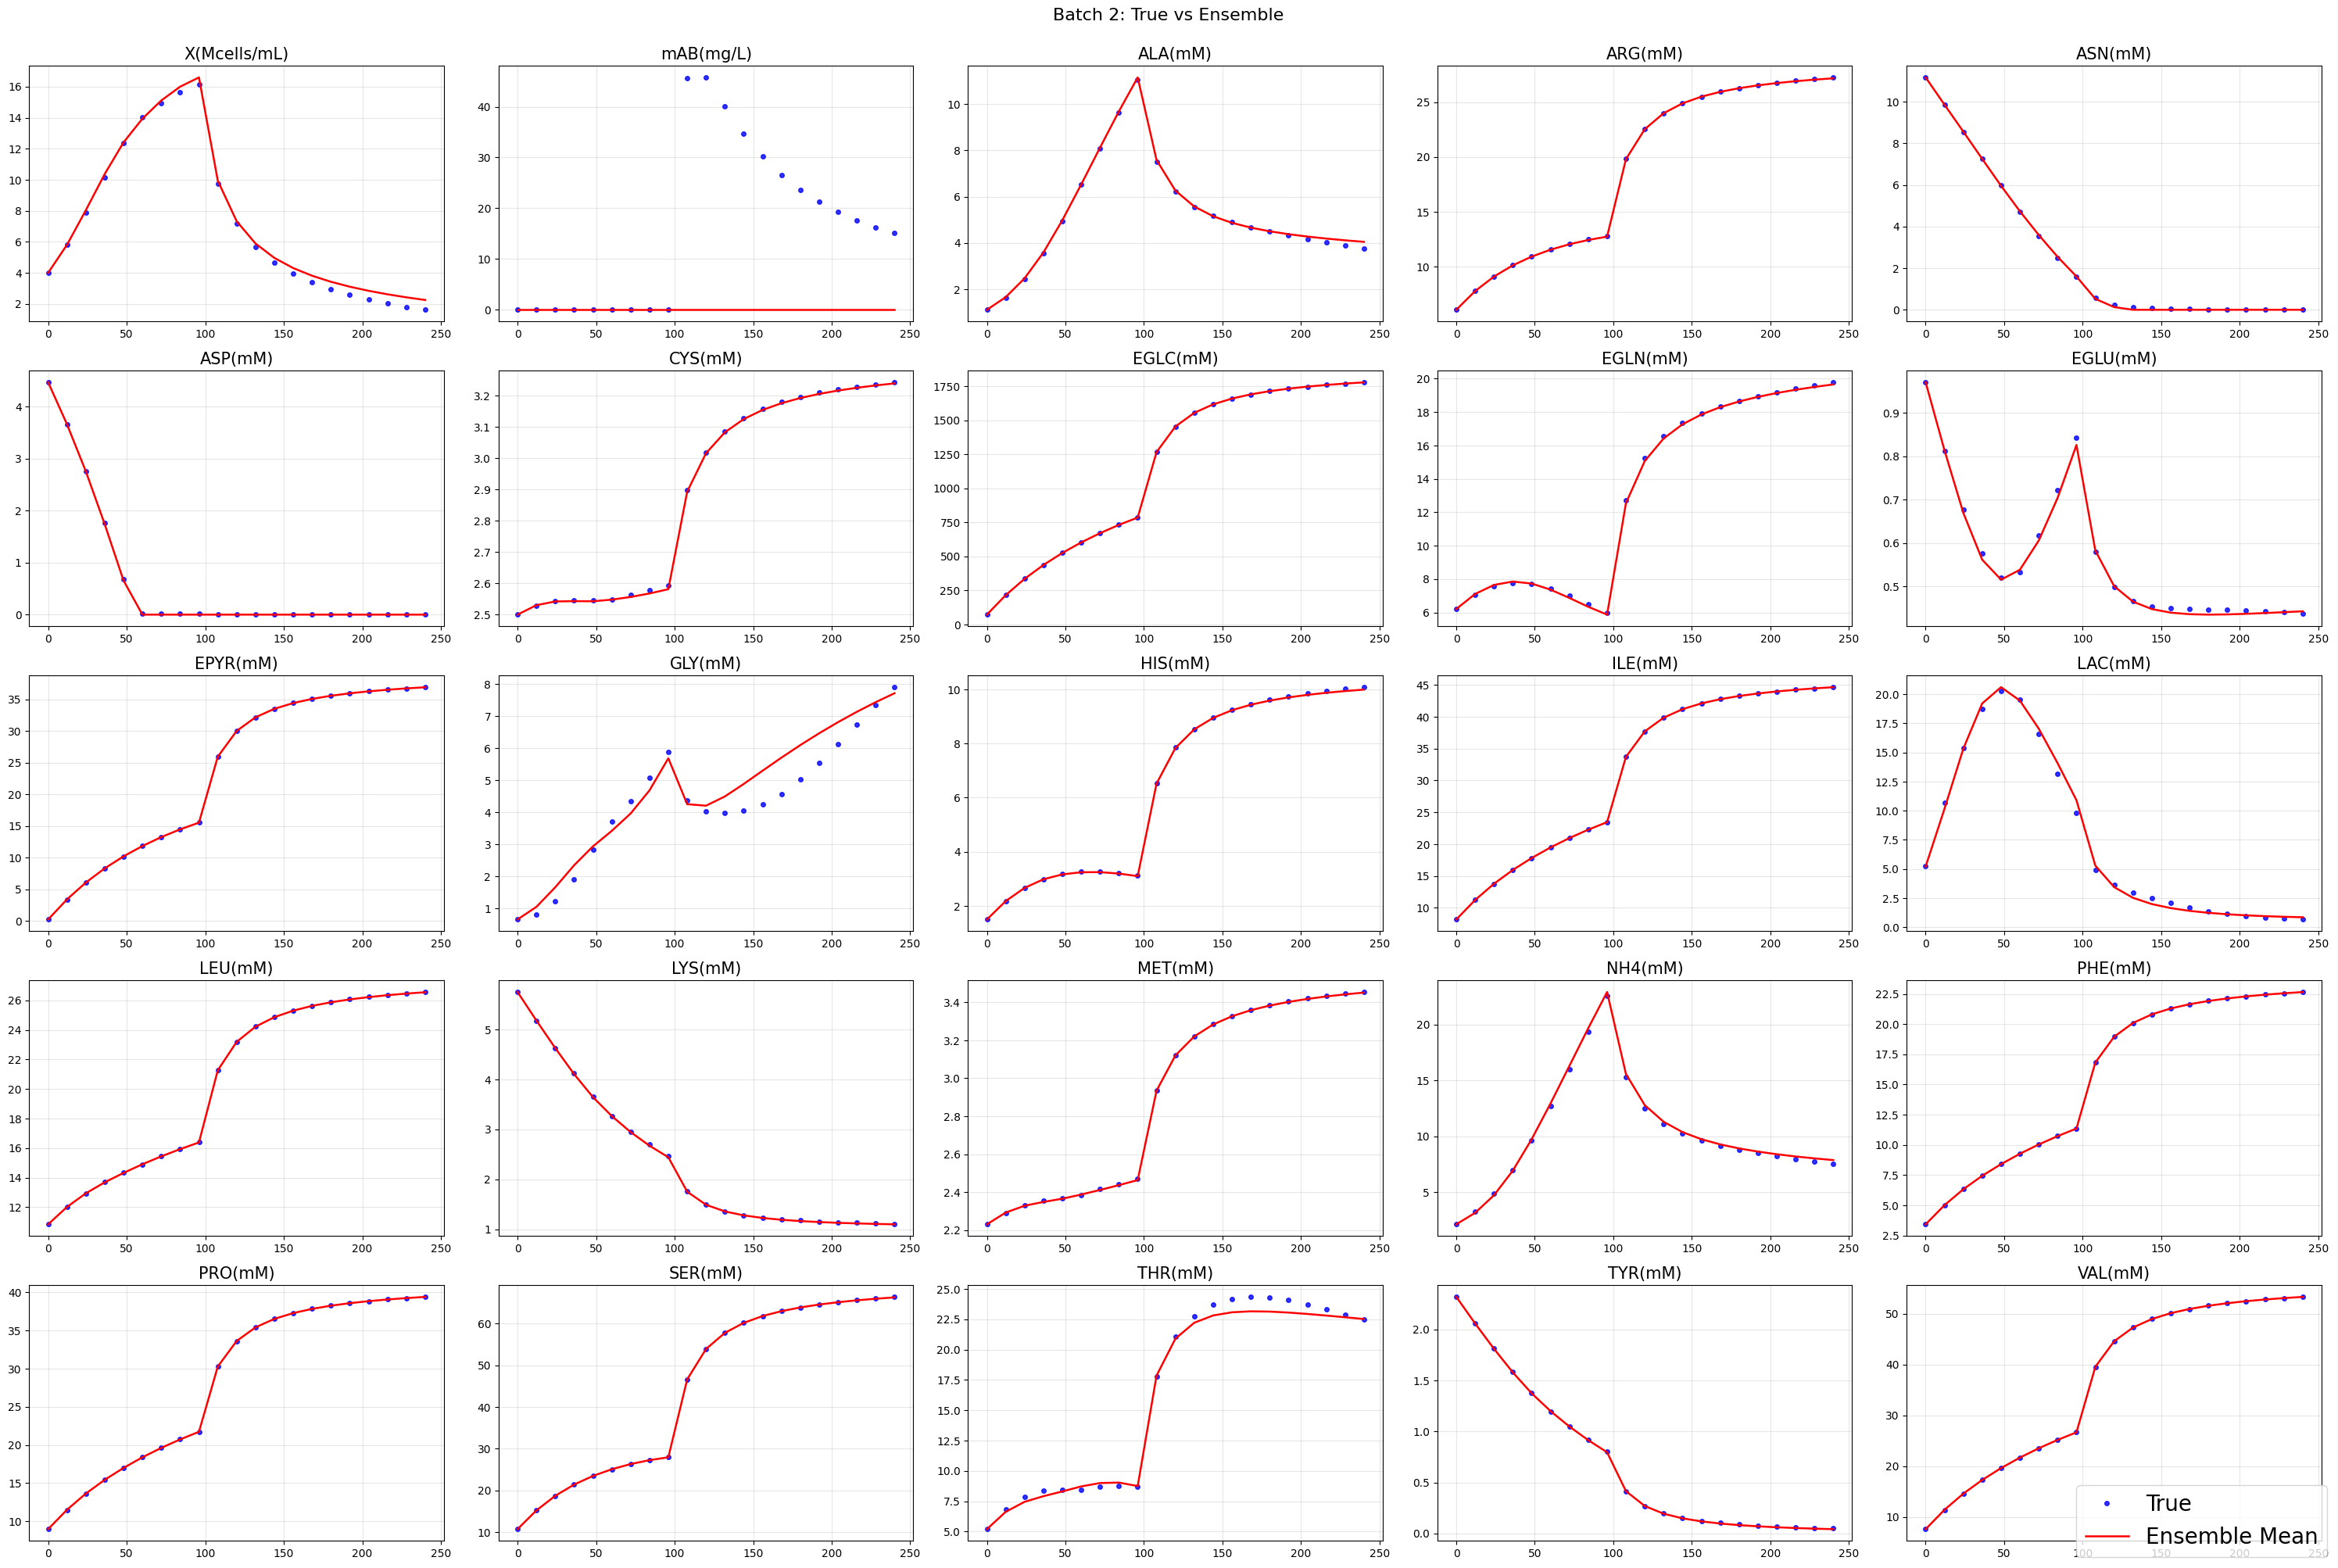

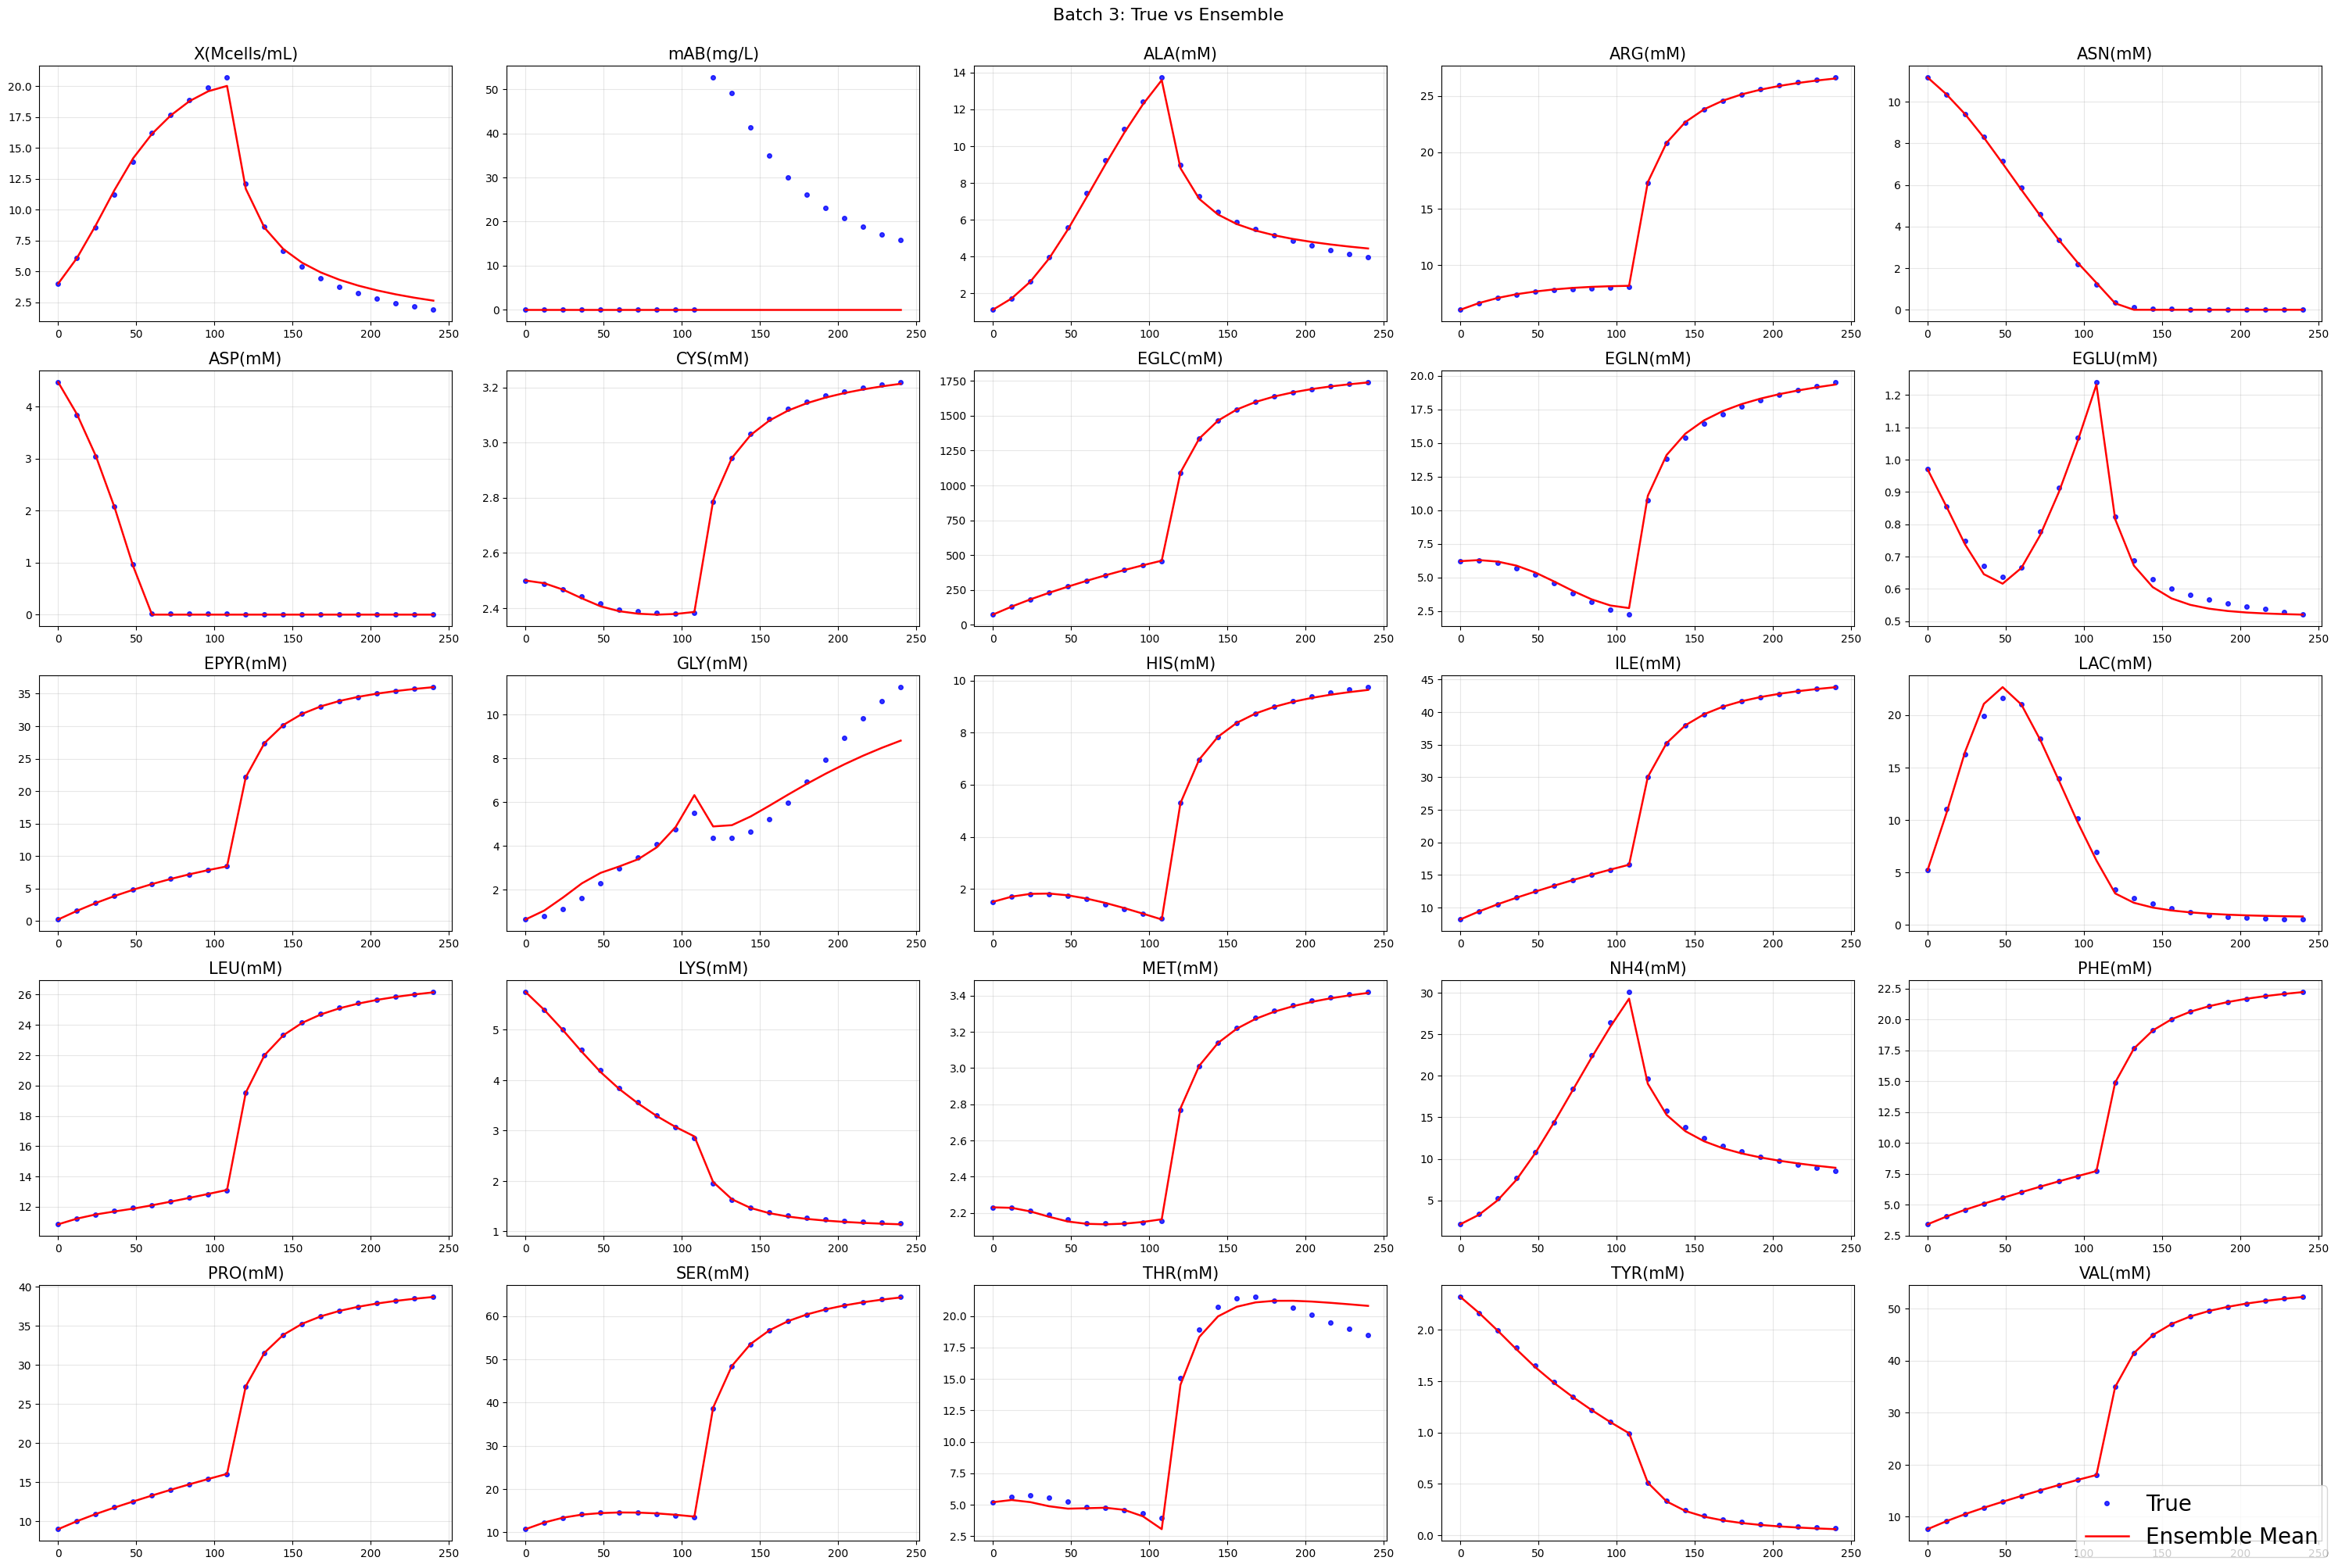

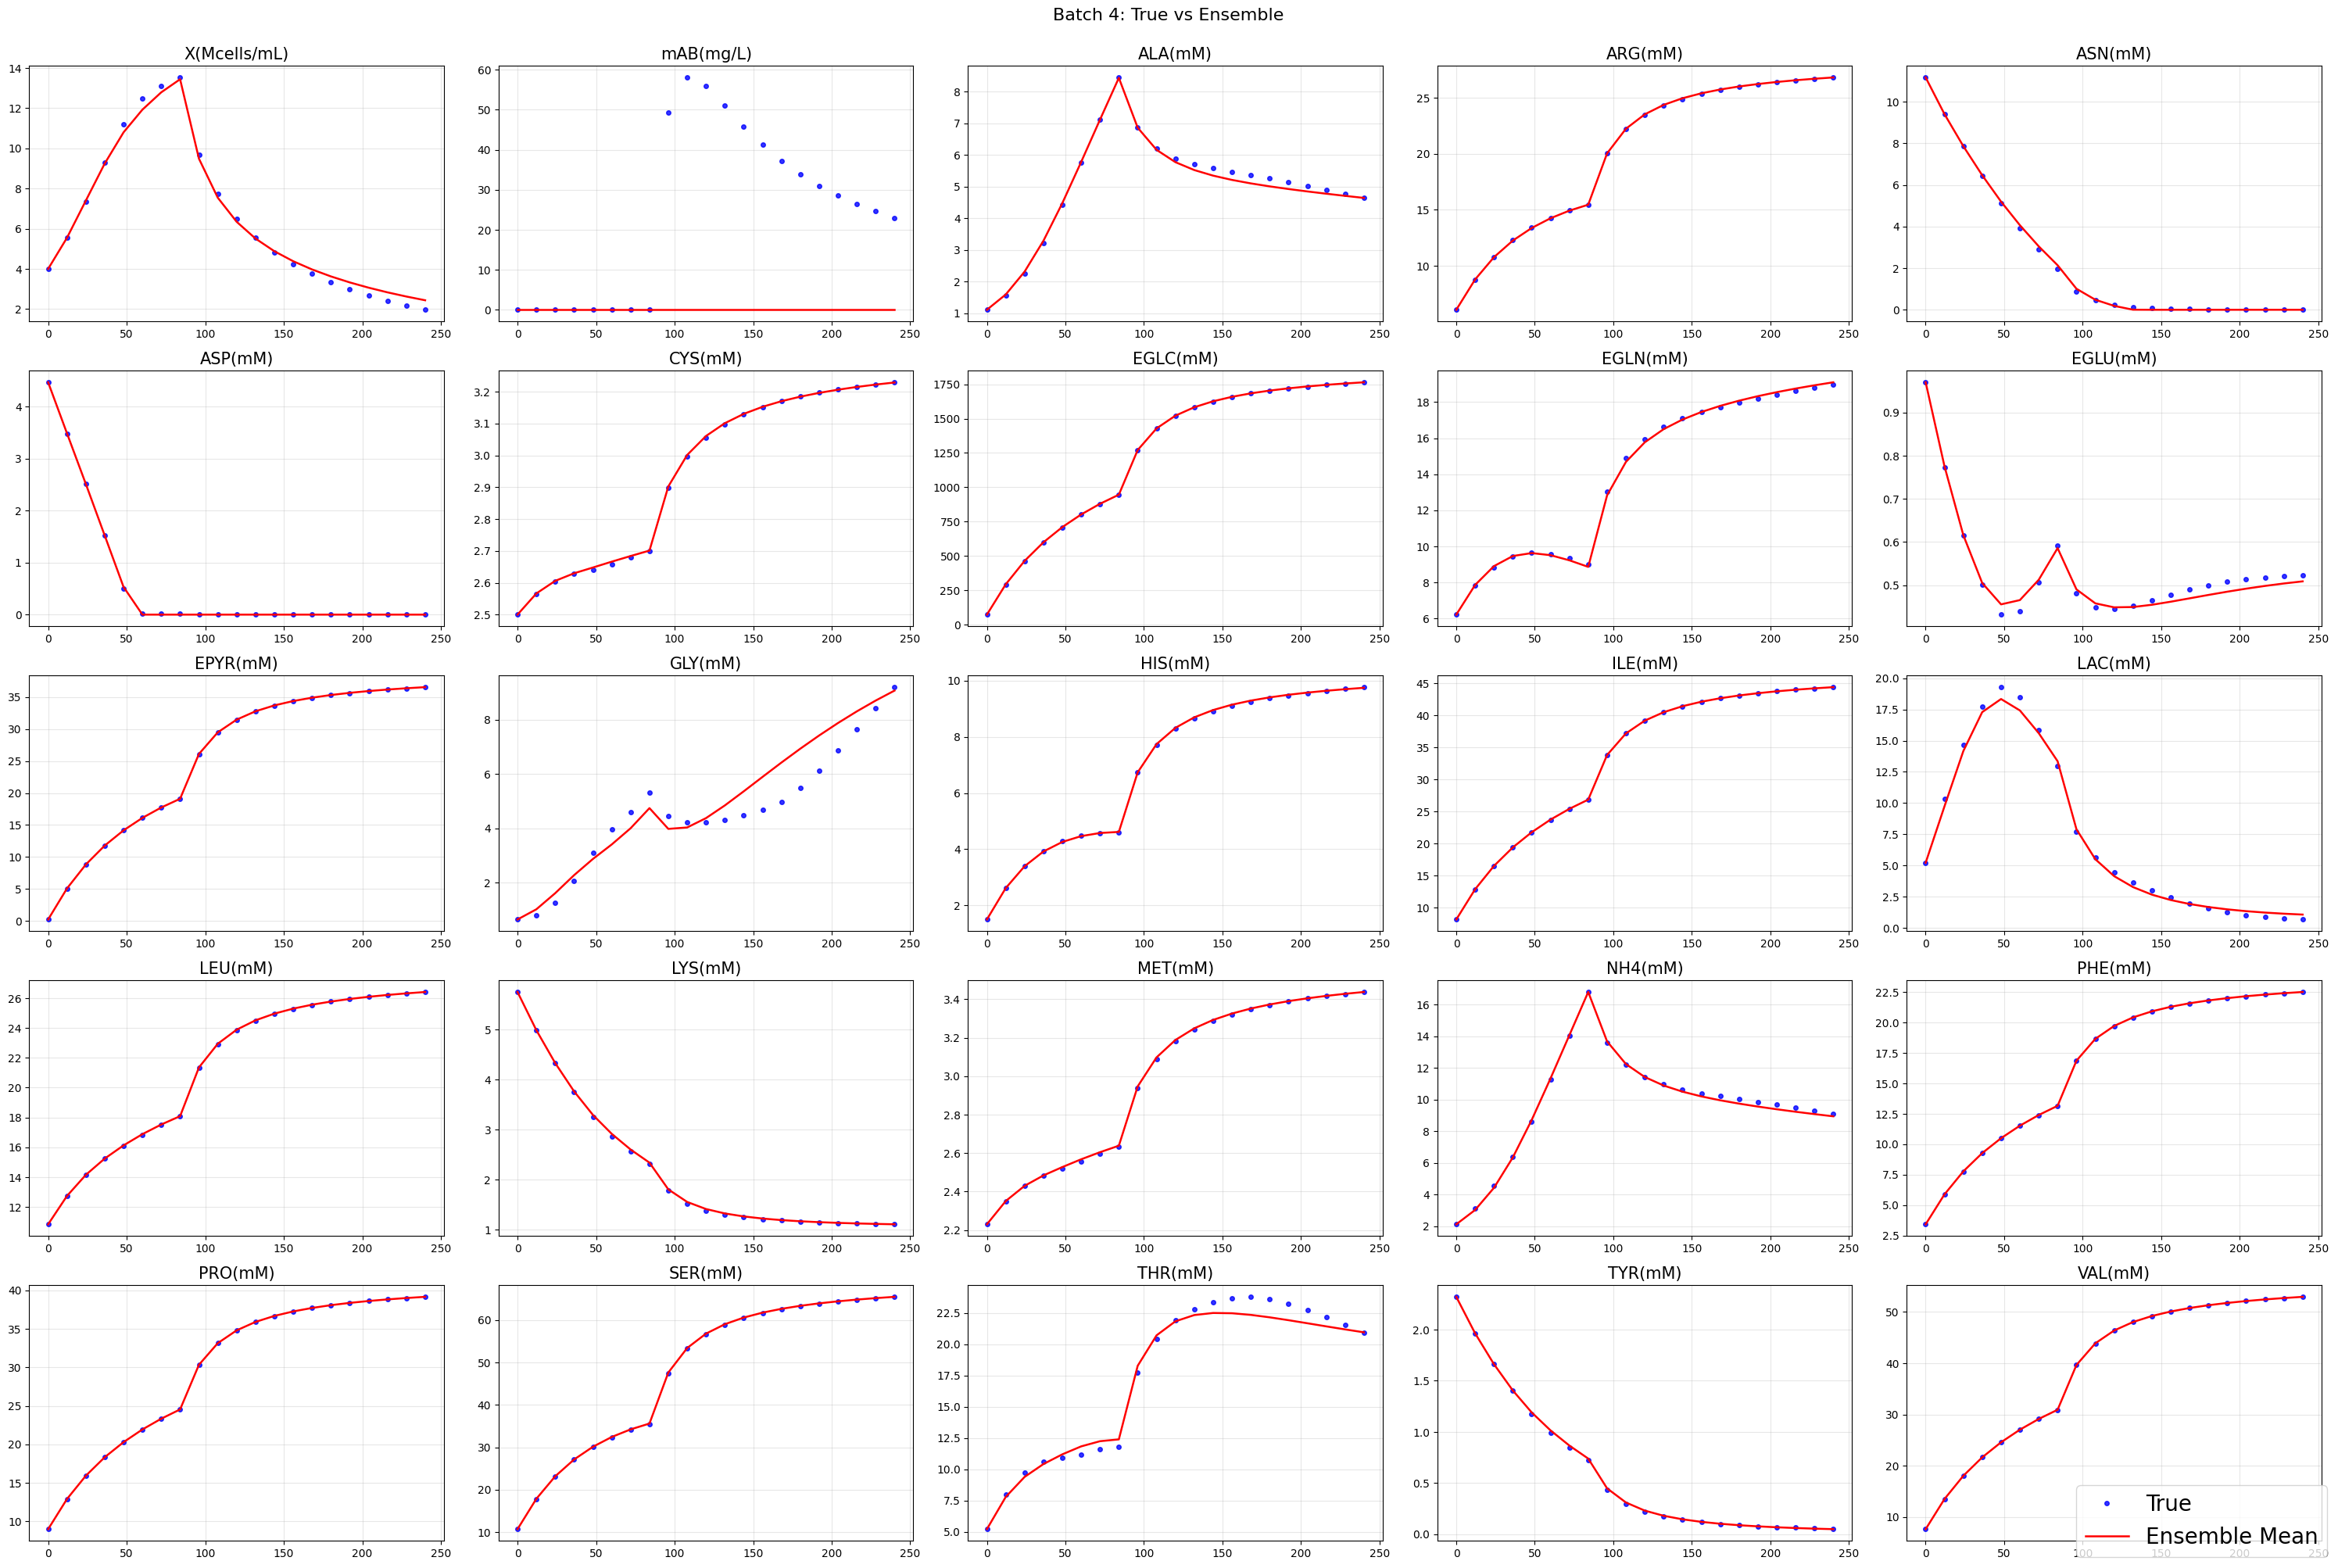

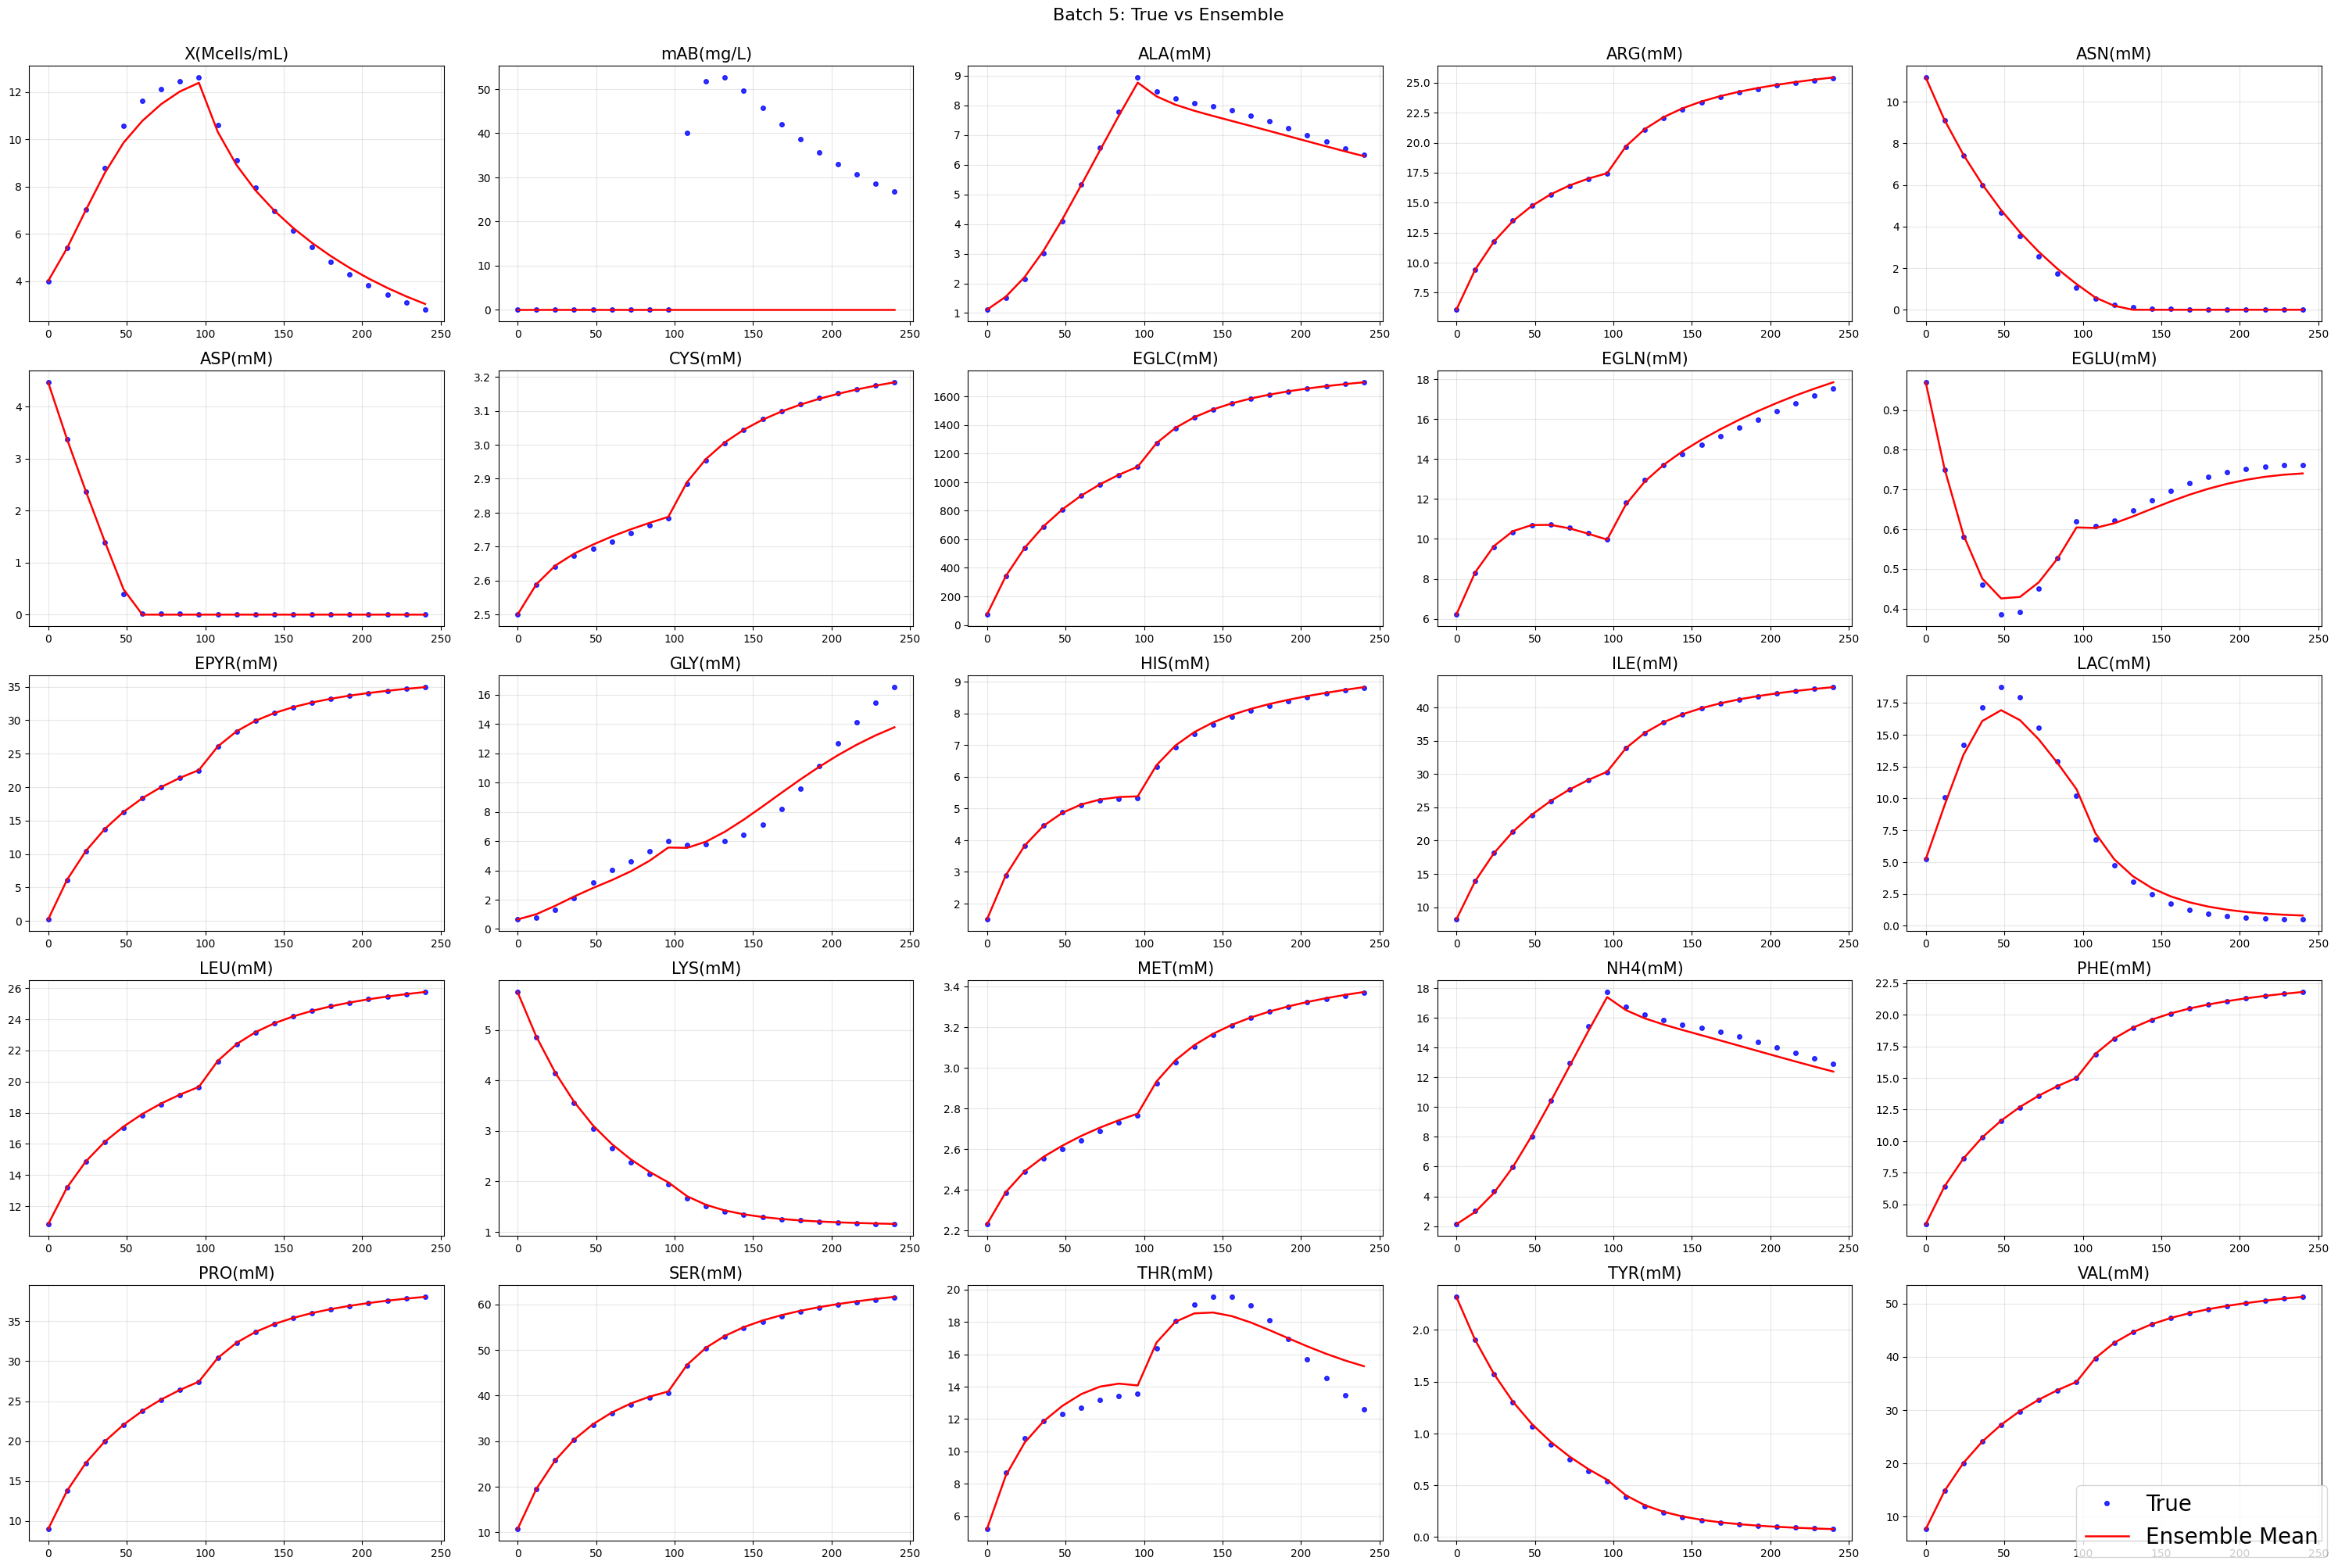

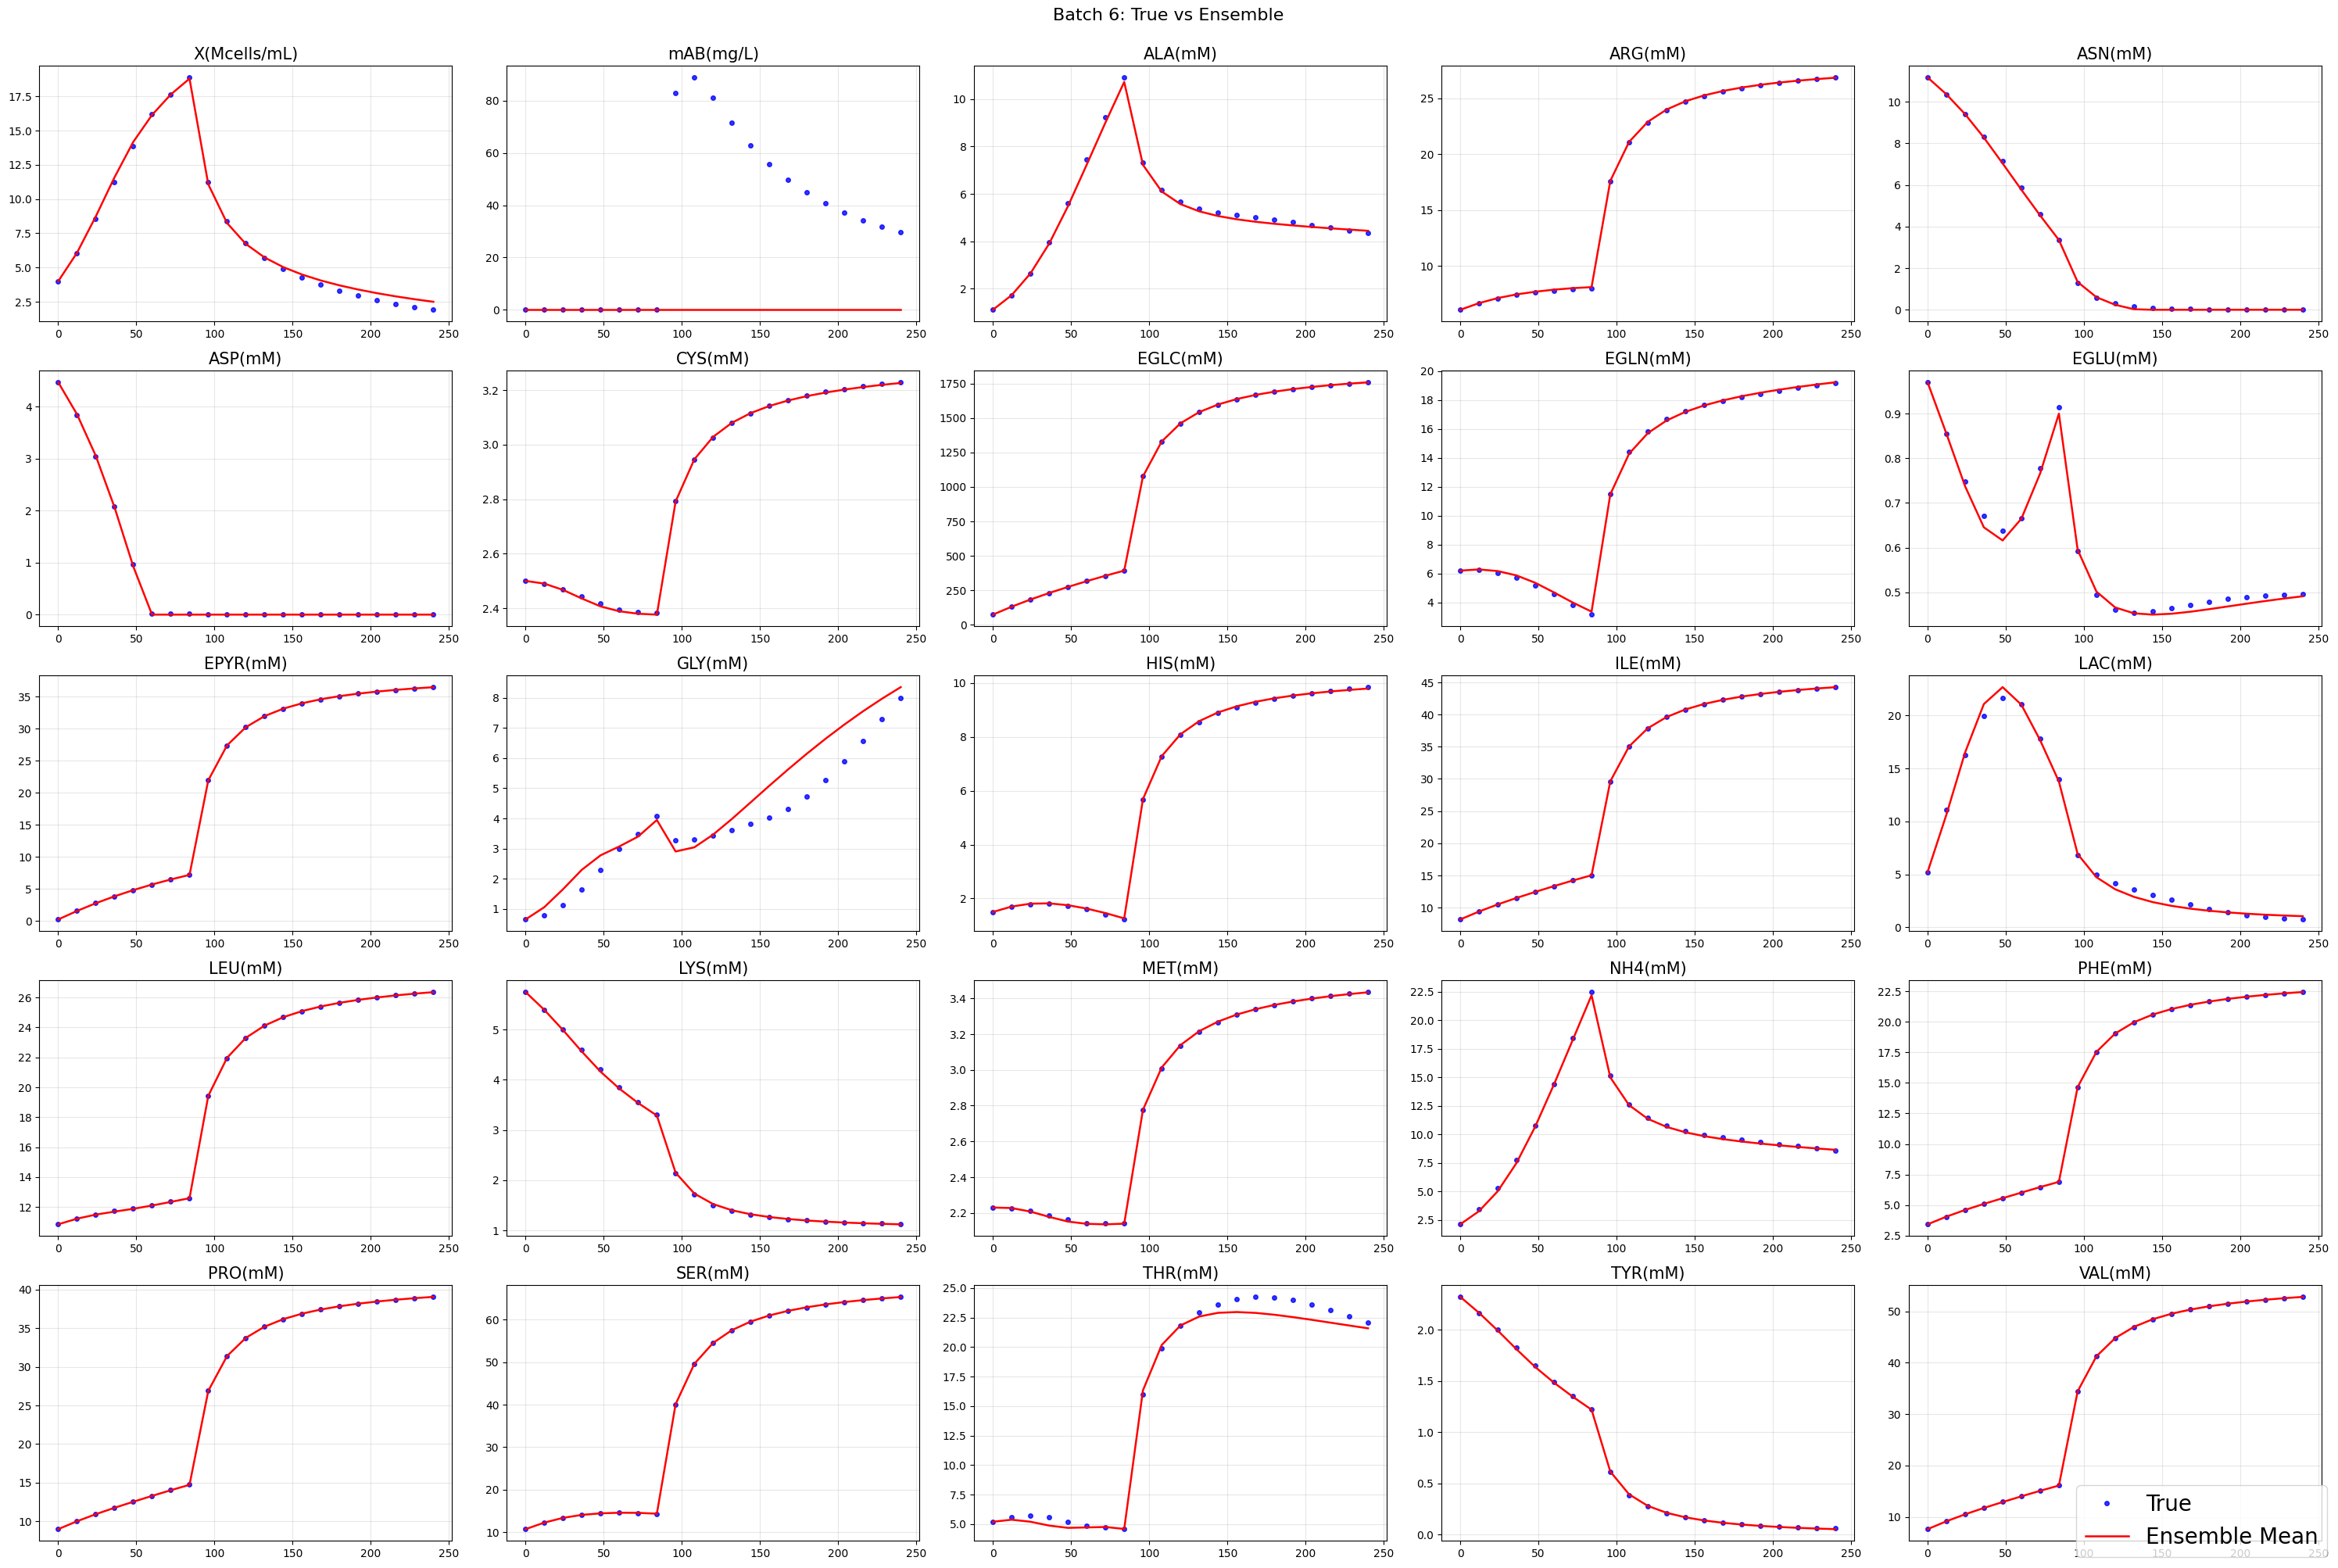

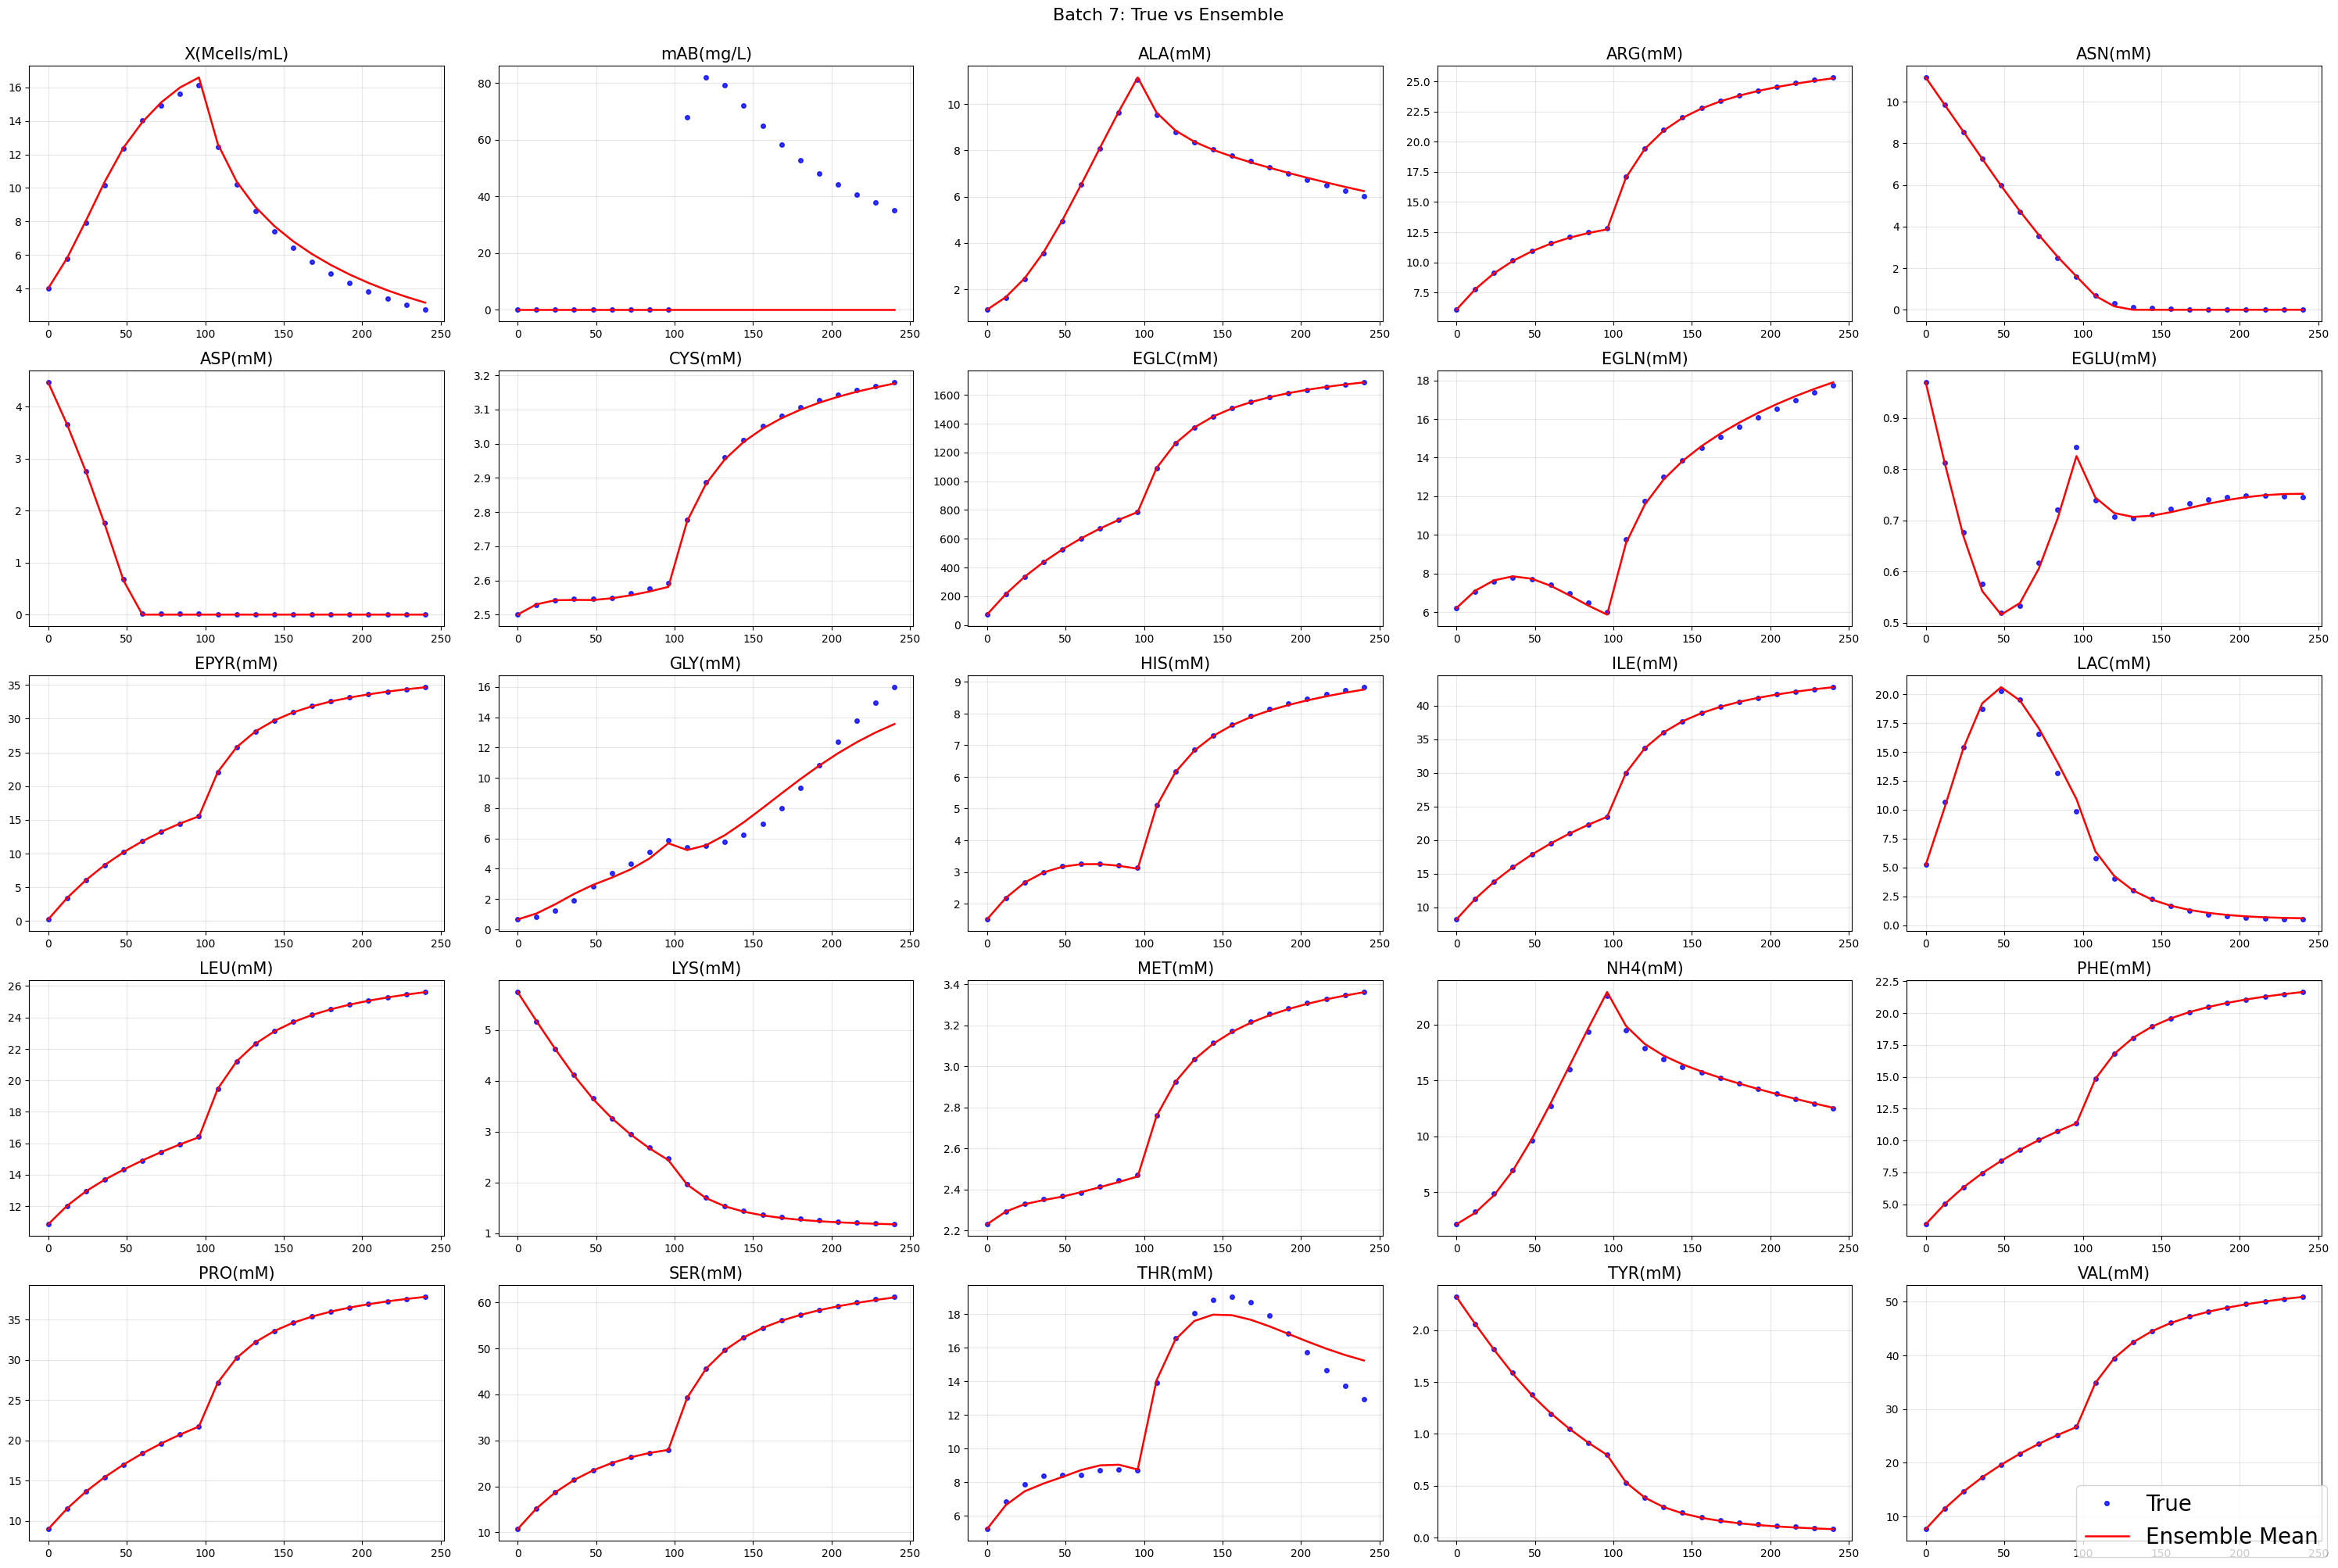

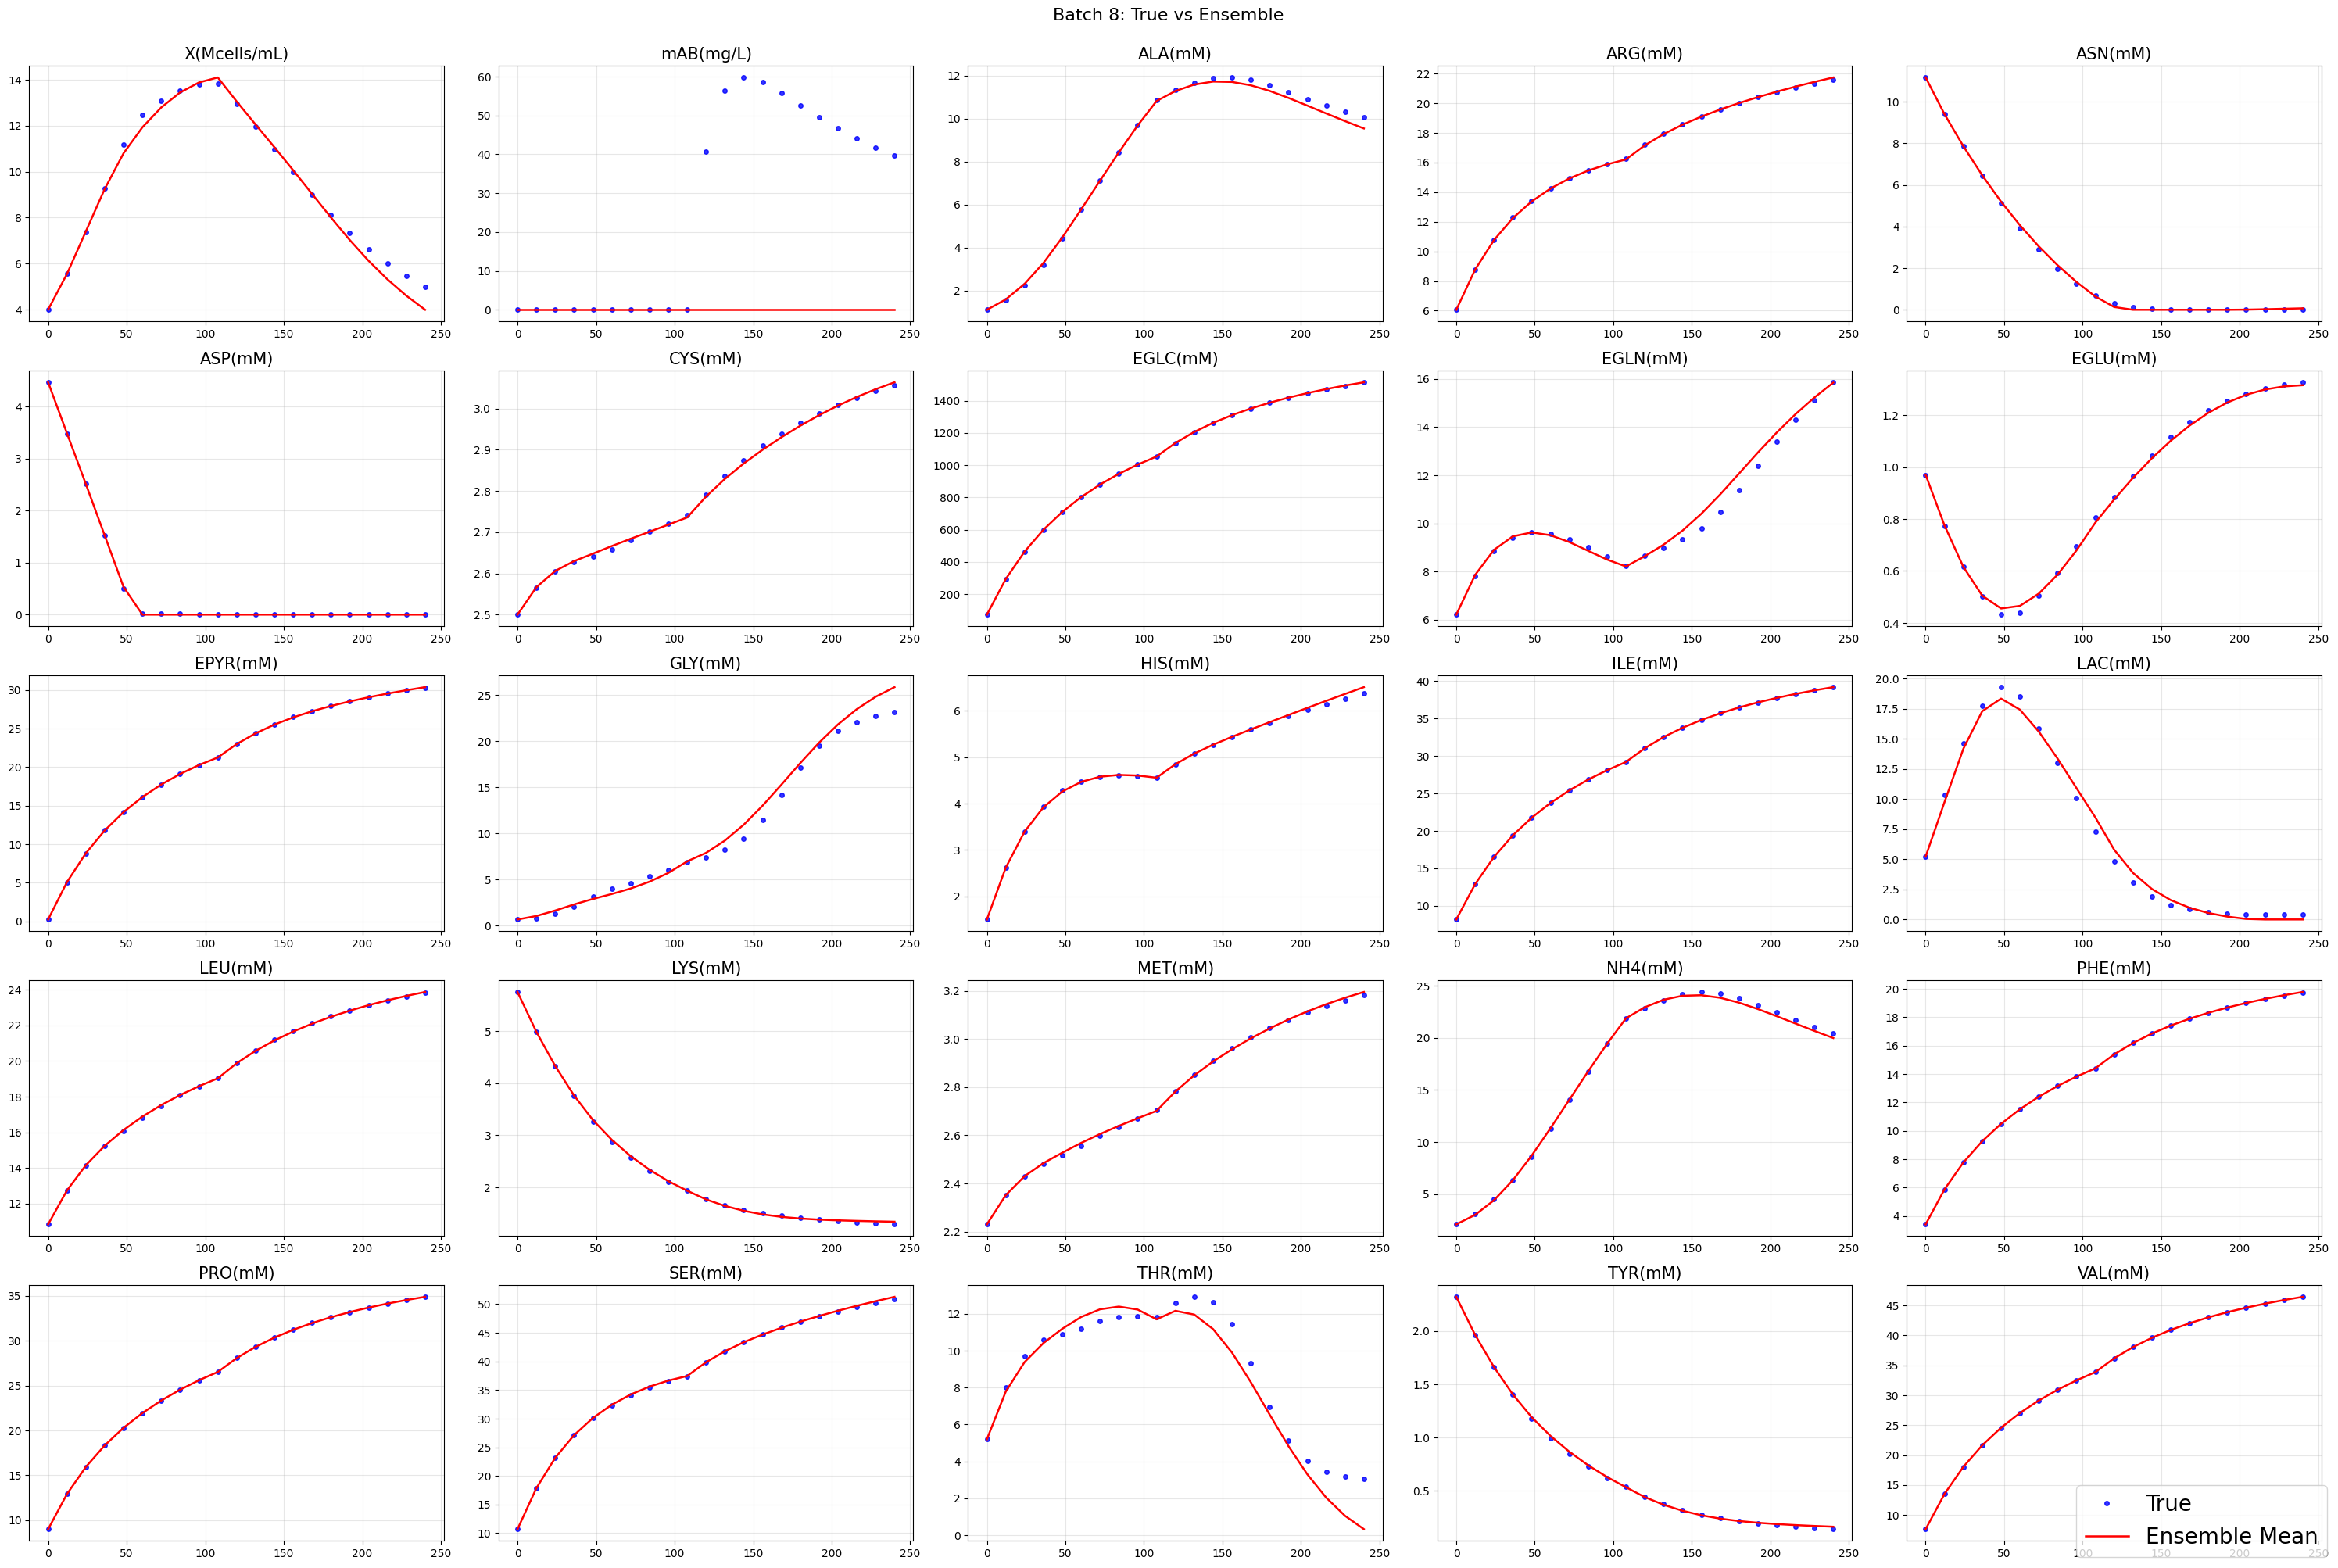

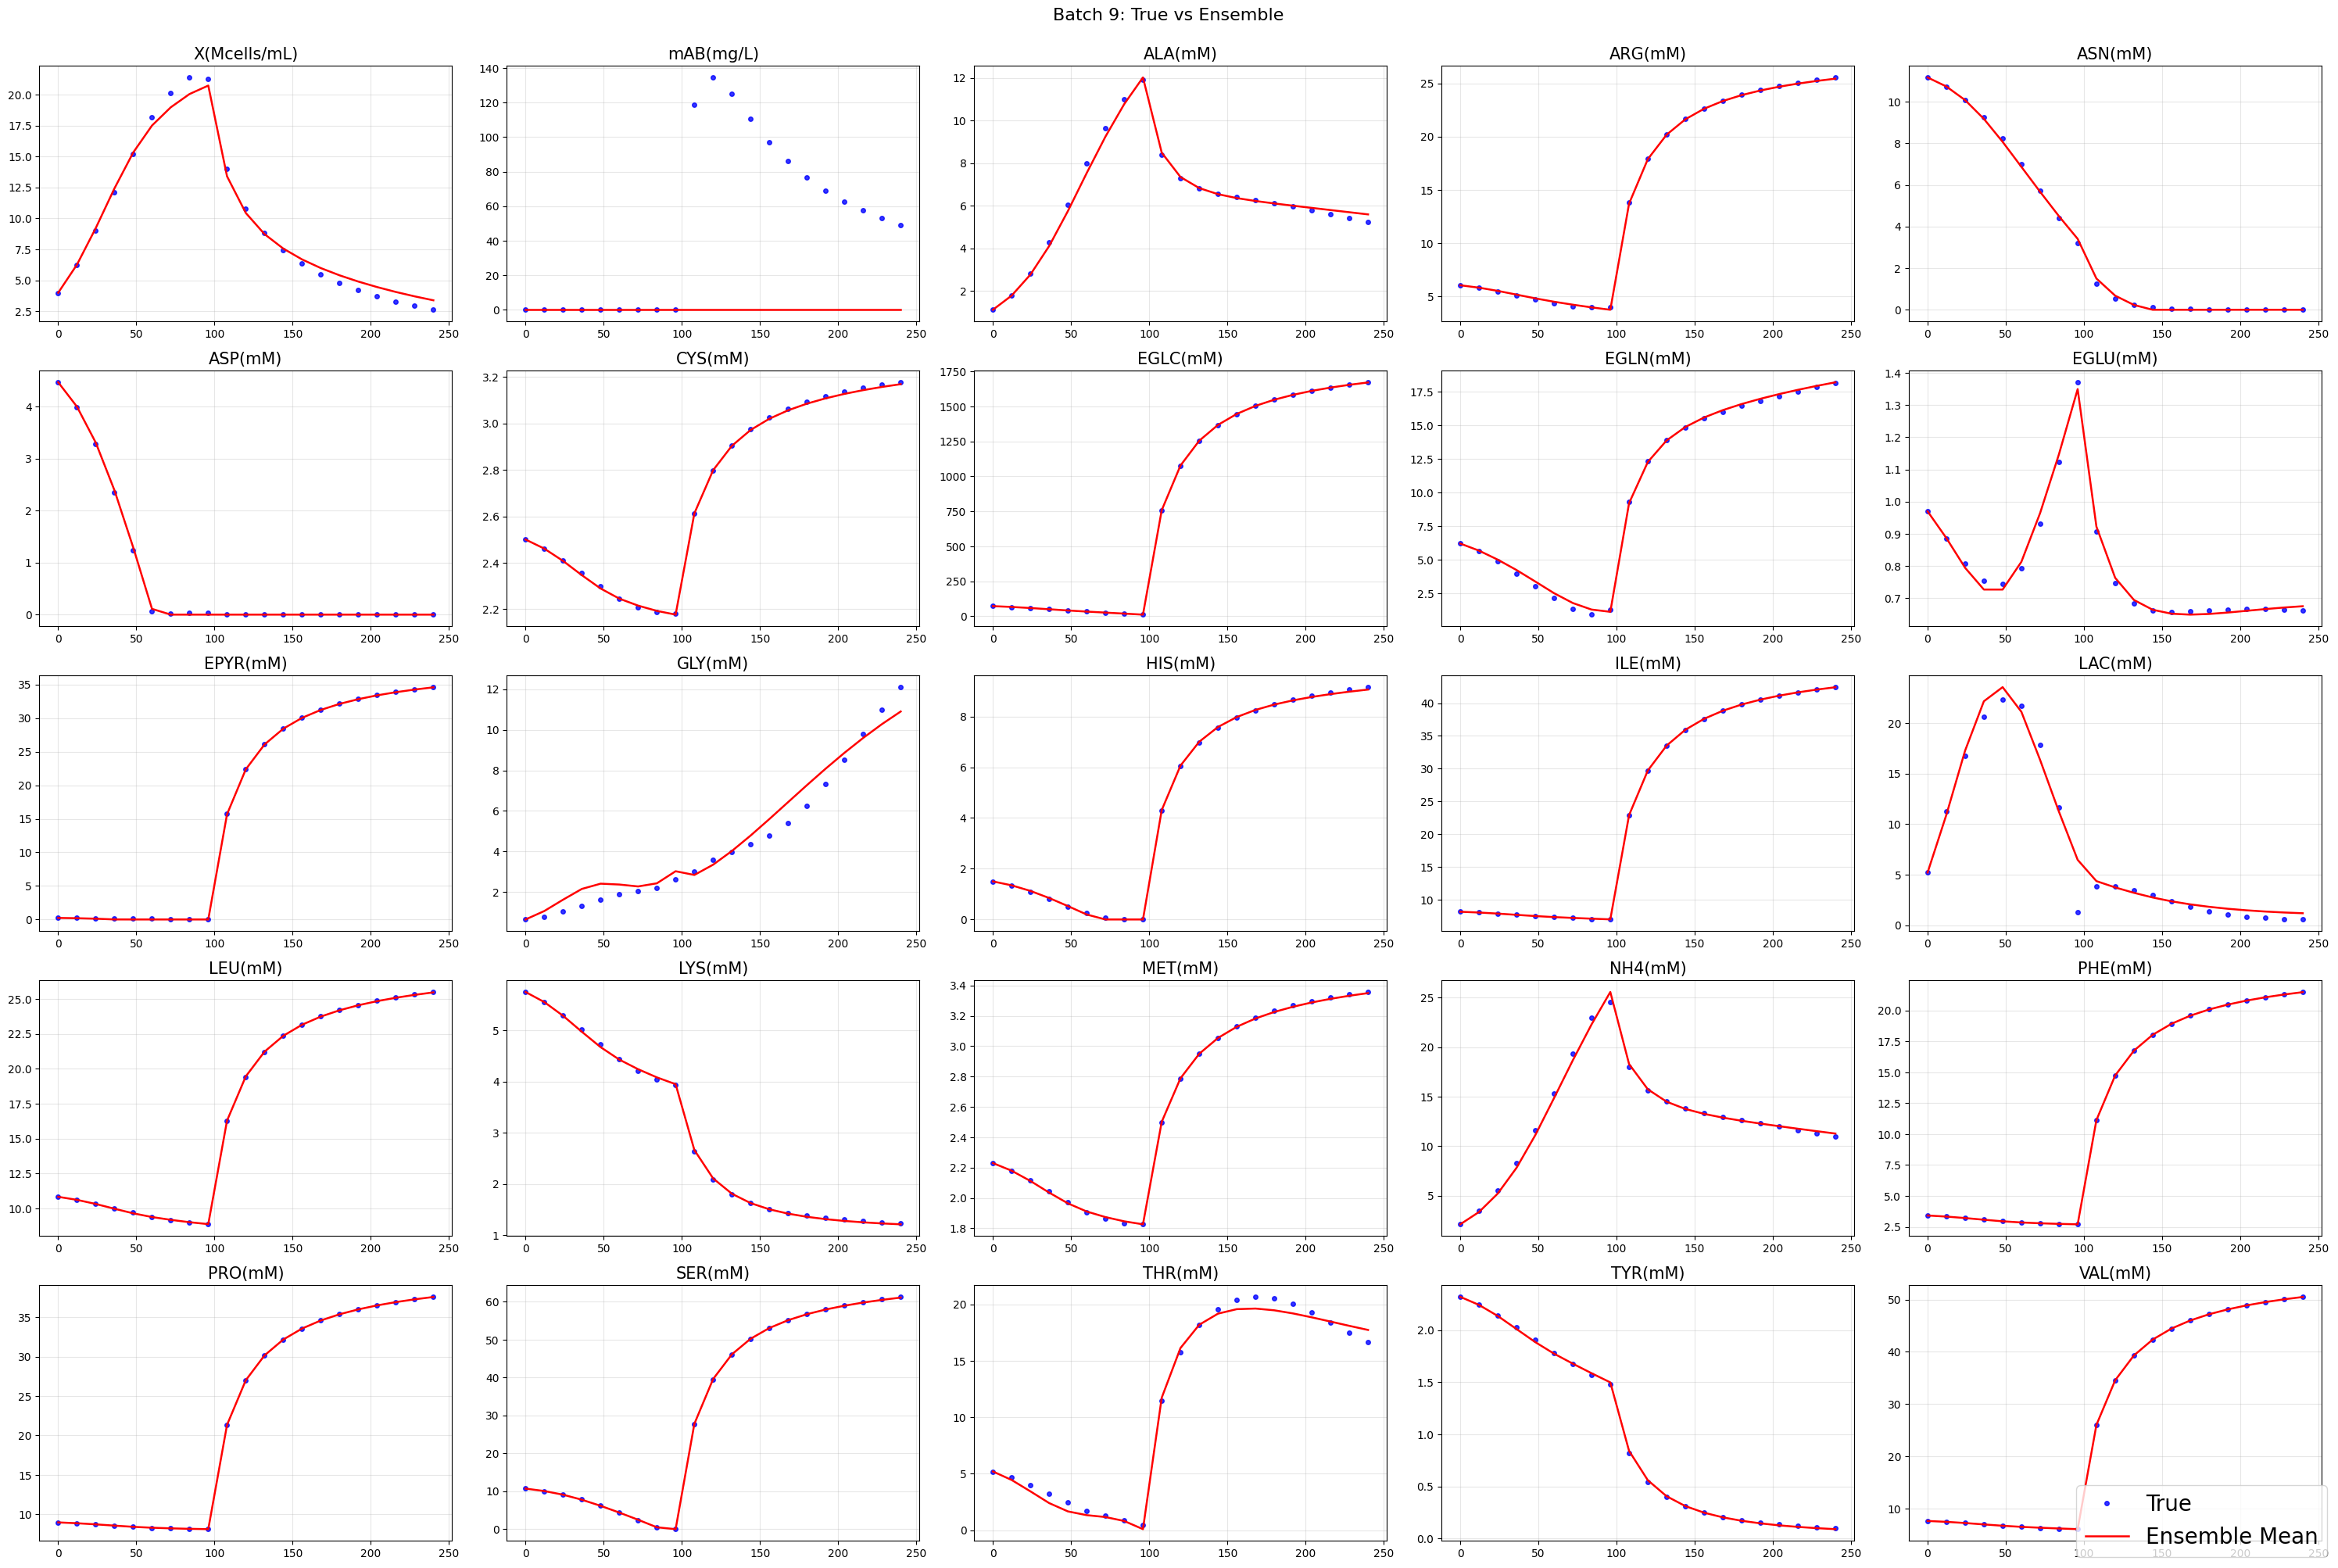

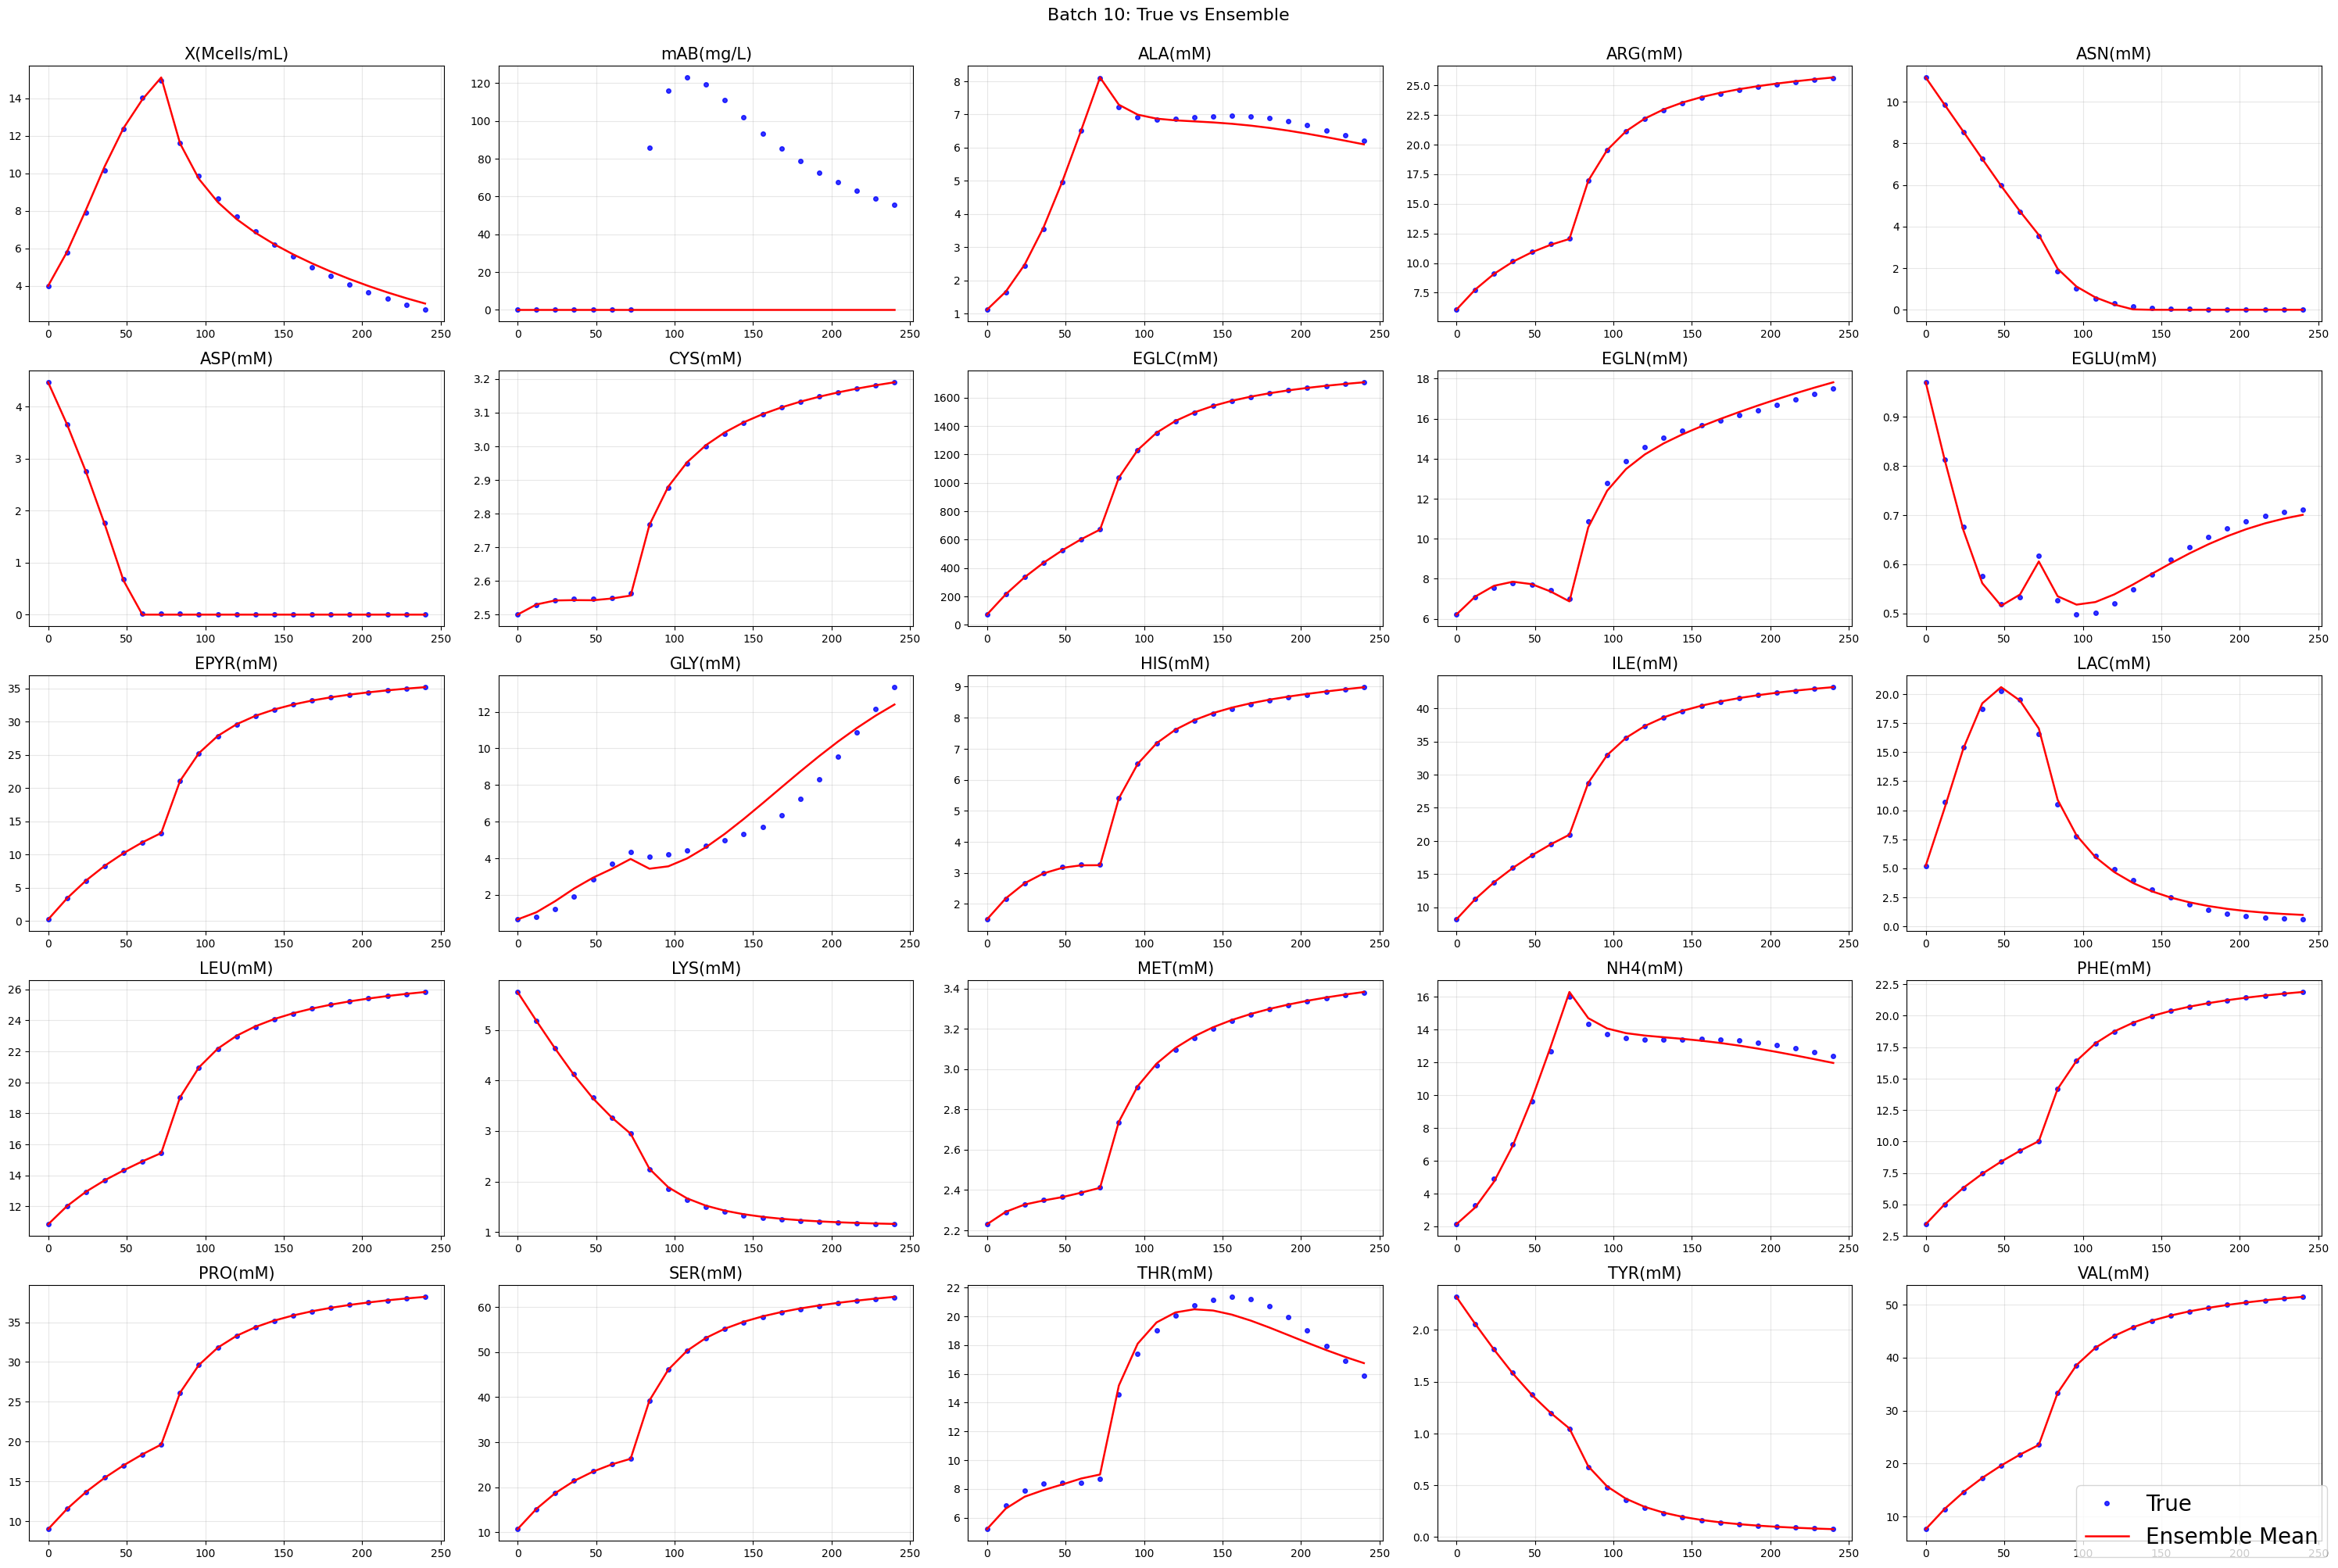

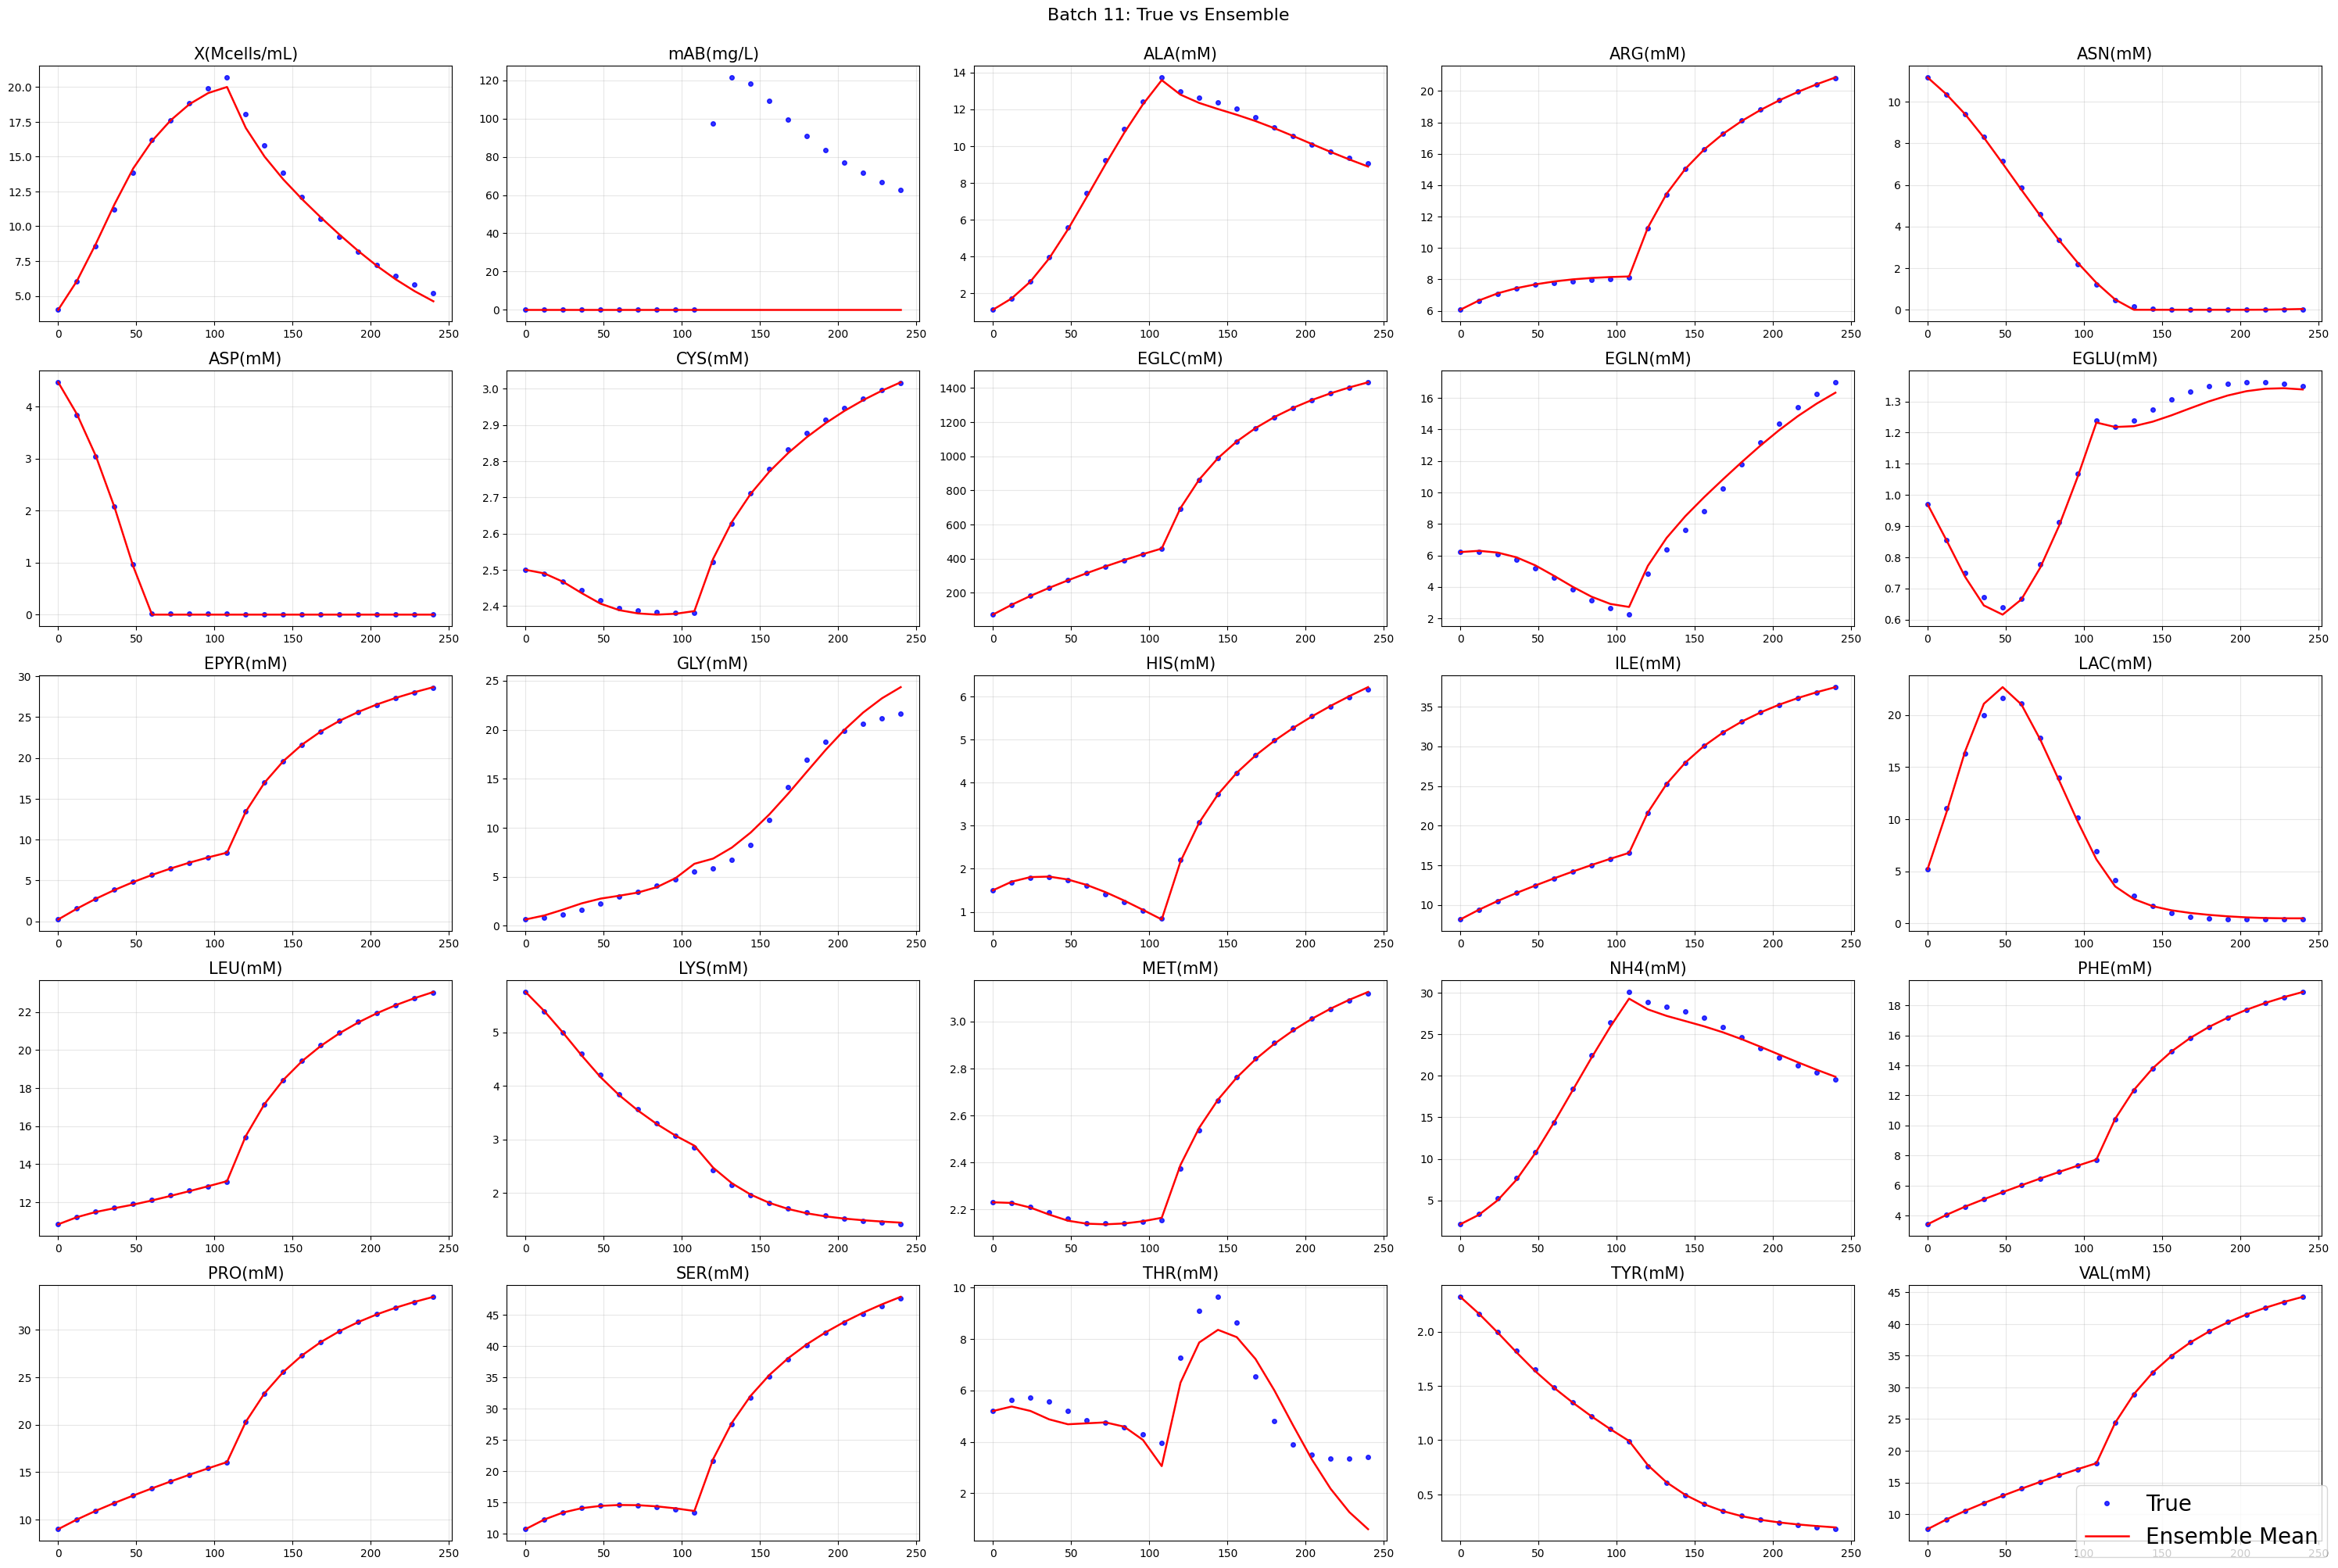

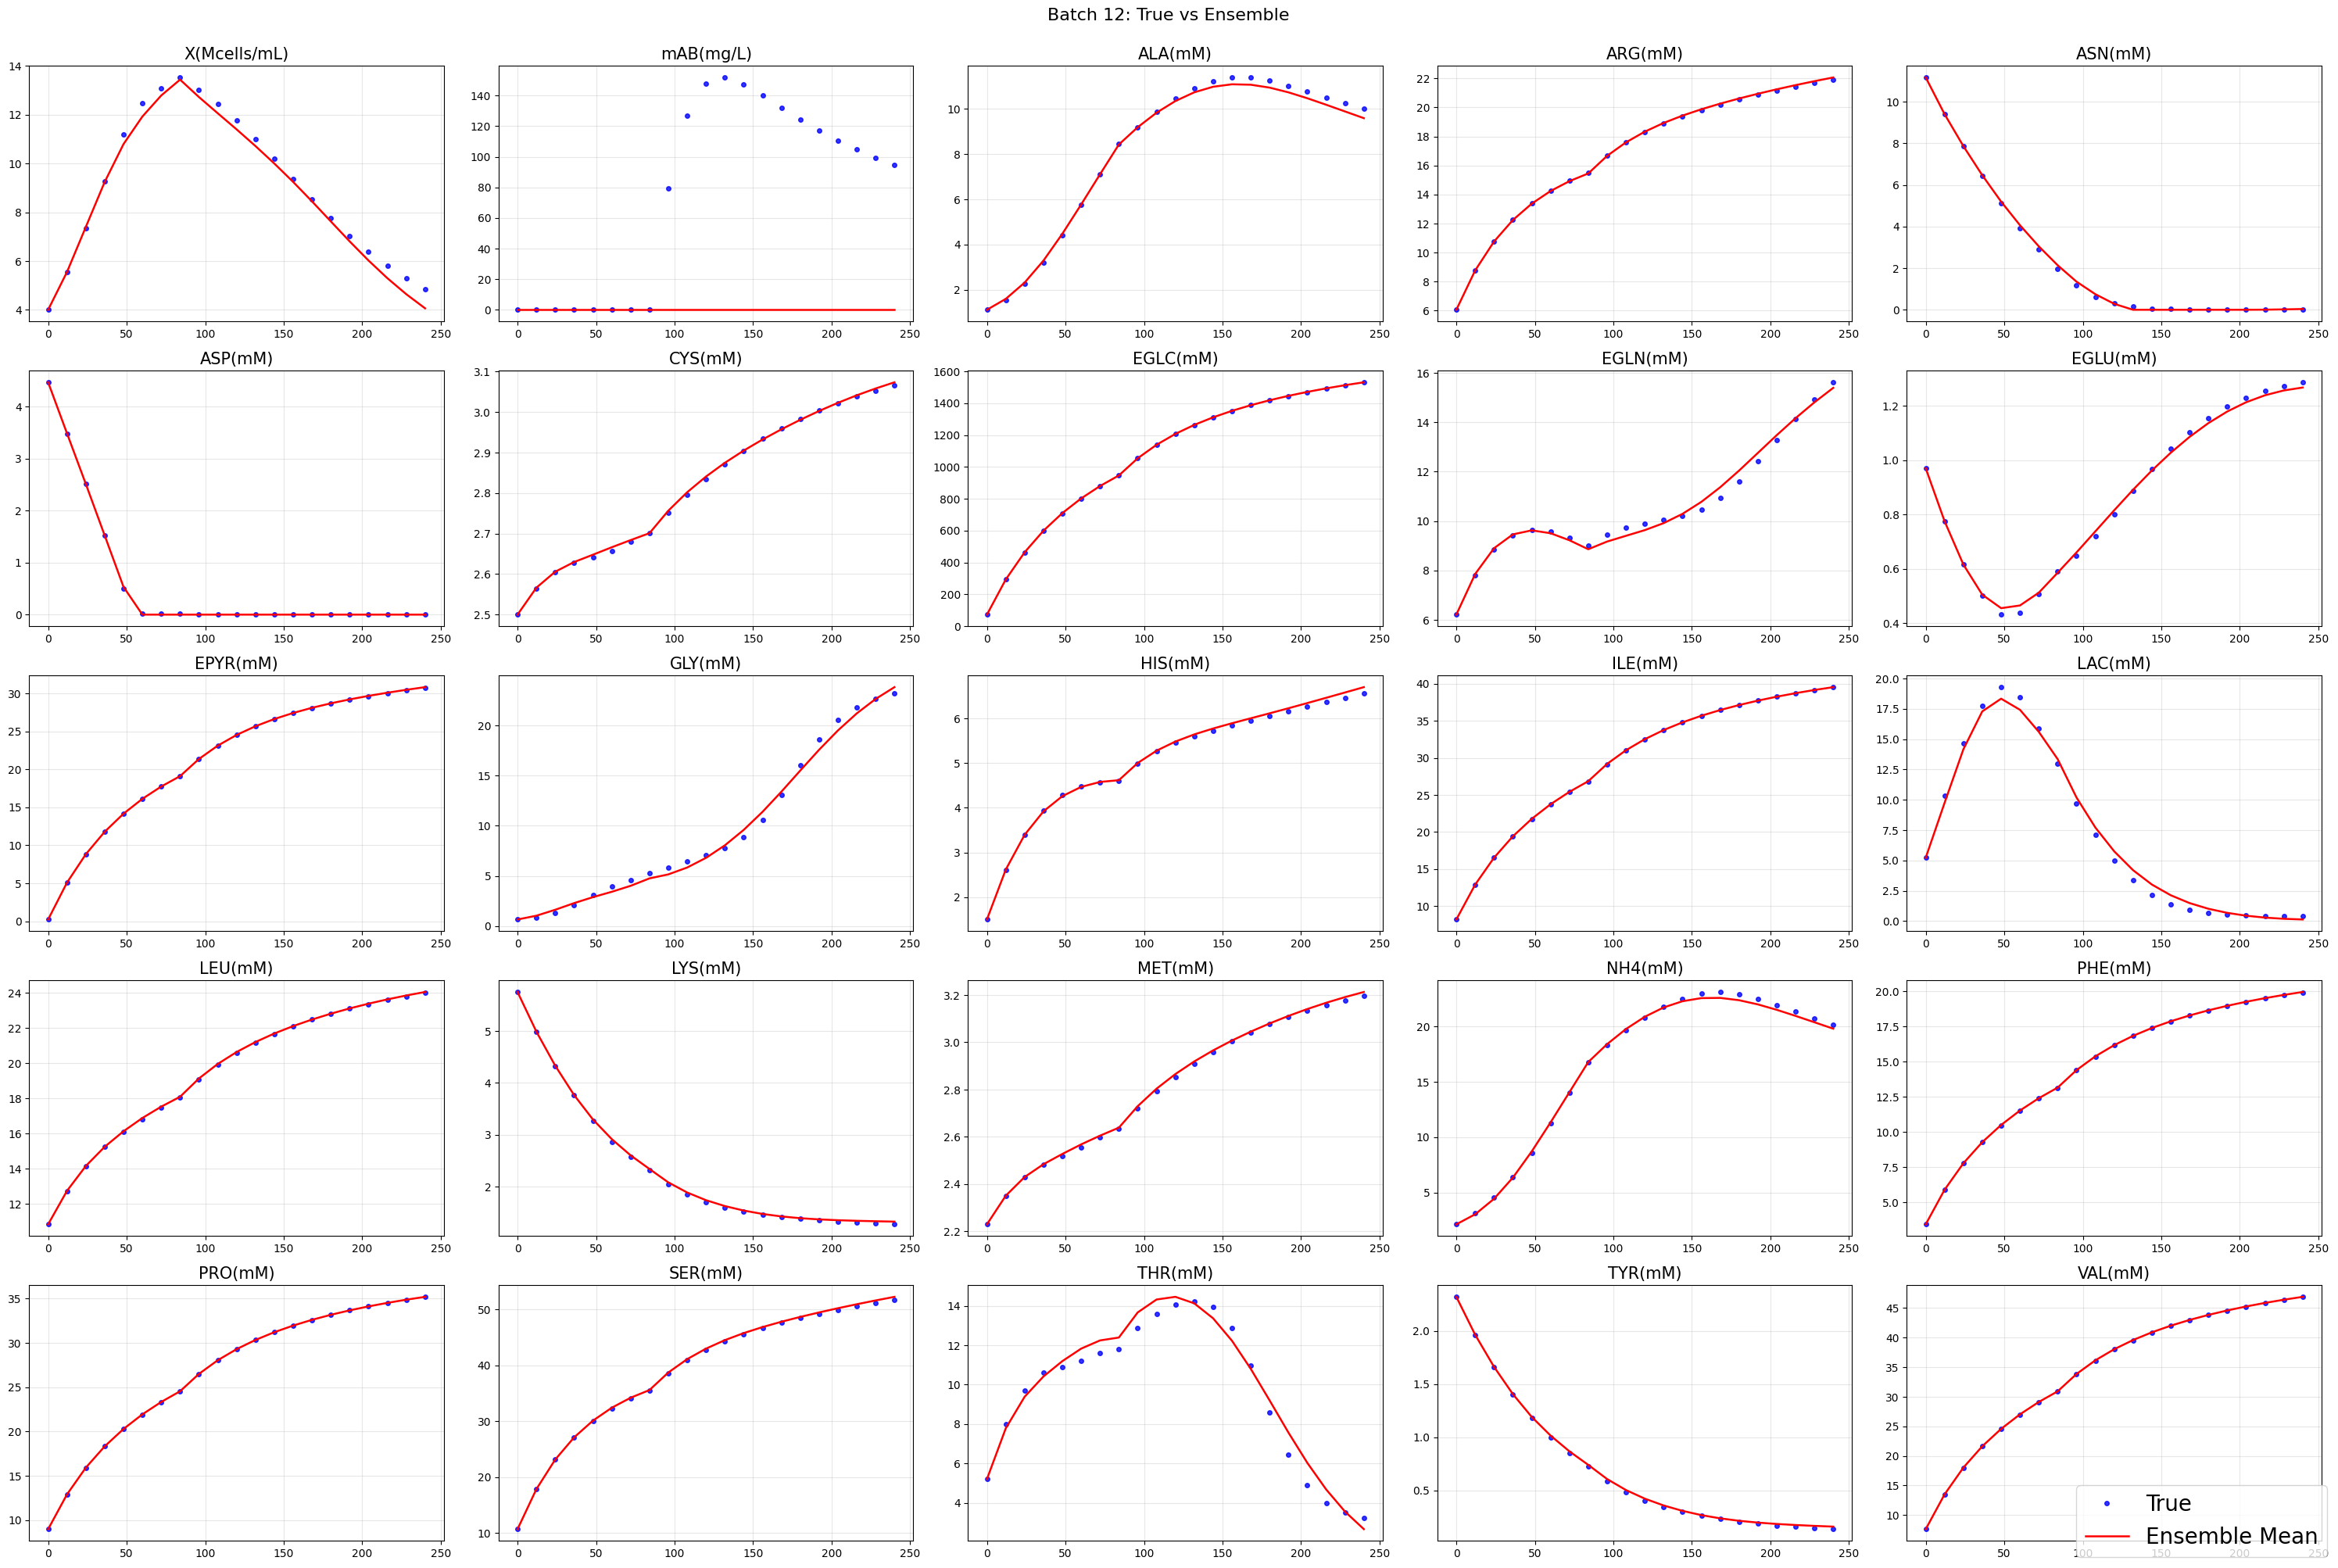

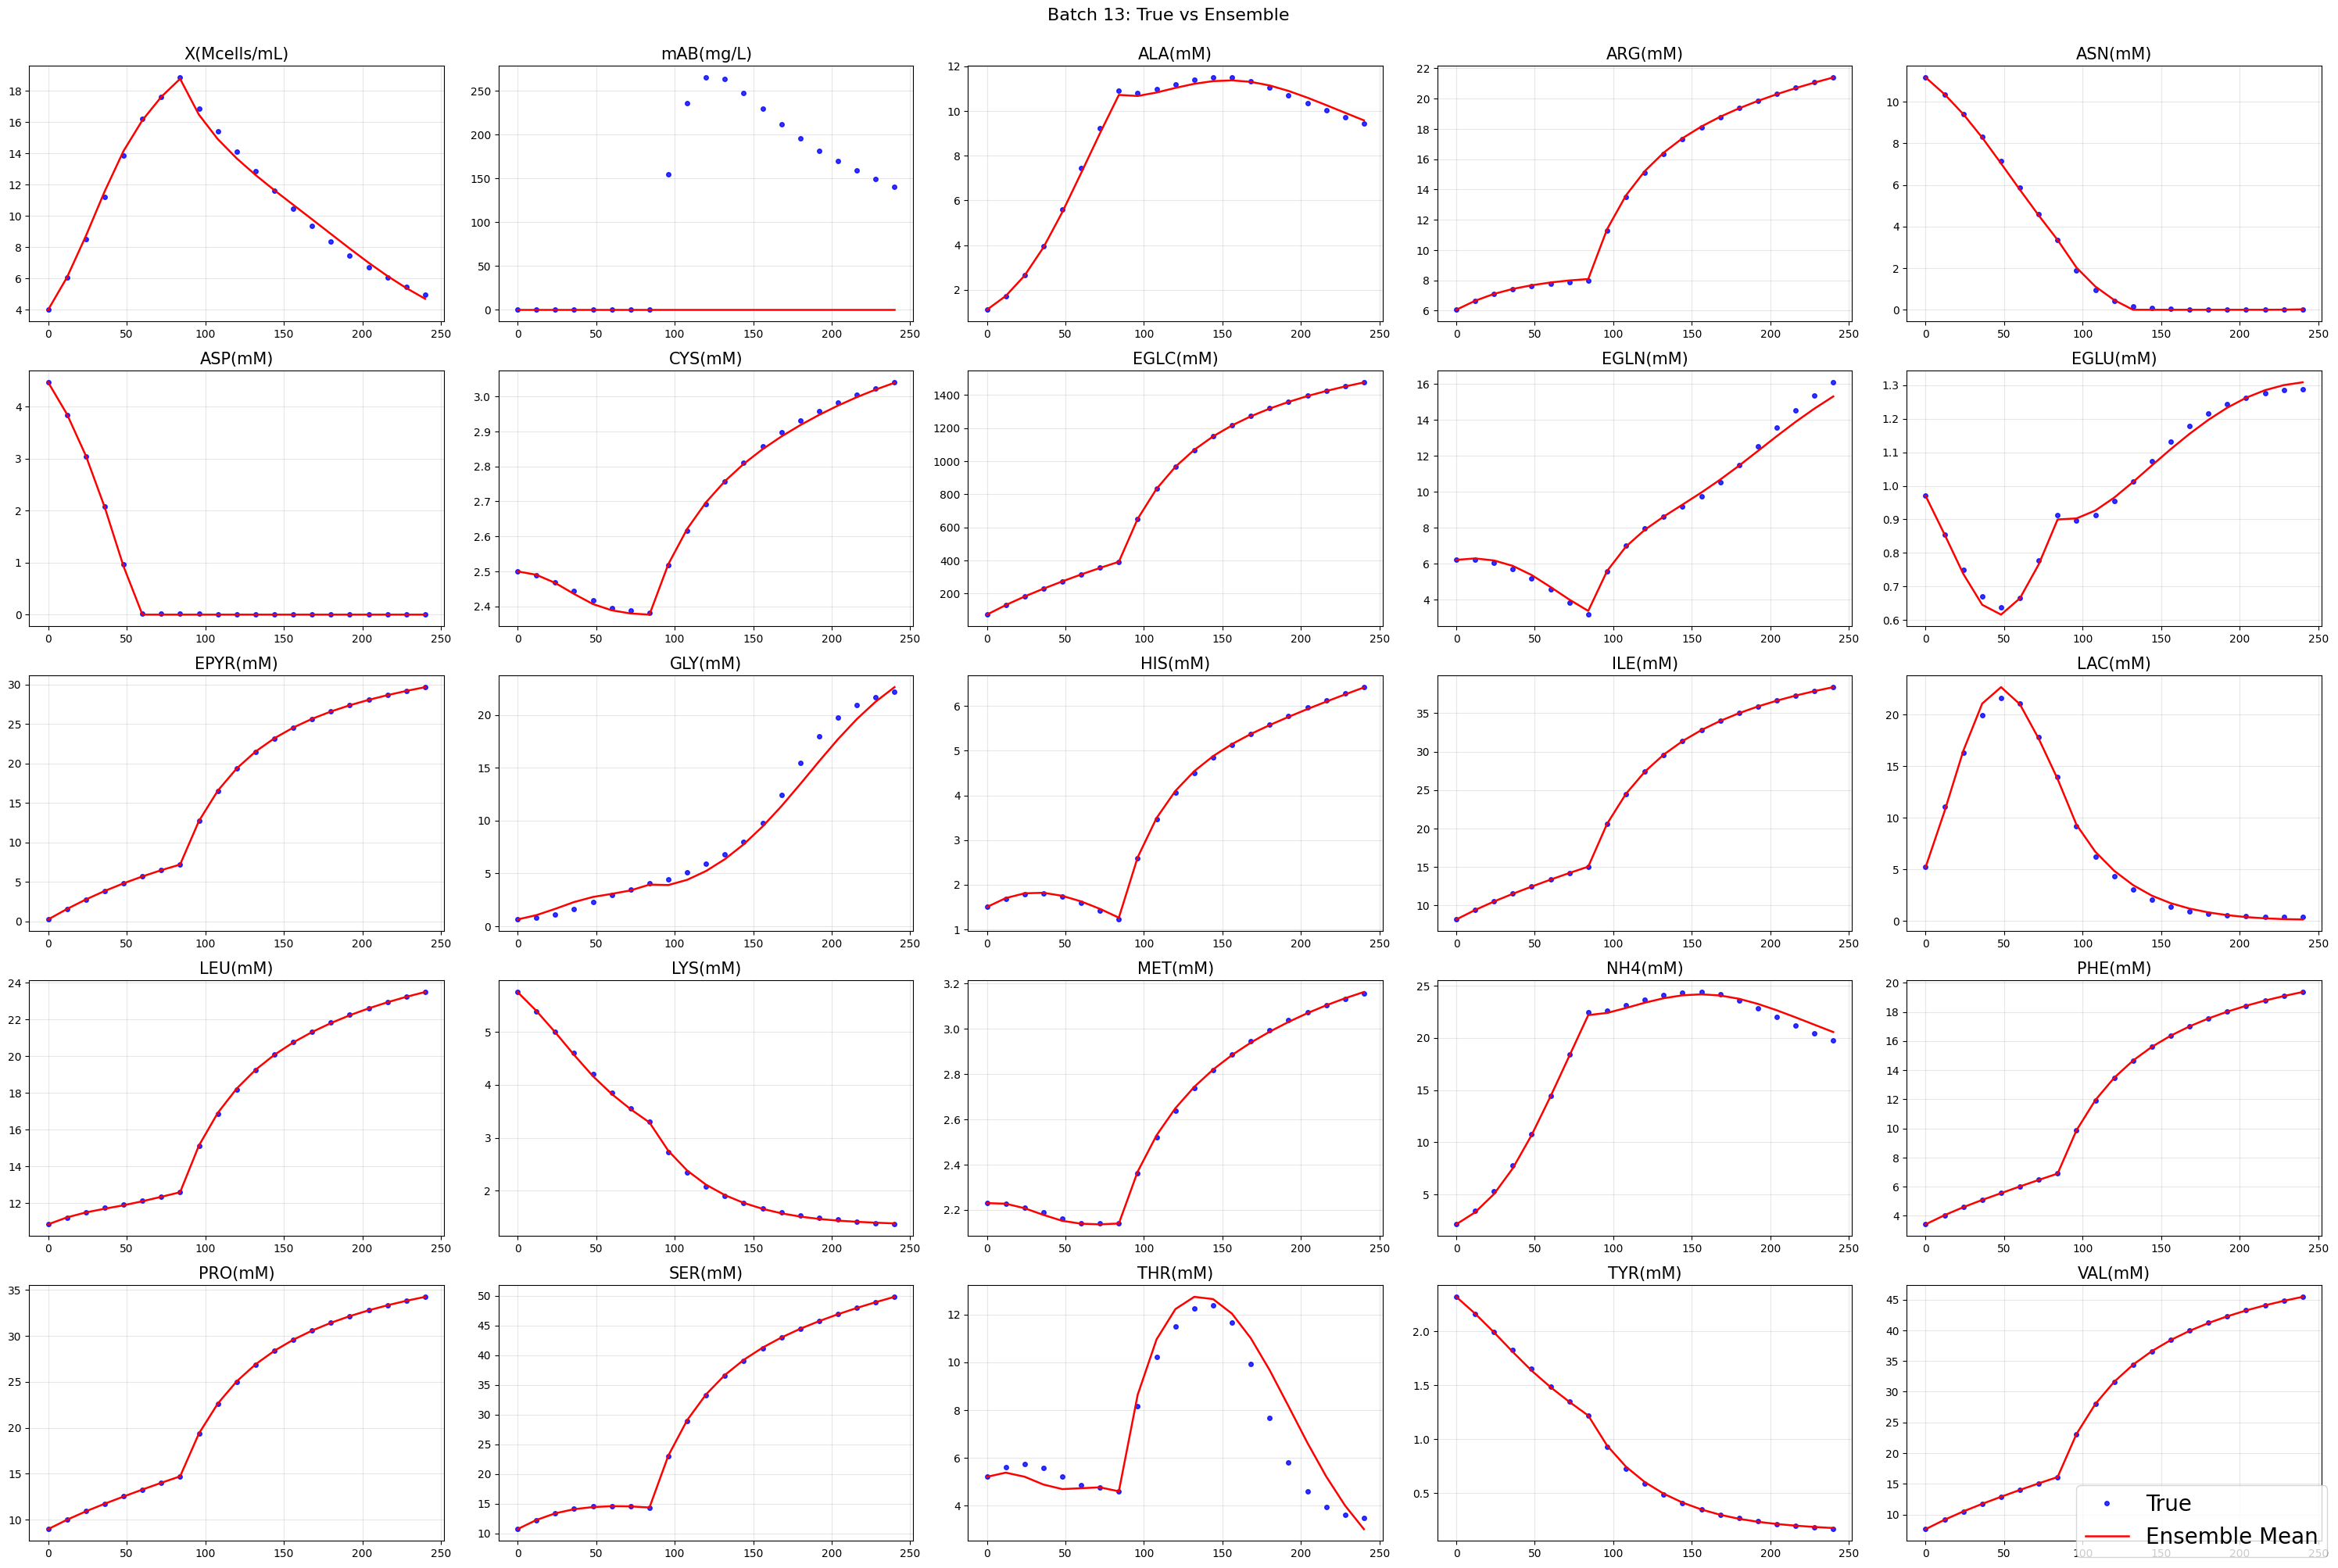

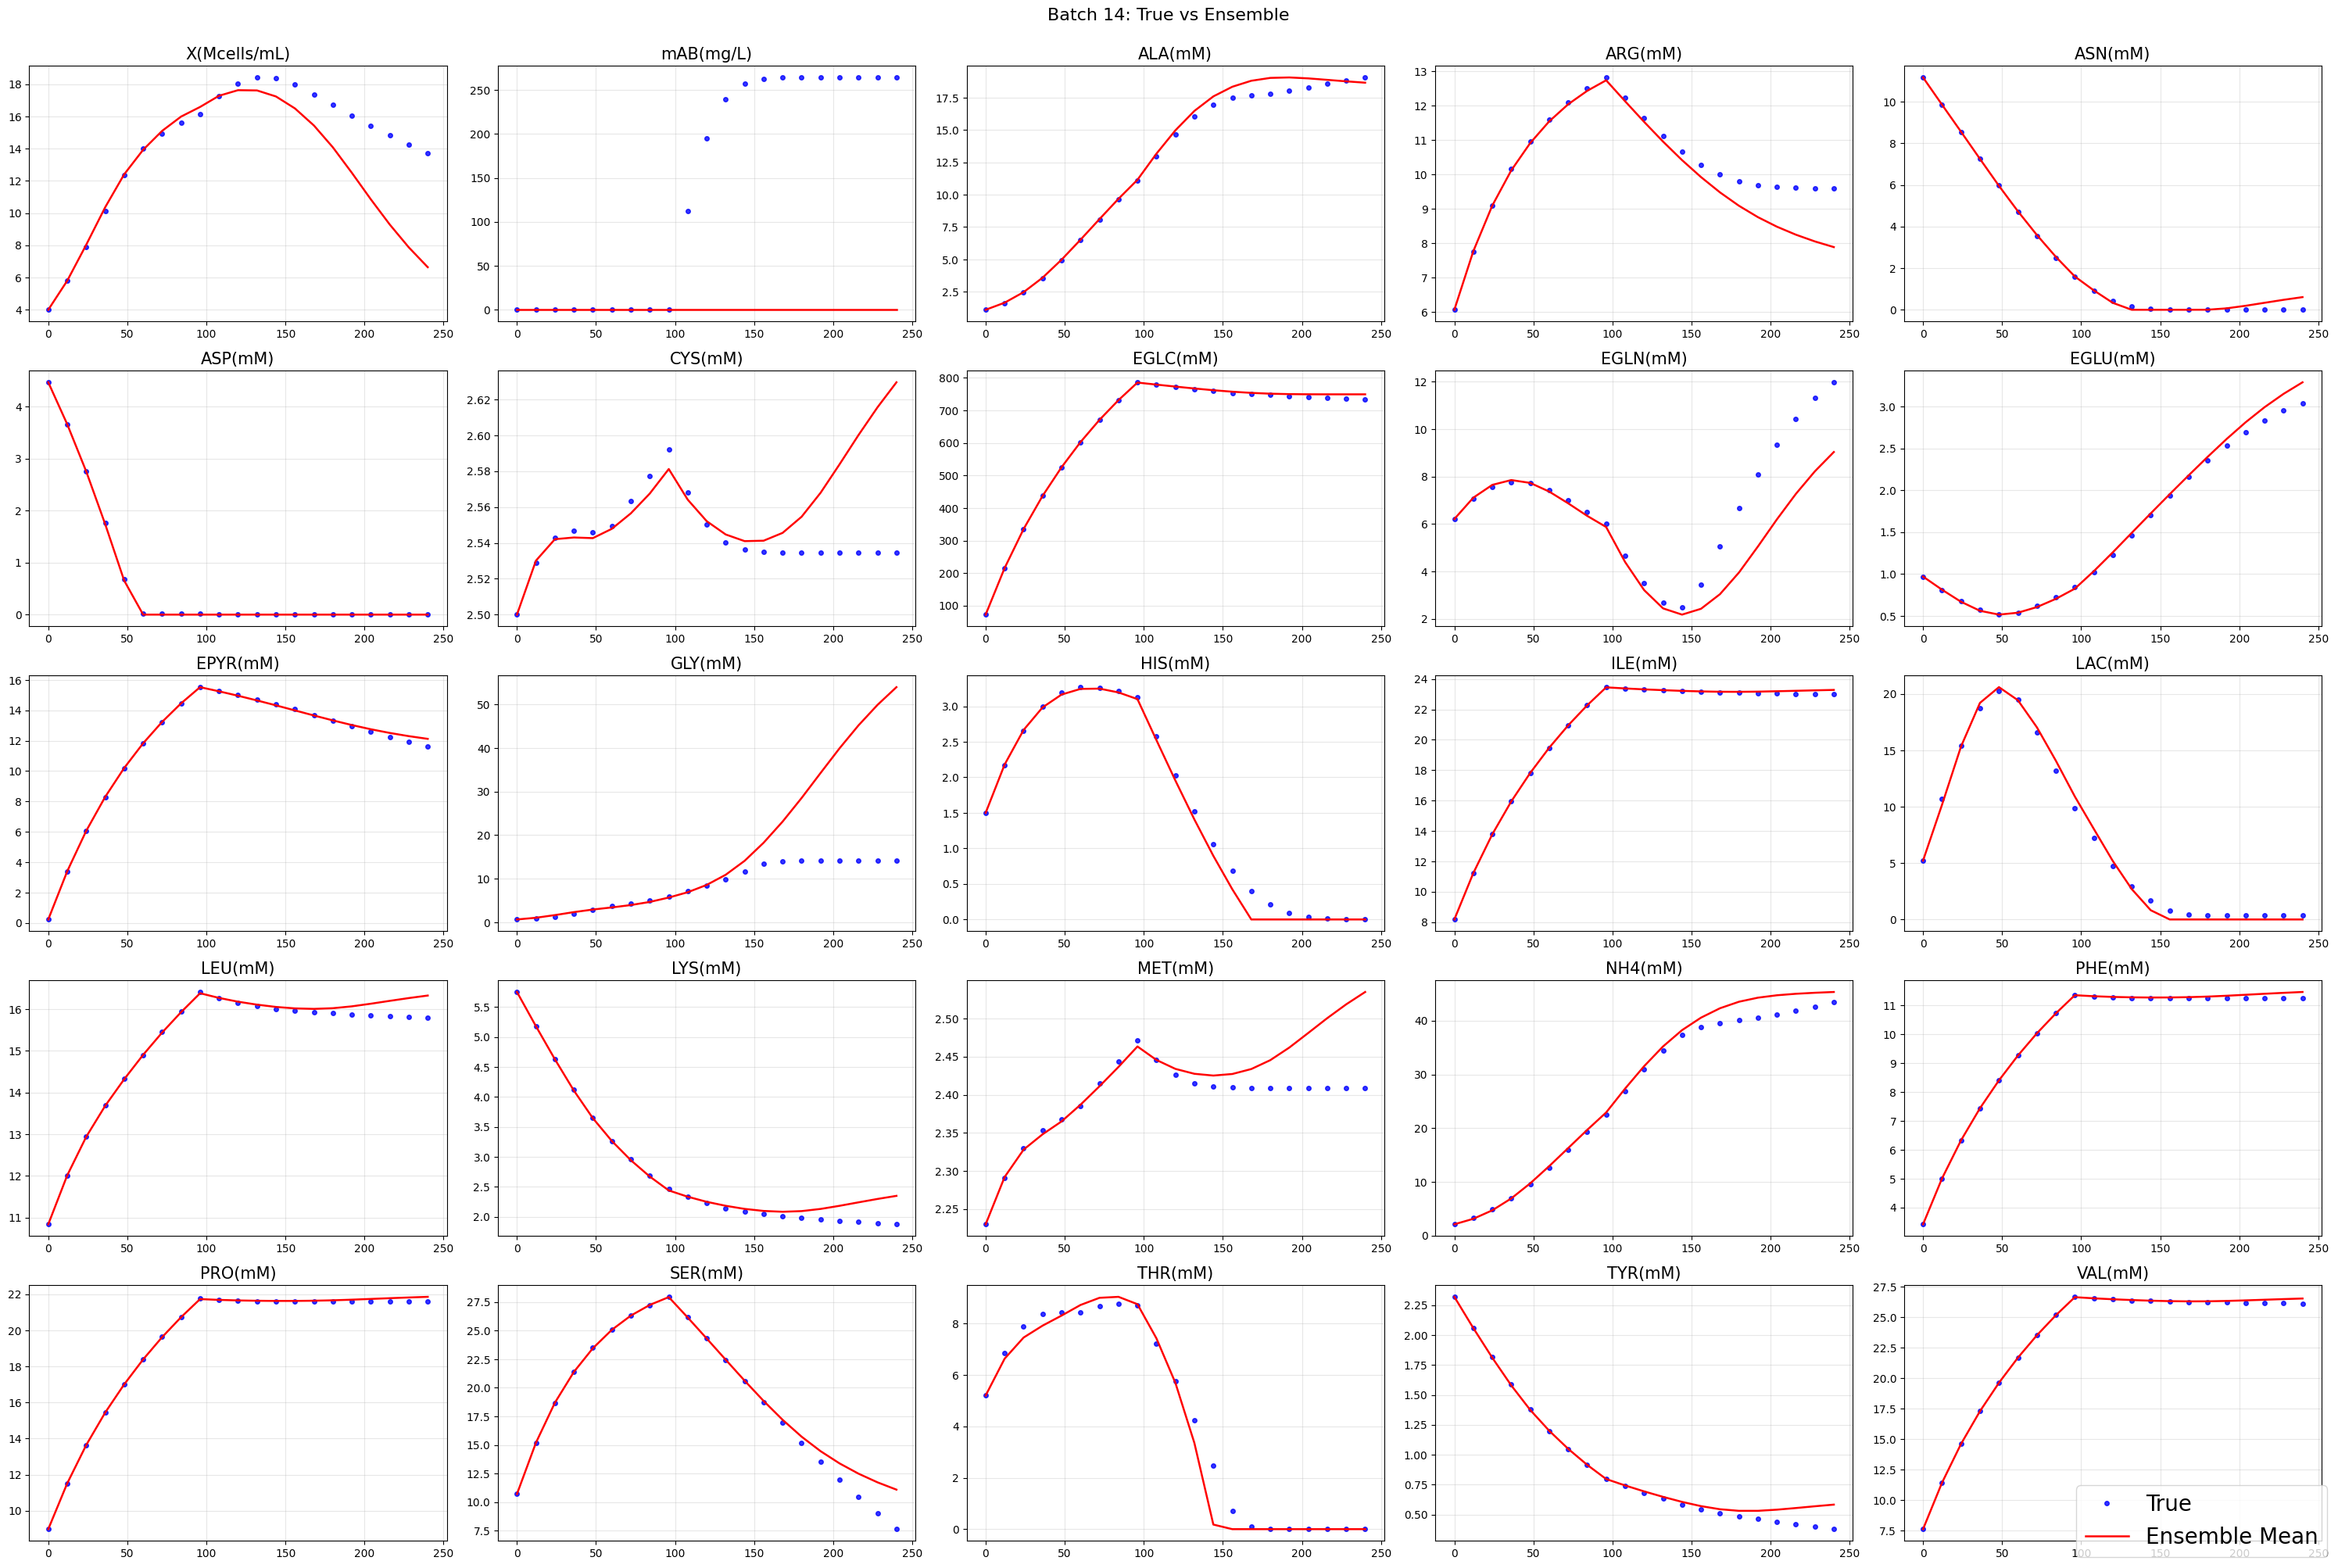

In [382]:
########################## Cell 20: Ensemble Predictions + CI + Plot #############################

all_batches = batch_numbers
n_models = len(model_paths)
pred_models_list = []

for model_path in model_paths:

    checkpoint = torch.load(model_path)
    net = FFNN(
        input_dim=inputs_num,
        hidden_layers=nh,
        output_dim=outputs_num,
        activation=activation
    )
    net.load_state_dict(checkpoint["model_state_dict"])
    net.eval()

    with torch.no_grad():

        state_with_v = torch.cat((target_data[all_batches, 0, :], volume_data[all_batches, 0].unsqueeze(1)), dim=1)
        preds = []

        for i in range(len(time_data) - 1):
            state_with_v = solve_ode_semi_parametric(
                ode_func=solve_ode,
                state=state_with_v,
                model=net,
                target_max=target_max,
                output_max=output_max,
                controls=controls_sequence[all_batches, i, :],
                t=time_data[i],
                tf=time_data[i+1],
                h=h
            )

            preds.append(state_with_v[:, :-1].detach().cpu())

        preds = torch.stack(preds)  # (T-1, B, S)
        pred_models_list.append(preds)

pred_models = torch.stack(pred_models_list)  # (n_models, T-1, B, S)

init = (target_data[all_batches, 0, :]).unsqueeze(0).unsqueeze(0)
init = init.repeat(n_models, 1, 1, 1) 

pred_models = torch.cat([init, pred_models], dim=1)  

mean_pred = pred_models.mean(dim=0)   # (T-1, B, S)
std_pred  = pred_models.std(dim=0)

if n_models > 1:
    t_value = 2.776 #LGnote: Valido apenas para k=5
else:
    t_value = 0.0

std_error = std_pred / np.sqrt(n_models)

ci_minus = mean_pred - t_value * std_error
ci_plus  = mean_pred + t_value * std_error

title_suffix = f"Ensemble (n={n_models})"

for batch_idx, b in enumerate(all_batches):

    # TRUE 
    true_traj = true_data[b]
    num_species = true_traj.shape[1]

    n_cols = 5
    n_rows = int(np.ceil(num_species / n_cols))

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    axs = axs.flatten()

    for s in range(num_species):
        ax = axs[s]
        species_label = inputs_labels[s]

        ax.plot(time_data, true_traj[:, s], "o", markersize=4, alpha=0.8, color = "blue", label="True" if s == 0 else None)
        ax.plot(time_data, mean_pred[:, batch_idx, s], color = "red", linewidth=1.8, label="Ensemble Mean" if s == 0 else None)

        if n_models > 1:
            ax.fill_between(time_data[:], ci_minus[:, batch_idx, s], ci_plus[:, batch_idx, s], color = "red",
                     alpha=0.25, label="CI" if s == 0 else None)

        ax.set_title(species_label, fontsize=15)
        ax.grid(alpha=0.3)

    for k in range(num_species, 25):
        fig.delaxes(axs[k])

    fig.suptitle(f"Batch {b}: True vs Ensemble", fontsize=16, y = 1.0)
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower right", fontsize=20)
    plt.tight_layout()
    plt.show()